In [1]:
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy import stats
from lifelines import KaplanMeierFitter
from lifelines.statistics import logrank_test, multivariate_logrank_test
from IPython.display import display, HTML
warnings.filterwarnings("ignore")

In [2]:

# CONFIGURATION GLOBALE

DATA_DIR    = "pf_db_export/"         
OUTPUT_DIR  = "outputs/"      
eid   = "driver_id"      
OBS_END     = pd.Timestamp("2026-06-26")  # Date de fin d'observation (censure)

# Palette couleurs
COLORS = {
    "primary"   : "#1A3557",
    "secondary" : "#2E75B6",
    "accent"    : "#C8372D",
    "green"     : "#1E6B3C",
    "gold"      : "#B8860B",
    "light"     : "#D6E4F0",
    "gray"      : "#5A5A5A",
}

os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs(f"{OUTPUT_DIR}figures/", exist_ok=True)

plt.rcParams.update({
    "figure.facecolor" : "white",
    "axes.facecolor"   : "#F8FBFF",
    "axes.grid"        : True,
    "grid.alpha"       : 0.4,
    "axes.spines.top"  : False,
    "axes.spines.right": False,
    "font.family"      : "DejaVu Sans",
    "axes.titlesize"   : 13,
    "axes.labelsize"   : 11,
})

In [3]:

# UTILITAIRES
def load_csv(name, date_cols=None, sep=","):
    """Charge un fichier CSV ou Excel"""
    path = os.path.join(DATA_DIR, name)
    if not os.path.exists(path):
        print(f"  [MISSING] {name}: file not found, skipped.")
        return None

    if name.endswith(".xlsx") or name.endswith(".xls"):
        df = pd.read_excel(path)
        if date_cols:
            for col in date_cols:
                if col in df.columns:
                    df[col] = pd.to_datetime(
                        df[col], errors="coerce", dayfirst=True
                    )
        method = "EXCEL"
    else:
        df = pd.read_csv(
            path, sep=sep, parse_dates=date_cols, dayfirst=True, low_memory=False
        )
        method = "CSV"

    df.columns = [c.strip().lower().replace(" ", "_") for c in df.columns]
    print(
        f"  [OK] {name} ({method}) — {df.shape[0]:,} rows and {df.shape[1]} columns"
    )
    return df

def save_fig(name, dpi=150):
    """Sauvegarde la figure courante."""
    plt.tight_layout()
    plt.savefig(f"{OUTPUT_DIR}figures/{name}.png", dpi=dpi, bbox_inches="tight")
    plt.close()
    print(f"  [FIGURE] {name}.png saved")

def section(title, char="═"):
    line = char * 70
    print(f"\n{line}\n  {title}\n{line}")

def subsection(title):
    print(f"\n  {title}")


# BLOCK A — TABLE INTEGRATION


def bloc_a_integration():
    section("TABLE INTEGRATION")

    # ── A.1 Loading the tables ────────────────────────────────────────────
    subsection("Chargement des tables")

    tables = {}

    tables["termination"]    = load_csv("terms.csv",
                                        date_cols=["date_stamp", "effect_date", "ahd_calc"])
    
    tables["staffing"]       = load_csv("staffing_file.csv",
                                        date_cols=["adjusted_hire_date", "expected_grad_date", "fiscal_date", "job_code_assignment_date", "date_added"])
    
    tables["dc_sites"]       = load_csv("dc_site_master.csv")

    tables["paf_terms_details"] = load_csv("paf_terms_details.xlsx",
                                        date_cols=["entered_date", "term_date", "hire_date", "adjusted_hire_date"])
    
    #tables["terms_combines"] = load_csv("terms_details.xlsx",
                                        #date_cols=["entered_date", "term_date", "hire_date", "adjusted_hire_date"])

    tables["pay_weekly"]     = load_csv("wages.csv",
                                        date_cols=["date_hired", "check_date"])
    
    tables["watch_list"]     = load_csv("watchlist_score_history.csv")
    
    tables["discipline"]     = load_csv("discipline_record.csv",
                                        date_cols=["date_entered_in_lawson", "action_date", "term_date", "adjusted_hire_date"])
    
    tables["accidents"]      = load_csv("accident_registry.csv",
                                        date_cols=["date_of_accident"])
    
    tables["roadside"]       = load_csv("roadside_inspections_report.csv",
                                        date_cols=["date_of_inspection"])
    
    tables["toc_feedback"]   = load_csv("toc_feedback.csv")

    # Event tables
    tables["satisfaction"]   = load_csv("raw_load_quality_survey.csv",
                                        date_cols=["submitted_at"])
    
    tables["voe"]            = load_csv("voe_request_complete.csv",
                                        date_cols=["closed_date", "created_date"])
    
    tables["survey_conversation"] = load_csv("completed_conversation_log.csv",
                                        date_cols=["created_date"])
    
    tables["turnover_exp"]   = load_csv("turnover_by_years_of_experience.csv",
                                        date_cols=["adjusted_hire_date", "termination_date"])

    tables["conpensation_plan"]   = load_csv("compensation_plan_by_dc.csv")

    # Remove tables that were not found
    tables = {k: v for k, v in tables.items() if v is not None}
    
    return tables

tables = bloc_a_integration()


══════════════════════════════════════════════════════════════════════
  TABLE INTEGRATION
══════════════════════════════════════════════════════════════════════

  Chargement des tables
  [OK] terms.csv (CSV) — 6,527 rows and 12 columns
  [OK] staffing_file.csv (CSV) — 459,381 rows and 20 columns
  [OK] dc_site_master.csv (CSV) — 36 rows and 25 columns
  [OK] paf_terms_details.xlsx (EXCEL) — 2,044 rows and 17 columns
  [OK] wages.csv (CSV) — 1,061,600 rows and 17 columns
  [OK] watchlist_score_history.csv (CSV) — 502,510 rows and 7 columns
  [OK] discipline_record.csv (CSV) — 3,200 rows and 19 columns
  [OK] accident_registry.csv (CSV) — 9,873 rows and 41 columns
  [OK] roadside_inspections_report.csv (CSV) — 5,725 rows and 24 columns
  [OK] toc_feedback.csv (CSV) — 735 rows and 10 columns
  [OK] raw_load_quality_survey.csv (CSV) — 555,449 rows and 42 columns
  [OK] voe_request_complete.csv (CSV) — 721 rows and 13 columns
  [OK] completed_conversation_log.csv (CSV) — 3,062 rows and 3

### Check for exact duplicates

Duplicate check. The exact duplicate check reveals that only the pay_weekly and watch_list tables contained 712 and 1,979 duplicates respectively, which were removed. The other tables showed no exact duplicates, confirming their structural consistency.

In [4]:
# STEP 1 — REMOVING EXACT DUPLICATES

print("\n" + "=" * 60)
print("REMOVING EXACT DUPLICATES")
print("=" * 60)

for nom_table, df in tables.items():
    nb_avant = len(df)
    
    tables[nom_table] = df.drop_duplicates()
    
    nb_apres = len(tables[nom_table])
    nb_sup = nb_avant - nb_apres
    
    print(f"\n{nom_table} :")
    print(f"  Before    : {nb_avant:,} rows")
    print(f"  After     : {nb_apres:,} rows")
    print(f"  Removed   : {nb_sup:,} exact duplicates")


REMOVING EXACT DUPLICATES

termination :
  Before    : 6,527 rows
  After     : 6,527 rows
  Removed   : 0 exact duplicates

staffing :
  Before    : 459,381 rows
  After     : 459,381 rows
  Removed   : 0 exact duplicates

dc_sites :
  Before    : 36 rows
  After     : 36 rows
  Removed   : 0 exact duplicates

paf_terms_details :
  Before    : 2,044 rows
  After     : 2,044 rows
  Removed   : 0 exact duplicates

pay_weekly :
  Before    : 1,061,600 rows
  After     : 1,060,888 rows
  Removed   : 712 exact duplicates

watch_list :
  Before    : 502,510 rows
  After     : 500,531 rows
  Removed   : 1,979 exact duplicates

discipline :
  Before    : 3,200 rows
  After     : 3,200 rows
  Removed   : 0 exact duplicates

accidents :
  Before    : 9,873 rows
  After     : 9,873 rows
  Removed   : 0 exact duplicates

roadside :
  Before    : 5,725 rows
  After     : 5,725 rows
  Removed   : 0 exact duplicates

toc_feedback :
  Before    : 735 rows
  After     : 735 rows
  Removed   : 0 exact

In [5]:
import pandas as pd
from IPython.display import display

# 1. List of columns to check on input
colonnes_a_verifier = ['eid', 'departement', 'employee', 'driver_id', 'reason_code_1_description', 'voluntary', 'date_stamp', 'ahd_calc', 'adjusted_hire_date', 'job_title', 'description']

for nom_table, df in tables.items():
  
    nb_avant = len(df)
    tables[nom_table] = df.drop_duplicates()
    df_nettoye = tables[nom_table]
    nb_lignes_table = len(df_nettoye)
    nb_sup = nb_avant - nb_lignes_table
    
    colonnes_trouvees = [col for col in colonnes_a_verifier if col in df_nettoye.columns]
    
    print(f"# TABLE: {nom_table.upper()} | {nb_lignes_table:,} rows (Duplicates removed: {nb_sup:,})")
    
    if not colonnes_trouvees:
        print("No column from the target list found in this table.\n")
        continue
        
    lignes_rapport = []

    for col in colonnes_trouvees:
        nb_na = df_nettoye[col].isna().sum()
        nb_valeurs_presentes = nb_lignes_table - nb_na
        taux_completude = (nb_valeurs_presentes / nb_lignes_table) * 100 if nb_lignes_table > 0 else 0
        completude_str = f"{taux_completude:.1f}%"
        
        # Case 1: Identifier
        if 'employee' in col.lower() or 'eid' in col.lower():
            lignes_rapport.append({
                "Column": col, "Type": "ID", "Nb NA": nb_na, "Completeness": completude_str,
                "Category / Range": "Unique values", "Count": df_nettoye[col].nunique(), "Share (%)": 100.0
            })
            
        elif 'date' in col.lower() or pd.api.types.is_datetime64_any_dtype(df_nettoye[col]):
            try:
                col_date = pd.to_datetime(df_nettoye[col], errors='coerce')
                min_str = str(col_date.min().date()) if pd.notna(col_date.min()) else "NaT"
                max_str = str(col_date.max().date()) if pd.notna(col_date.max()) else "NaT"
            except Exception:
                min_str, max_str = "Err", "Err"
                
            lignes_rapport.append({
                "Column": col, "Type": "Date", "Nb NA": nb_na, "Completeness": completude_str,
                "Category / Range": f"Minimum: {min_str}", "Count": None, "Share (%)": None
            })
            lignes_rapport.append({
                "Column": col, "Type": "Date", "Nb NA": nb_na, "Completeness": completude_str,
                "Category / Range": f"Maximum: {max_str}", "Count": None, "Share (%)": None
            })
                
        else:
            distrib = df_nettoye[col].value_counts(dropna=False).head(4)
            for val, count in distrib.items():
                pct = (count / nb_lignes_table) * 100
                nom_modalite = "VIDE (NaN)" if pd.isna(val) else str(val)
                
                lignes_rapport.append({
                    "Column": col, "Type": "Categorical", "Nb NA": nb_na, "Completeness": completude_str,
                    "Category / Range": nom_modalite, "Count": count, "Share (%)": pct
                })
                
    df_table_rapport = pd.DataFrame(lignes_rapport)
    
    
    df_visuel = df_table_rapport.copy()
    
    df_visuel["Column"] = df_visuel["Column"].mask(df_visuel["Column"].duplicated(), "")
    df_visuel["Type"] = df_visuel["Type"].mask(df_visuel["Type"].duplicated(), "")
    
    mask_doublons = df_table_rapport["Column"].duplicated()
    df_visuel["Nb NA"] = df_visuel["Nb NA"].mask(mask_doublons, "")
    df_visuel["Completeness"] = df_visuel["Completeness"].mask(mask_doublons, "")

    rendu_final = (df_visuel.style
        .format({"Count": lambda x: f"{x:,.0f}" if pd.notnull(x) else "-", 
                 "Share (%)": lambda x: f"{x:.1f}%" if pd.notnull(x) else "-"})
        .set_properties(**{
            'text-align': 'left',
            'font-family': 'Segoe UI, sans-serif',
            'padding': '10px 14px',
            'vertical-align': 'middle'
        })
        .set_table_styles([
            {'selector': 'th', 'props': [('background-color', '#1a252f'), ('color', 'white'), ('font-weight', '600'), ('text-transform', 'uppercase'), ('font-size', '12px')]},
            {'selector': 'td', 'props': [('border-bottom', '1px solid #eef2f5'), ('border-right', '1px solid #eef2f5')]},
            {'selector': 'tr:hover', 'props': [('background-color', '#f4f6f8')]}
        ])
        .hide(axis="index")
    )
    
    display(rendu_final)

# TABLE: TERMINATION | 6,527 rows (Duplicates removed: 0)


Column,Type,Nb NA,Completeness,Category / Range,Count,Share (%)
employee,ID,0,100.0%,Unique values,"6,318",100.0%
reason_code_1_description,Categorical,0,100.0%,PERSONAL REASONS,"1,657",25.4%
,,,,PURSUE ANOTHER JOB,"1,128",17.3%
,,,,"WITHOUT NOTICE - 3 CONSECUTIVE WORK DAYS, NO CALL - NO SHOW",805,12.3%
,,,,VIOLATION OF SAFETY/COMPLIANCE,597,9.1%
voluntary,,0,100.0%,Yes,"4,984",76.4%
,,,,No,"1,417",21.7%
,,,,UNK,125,1.9%
,,,,.,1,0.0%
date_stamp,Date,0,100.0%,Minimum: 2022-01-31,-,-


# TABLE: STAFFING | 459,381 rows (Duplicates removed: 0)


Column,Type,Nb NA,Completeness,Category / Range,Count,Share (%)
eid,ID,0,100.0%,Unique values,"8,516",100.0%
adjusted_hire_date,Date,408947,11.0%,Minimum: 2000-01-17,-,-
,,,,Maximum: 2026-06-30,-,-
job_title,Categorical,408947,11.0%,VIDE (NaN),"408,947",89.0%
,,,,TRUCK DRIVER,"48,635",10.6%
,,,,TRUCK DRIVER TRAINEE-INTERNAL,942,0.2%
,,,,TRUCK DRIVER - INBOUND,537,0.1%
description,,0,100.0%,Working,"377,221",82.1%
,,,,Training,"27,373",6.0%
,,,,Workers Comp,"20,960",4.6%


# TABLE: DC_SITES | 36 rows (Duplicates removed: 0)
No column from the target list found in this table.

# TABLE: PAF_TERMS_DETAILS | 2,044 rows (Duplicates removed: 0)


...

# TABLE: SURVEY_CONVERSATION | 3,062 rows (Duplicates removed: 0)


Column,Type,Nb NA,Completeness,Category / Range,Count,Share (%)
eid,ID,0,100.0%,Unique values,"2,687",100.0%


# TABLE: TURNOVER_EXP | 590 rows (Duplicates removed: 0)


Column,Type,Nb NA,Completeness,Category / Range,Count,Share (%)
eid,ID,0,100.0%,Unique values,589,100.0%
adjusted_hire_date,Date,3,99.5%,Minimum: 2013-09-12,-,-
,,,,Maximum: 2026-06-16,-,-


# TABLE: CONPENSATION_PLAN | 36 rows (Duplicates removed: 0)
No column from the target list found in this table.



### Exploring the staffing table

The staffing table contains 459,381 observations corresponding to 8,516 distinct employees (EID), with no missing values for the employee identifier, the DESCRIPTION variable (13 categories), or DEPARTMENT (45 categories).  

On the other hand, the JOB_TITLE variable shows a very high rate of missing values (89.02%), while the TYPE variable has 35.82% missing data.   

Analysis of missing-value profiles by DESCRIPTION category shows that missing values for JOB_TITLE, JOB_CODE_ASSIGNMENT_DATE, and ADJUSTED_HIRE_DATE are consistently high (generally above 85%), regardless of category. Conversely, the EXPECTED_GRAD_DATE variable is mainly populated for employees in Training, which is consistent with the nature of this information.

In [6]:
df_staffing = tables["staffing"]
cols_a_analyser = ["eid","description", "department", "job_title", "type"]

for col in cols_a_analyser:
    if col in df_staffing.columns:
        
        total_lignes = len(df_staffing)
        nb_na = df_staffing[col].isna().sum()
        pct_na = (nb_na / total_lignes) * 100

        df_clean_col = (
            df_staffing[col]
            .fillna("MANQUANT_INTERNAL")
            .astype(str)
            .str.strip()
            .str.lower()
            .str.capitalize()
        )
        df_clean_col = df_clean_col.replace("Manquant_internal", np.nan)

        # Compute the number of distinct categories
        nb_distincts = df_clean_col.dropna().nunique()

        # Building the distribution table
        counts = df_clean_col.dropna().value_counts()
        percentages = df_clean_col.dropna().value_counts(normalize=True) * 100

        df_distribution = pd.DataFrame(
            {"Count": counts, "Percentage (%)": percentages}
        )

        # If the table is too long, only show the Top 15
        suffix_title = ""
        if len(df_distribution) > 15:
            df_distribution = df_distribution.head(15)
            suffix_title = " (Top 15 shown)"

        # 5. Displaying KPIs and titles
        print("\n" + "═" * 70)
        print(f" COLUMN ANALYSIS: {col.upper()}")
        print("═" * 70)
        print(f" • Number of distinct categories : {nb_distincts}")
        print(f" • Number of missing values (NA) : {nb_na} ({pct_na:.2f}%)")
        print(f" • Total number of rows             : {total_lignes}")
        print("-" * 70)

        # Using an HTML title
        display(
            HTML(f"<b>[Distribution table for {col}{suffix_title}]</b>")
        )

        # Formatting the Pandas table
        styled_df = df_distribution.style.format(
            {"Count": "{:,.0f}", "Percentage (%)": "{:.2f} %"}
        )
        display(styled_df)

    else:
        print("\n" + "═" * 70)
        print(
            f" [ERROR] Column '{col}' not found in the termination table."
        )
        print("═" * 70)


══════════════════════════════════════════════════════════════════════
 COLUMN ANALYSIS: EID
══════════════════════════════════════════════════════════════════════
 • Number of distinct categories : 8516
 • Number of missing values (NA) : 0 (0.00%)
 • Total number of rows             : 459381
----------------------------------------------------------------------


,Count,Percentage (%)
eid,,
2687663,232,0.05 %
2200024,232,0.05 %
2782860,232,0.05 %
2547975,232,0.05 %
1912959,232,0.05 %
2793127,232,0.05 %
2288396,232,0.05 %
2656167,232,0.05 %
2406598,232,0.05 %



══════════════════════════════════════════════════════════════════════
 COLUMN ANALYSIS: DESCRIPTION
══════════════════════════════════════════════════════════════════════
 • Number of distinct categories : 13
 • Number of missing values (NA) : 0 (0.00%)
 • Total number of rows             : 459381
----------------------------------------------------------------------


,Count,Percentage (%)
description,,
Working,"377,221",82.12 %
Training,"27,373",5.96 %
Workers comp,"20,960",4.56 %
Leave,"11,263",2.45 %
Vacation,"8,575",1.87 %
In-school,"5,469",1.19 %
Termed,"4,498",0.98 %
Other (notes required),"1,831",0.40 %
Light duty,"1,601",0.35 %



══════════════════════════════════════════════════════════════════════
 COLUMN ANALYSIS: DEPARTMENT
══════════════════════════════════════════════════════════════════════
 • Number of distinct categories : 45
 • Number of missing values (NA) : 0 (0.00%)
 • Total number of rows             : 459381
----------------------------------------------------------------------


,Count,Percentage (%)
department,,
96164,"26,003",5.66 %
96124,"24,693",5.38 %
96424,"22,711",4.94 %
96804,"21,661",4.72 %
96604,"20,859",4.54 %
96914,"20,408",4.44 %
96464,"20,329",4.43 %
96304,"19,800",4.31 %
96474,"19,422",4.23 %



══════════════════════════════════════════════════════════════════════
 COLUMN ANALYSIS: JOB_TITLE
══════════════════════════════════════════════════════════════════════
 • Number of distinct categories : 5
 • Number of missing values (NA) : 408947 (89.02%)
 • Total number of rows             : 459381
----------------------------------------------------------------------


,Count,Percentage (%)
job_title,,
Truck driver,"48,635",96.43 %
Truck driver trainee-internal,942,1.87 %
Truck driver - inbound,537,1.06 %
Truck driver - drayage,297,0.59 %
Truck driver - flex,23,0.05 %



══════════════════════════════════════════════════════════════════════
 COLUMN ANALYSIS: TYPE
══════════════════════════════════════════════════════════════════════
 • Number of distinct categories : 1
 • Number of missing values (NA) : 164531 (35.82%)
 • Total number of rows             : 459381
----------------------------------------------------------------------


,Count,Percentage (%)
type,,
Capacity,"294,850",100.00 %


In [7]:
import numpy as np
import pandas as pd

df_staffing = tables["staffing"]
col_pivot = "description"
cols_cibles = [
    "job_title",
    "job_code_assignment_date",
    "expected_grad_date",
    "adjusted_hire_date"
]

if col_pivot in df_staffing.columns:
    df_staffing["_clean_description"] = (
        df_staffing[col_pivot]
        .fillna("Missing")
        .astype(str)
        .str.strip()
        .str.lower()
        .str.capitalize()
    )

    cols_existantes = [c for c in cols_cibles if c in df_staffing.columns]
    cols_absentes = [c for c in cols_cibles if c not in df_staffing.columns]

    if cols_absentes:
        print(f"[WARNING] Column(s) not found: {cols_absentes}\n")

    if cols_existantes:
        analyse_data = {}

        for col in cols_existantes:
            na_pcts = df_staffing.groupby("_clean_description")[col].apply(
                lambda x: (x.isna().sum() / len(x)) * 100
            )
            analyse_data[f"% NA : {col}"] = na_pcts

        df_synthese = pd.DataFrame(analyse_data)

        
        df_synthese.insert(
            0,
            "Total Rows",
            df_staffing["_clean_description"].value_counts(),
        )

        
        df_synthese = df_synthese.sort_values(
            by="Total Rows", ascending=False
        )

        # 4. Displaying the title
        print("═" * 85)
        print(
            f" MISSING-VALUE PROFILE (% NA) BY '{col_pivot.upper()}' CATEGORY"
        )
        print("═" * 85)


        format_dict = {"Total Rows": "{:,.0f}"}
        cols_pct = [c for c in df_synthese.columns if "% NA" in c]
        for col_p in cols_pct:
            format_dict[col_p] = "{:.2f} %"

        styled_synthese = df_synthese.style.format(format_dict).background_gradient(
            cmap="Reds", subset=cols_pct, vmin=0, vmax=100
        )

        display(styled_synthese)

  
    df_staffing.drop(columns=["_clean_description"], inplace=True)
else:
    print(
        f"[ERROR] Pivot column '{col_pivot}' not found in the staffing table."
    )

═════════════════════════════════════════════════════════════════════════════════════
 MISSING-VALUE PROFILE (% NA) BY 'DESCRIPTION' CATEGORY
═════════════════════════════════════════════════════════════════════════════════════


,Total Rows,% NA : job_title,% NA : job_code_assignment_date,% NA : expected_grad_date,% NA : adjusted_hire_date
_clean_description,,,,,
Working,"377,221",88.94 %,88.94 %,99.98 %,88.94 %
Training,"27,373",93.84 %,93.84 %,0.36 %,93.84 %
Workers comp,"20,960",85.17 %,85.17 %,100.00 %,85.17 %
Leave,"11,263",87.62 %,87.62 %,99.95 %,87.62 %
Vacation,"8,575",86.44 %,86.44 %,100.00 %,86.44 %
In-school,"5,469",84.81 %,84.81 %,95.81 %,84.81 %
Termed,"4,498",93.02 %,93.02 %,99.93 %,93.02 %
Other (notes required),"1,831",89.13 %,89.13 %,99.51 %,89.13 %
Light duty,"1,601",99.94 %,99.94 %,100.00 %,99.94 %


### Exploring the Terms table

The **terms** table contains **6,527 records** corresponding to **6,318 distinct employees**, indicating that some employees appear multiple times due to multiple termination events. The **Department**, **Reason_code_1_description**, and **Voluntary** variables show no missing values, reflecting good data quality for departure-related information.

The **Voluntary** variable shows that departures are mostly **voluntary (76.36%)**, while **21.71%** correspond to involuntary departures. A small proportion of observations are recorded as **"Unk" (1.92%)** or **"." (0.02%)**, representing unknown or unspecified information that will need to be handled during data preprocessing.

In [8]:
# Affichage
tables["termination"].head(2)

,employee,first_name,last_name,department,process_level,ahd_calc,effect_date,date_stamp,eid_with_term_date,reason_code_1_description,voluntary,los
0,2516381,EDWARD,SANTIAGO,96444,DGLGA,2025-06-17,2026-01-06,2026-01-07,251638120260106,VIOLATION OF SAFETY/COMPLIANCE,No,203
1,3745065,QUENTIN,COPELAND,96444,DGLGA,2025-07-29,2025-12-11,2025-12-12,374506520251211,VIOLATION OF SAFETY/COMPLIANCE,No,135


In [9]:
import numpy as np
import pandas as pd
from IPython.display import display, HTML

df_termination= tables["termination"]
# list of columns to analyze
cols_a_analyser = ["employee", "department", "reason_code_1_description", "voluntary", "process_level"]

for col in cols_a_analyser:
    if col in df_termination.columns:
    
        total_lignes = len(df_termination)
        nb_na = df_termination[col].isna().sum()
        pct_na = (nb_na / total_lignes) * 100

   
        df_clean_col = (
            df_termination[col]
            .fillna("MANQUANT_INTERNAL")
            .astype(str)
            .str.strip()
            .str.lower()
            .str.capitalize()
        )
        df_clean_col = df_clean_col.replace("Manquant_internal", np.nan)

        
        nb_distincts = df_clean_col.dropna().nunique()

    
        counts = df_clean_col.dropna().value_counts()
        percentages = df_clean_col.dropna().value_counts(normalize=True) * 100

        df_distribution = pd.DataFrame(
            {"Count": counts, "Percentage (%)": percentages}
        )

      
        suffix_title = ""
        if len(df_distribution) > 15:
            df_distribution = df_distribution.head(15)
            suffix_title = " (Top 15 shown)"

        # 5. Displaying KPIs and titles
        print("\n" + "═" * 70)
        print(f" COLUMN ANALYSIS: {col.upper()}")
        print("═" * 70)
        print(f" • Number of distinct categories : {nb_distincts}")
        print(f" • Number of missing values (NA) : {nb_na} ({pct_na:.2f}%)")
        print(f" • Total number of rows             : {total_lignes}")
        print("-" * 70)

        
        display(
            HTML(f"<b>[Distribution table for {col}{suffix_title}]</b>")
        )

        
        styled_df = df_distribution.style.format(
            {"Count": "{:,.0f}", "Percentage (%)": "{:.2f} %"}
        )
        display(styled_df)

    else:
        print("\n" + "═" * 70)
        print(
            f" [ERROR] Column '{col}' not found in the terms table."
        )
        print("═" * 70)


══════════════════════════════════════════════════════════════════════
 COLUMN ANALYSIS: EMPLOYEE
══════════════════════════════════════════════════════════════════════
 • Number of distinct categories : 6318
 • Number of missing values (NA) : 0 (0.00%)
 • Total number of rows             : 6527
----------------------------------------------------------------------


,Count,Percentage (%)
employee,,
2018790,4,0.06 %
3081244,3,0.05 %
3551009,3,0.05 %
3315716,3,0.05 %
3124360,3,0.05 %
3184663,3,0.05 %
2746798,3,0.05 %
790275,3,0.05 %
2796735,3,0.05 %



══════════════════════════════════════════════════════════════════════
 COLUMN ANALYSIS: DEPARTMENT
══════════════════════════════════════════════════════════════════════
 • Number of distinct categories : 41
 • Number of missing values (NA) : 0 (0.00%)
 • Total number of rows             : 6527
----------------------------------------------------------------------


,Count,Percentage (%)
department,,
96604,415,6.36 %
96464,336,5.15 %
96164,333,5.10 %
96474,288,4.41 %
96424,277,4.24 %
96124,275,4.21 %
96414,272,4.17 %
96914,260,3.98 %
96904,250,3.83 %



══════════════════════════════════════════════════════════════════════
 COLUMN ANALYSIS: REASON_CODE_1_DESCRIPTION
══════════════════════════════════════════════════════════════════════
 • Number of distinct categories : 37
 • Number of missing values (NA) : 0 (0.00%)
 • Total number of rows             : 6527
----------------------------------------------------------------------


,Count,Percentage (%)
reason_code_1_description,,
Personal reasons,"1,657",25.39 %
Pursue another job,"1,128",17.28 %
"Without notice - 3 consecutive work days, no call - no show",805,12.33 %
Violation of safety/compliance,597,9.15 %
Dissatisfied with employment,566,8.67 %
Without notification - other,288,4.41 %
Violation of company policy/procedure,267,4.09 %
Without notice - walked off job during scheduled work hours,265,4.06 %
Drug/alcohol - violation of policy,136,2.08 %



══════════════════════════════════════════════════════════════════════
 COLUMN ANALYSIS: VOLUNTARY
══════════════════════════════════════════════════════════════════════
 • Number of distinct categories : 4
 • Number of missing values (NA) : 0 (0.00%)
 • Total number of rows             : 6527
----------------------------------------------------------------------


,Count,Percentage (%)
voluntary,,
Yes,"4,984",76.36 %
No,"1,417",21.71 %
Unk,125,1.92 %
.,1,0.02 %



══════════════════════════════════════════════════════════════════════
 COLUMN ANALYSIS: PROCESS_LEVEL
══════════════════════════════════════════════════════════════════════
 • Number of distinct categories : 33
 • Number of missing values (NA) : 0 (0.00%)
 • Total number of rows             : 6527
----------------------------------------------------------------------


,Count,Percentage (%)
process_level,,
Dglms,415,6.36 %
Dglsa,336,5.15 %
Dgllv,333,5.10 %
Dglmg,288,4.41 %
Dglnc,277,4.24 %
Dgltx,275,4.21 %
Dglpp,272,4.17 %
Dglsc,260,3.98 %
Dglzv,250,3.83 %


In [10]:
import pandas as pd
from IPython.display import display, HTML


df_termination = tables["termination"]
cols_dates = ["effect_date", "ahd_calc"]


cols_existantes = [c for c in cols_dates if c in df_termination.columns]
cols_absentes = [c for c in cols_dates if c not in df_termination.columns]

if cols_absentes:
    print(f"[WARNING] Column(s) not found in the termination table: {cols_absentes}\n")

if cols_existantes:
    total_lignes = len(df_termination)
    resultats = []

    
    for col in cols_existantes:
        nb_na = df_termination[col].isna().sum()
        pct_na = (nb_na / total_lignes) * 100
        nb_present = total_lignes - nb_na
        pct_present = (nb_present / total_lignes) * 100
        
        resultats.append({
            "Column": col,
            "Rows Present": nb_present,
            "Completeness (%)": pct_present,
            "Missing Rows (NA)": nb_na,
            "NA Rate (%)": pct_na
        })
        
    df_analyse = pd.DataFrame(resultats).set_index("Column")

    
    if len(cols_existantes) == 2:
        lignes_completes = df_termination[cols_dates].notna().all(axis=1).sum()
        pct_completes = (lignes_completes / total_lignes) * 100
    else:
        lignes_completes, pct_completes = None, None

 
    print("═" * 75)
    print(" DATE CHECK FOR THE TERMINATION TABLE")
    print("═" * 75)
    print(f" • Total number of rows in the table : {total_lignes:,}".replace(",", " "))
    if lignes_completes is not None:
        print(f" • Rows with BOTH valid dates           : {lignes_completes:,} ({pct_completes:.2f}%)".replace(",", " "))
    print("-" * 75)
    
    
    display(HTML("<b>[Summary of date variable presence]</b>"))
    
    # Clean formatting of the Pandas table
    styled_df = df_analyse.style.format({
        "Rows Present": "{:,.0f}",
        "Completeness (%)": "{:.2f} %",
        "Missing Rows (NA)": "{:,.0f}",
        "NA Rate (%)": "{:.2f} %"
    }).background_gradient(
        cmap="Reds", subset=["NA Rate (%)"], vmin=0, vmax=100
    ).background_gradient(
        cmap="Greens", subset=["Completeness (%)"], vmin=0, vmax=100
    )
    
    display(styled_df)

═══════════════════════════════════════════════════════════════════════════
 DATE CHECK FOR THE TERMINATION TABLE
═══════════════════════════════════════════════════════════════════════════
 • Total number of rows in the table : 6 527
 • Rows with BOTH valid dates           : 6 527 (100.00%)
---------------------------------------------------------------------------


,Rows Present,Completeness (%),Missing Rows (NA),NA Rate (%)
Column,,,,
effect_date,"6,527",100.00 %,0,0.00 %
ahd_calc,"6,527",100.00 %,0,0.00 %


### Exploring the Terms details table

The **termination_details** table comprises **2,044 records**. The three date variables (**hire_date**, **term_date**, and **adjusted_hire_date**) are fully populated, with a completeness rate of **100%** and no missing values.

In addition, the **Reason_code** and **Reason_code_sub_bucket** variables also show no missing values. They have **34** and **5 distinct categories** respectively, reflecting a diversity of departure reasons while retaining a more synthetic classification through the sub-categories.

In [11]:
# Affichage
tables["paf_terms_details"].head(2)

,eid,driver_name,dc_name,cost_center,hire_date,term_date,entered_date,reason_code,reason_code_sub_bucket,operations_reason,compensation_reason,driver_performance_reason,work_life_balance_reason,failure_to_complete_orientation_training_reason,comments,unique_id,adjusted_hire_date
0,3709061,ANTHONY BROWN,Pottsville Fresh,96414,2025-06-03,2025-10-02,2025-10-13,RESIGNED DURING INVESTIGATION,Operations,Store Issues,NaN,NaN,NaN,NaN,Driver resigned during investigation over him ...,370906120251002,2025-06-03
1,3790204,JONATHAN CLARK,Ardmore Fresh,96524,2025-10-13,2026-04-07,2026-04-09,DISSATISFIED WITH EMPLOYMENT,Operations,Store Issues,NaN,NaN,NaN,NaN,Driver did not like how our routing was set up...,379020420260407,2025-10-13


In [12]:
import numpy as np
import pandas as pd
from IPython.display import display, HTML

df_terms_details = tables["paf_terms_details"]
# list of columns to analyze
cols_a_analyser = ["eid", "reason_code", "reason_code_sub_bucket"]

for col in cols_a_analyser:
    if col in df_terms_details.columns:
        # 1. Analysis of missing values (NA) in the original column
        total_lignes = len(df_terms_details)
        nb_na = df_terms_details[col].isna().sum()
        pct_na = (nb_na / total_lignes) * 100

        # 2. Clean case and whitespace to avoid artificial duplicates
        df_clean_col = (
            df_terms_details[col]
            .fillna("MANQUANT_INTERNAL")
            .astype(str)
            .str.strip()
            .str.lower()
            .str.capitalize()
        )
        df_clean_col = df_clean_col.replace("Manquant_internal", np.nan)


        nb_distincts = df_clean_col.dropna().nunique()

        counts = df_clean_col.dropna().value_counts()
        percentages = df_clean_col.dropna().value_counts(normalize=True) * 100

        df_distribution = pd.DataFrame(
            {"Count": counts, "Percentage (%)": percentages}
        )

        
        suffix_title = ""
        if len(df_distribution) > 15:
            df_distribution = df_distribution.head(15)
            suffix_title = " (Top 15 shown)"

        # 5. Displaying KPIs and titles
        print("\n" + "═" * 70)
        print(f" COLUMN ANALYSIS: {col.upper()}")
        print("═" * 70)
        print(f" • Number of distinct categories : {nb_distincts}")
        print(f" • Number of missing values (NA) : {nb_na} ({pct_na:.2f}%)")
        print(f" • Total number of rows             : {total_lignes}")
        print("-" * 70)

        
        display(
            HTML(f"<b>[Distribution table for {col}{suffix_title}]</b>")
        )


        styled_df = df_distribution.style.format(
            {"Count": "{:,.0f}", "Percentage (%)": "{:.2f} %"}
        )
        display(styled_df)

    else:
        print("\n" + "═" * 70)
        print(
            f" [ERROR] Column '{col}' not found in the staffing table."
        )
        print("═" * 70)


══════════════════════════════════════════════════════════════════════
 COLUMN ANALYSIS: EID
══════════════════════════════════════════════════════════════════════
 • Number of distinct categories : 2023
 • Number of missing values (NA) : 0 (0.00%)
 • Total number of rows             : 2044
----------------------------------------------------------------------


,Count,Percentage (%)
eid,,
3697372,2,0.10 %
3462953,2,0.10 %
3359676,2,0.10 %
3783256,2,0.10 %
3124447,2,0.10 %
3681453,2,0.10 %
3767085,2,0.10 %
1703538,2,0.10 %
3387079,2,0.10 %



══════════════════════════════════════════════════════════════════════
 COLUMN ANALYSIS: REASON_CODE
══════════════════════════════════════════════════════════════════════
 • Number of distinct categories : 34
 • Number of missing values (NA) : 0 (0.00%)
 • Total number of rows             : 2044
----------------------------------------------------------------------


,Count,Percentage (%)
reason_code,,
Personal reasons,534,26.13 %
Pursue another job,355,17.37 %
Violation of safety/compliance,248,12.13 %
Without notice - 3 consec days,180,8.81 %
Dissatisfied with employment,156,7.63 %
Without notification,95,4.65 %
Violation co policy/procedure,59,2.89 %
Without notice - walk off job,58,2.84 %
Frequent tardiness or absentee,44,2.15 %



══════════════════════════════════════════════════════════════════════
 COLUMN ANALYSIS: REASON_CODE_SUB_BUCKET
══════════════════════════════════════════════════════════════════════
 • Number of distinct categories : 5
 • Number of missing values (NA) : 0 (0.00%)
 • Total number of rows             : 2044
----------------------------------------------------------------------


,Count,Percentage (%)
reason_code_sub_bucket,,
Operations,972,47.55 %
Work/life balance,548,26.81 %
Driver performance,287,14.04 %
Failure to complete orientation/training,147,7.19 %
Compensation,90,4.40 %


In [13]:

df_terms_details = tables["paf_terms_details"]
cols_dates = ["hire_date", "term_date", "entered_date", "adjusted_hire_date"]


cols_existantes = [c for c in cols_dates if c in df_terms_details.columns]
cols_absentes = [c for c in cols_dates if c not in df_terms_details.columns]

if cols_absentes:
    print(f"[WARNING] Column(s) not found in the termination table: {cols_absentes}\n")

if cols_existantes:
    total_lignes = len(df_terms_details)
    resultats = []

    for col in cols_existantes:
        nb_na = df_terms_details[col].isna().sum()
        pct_na = (nb_na / total_lignes) * 100
        nb_present = total_lignes - nb_na
        pct_present = (nb_present / total_lignes) * 100
        
        resultats.append({
            "Column": col,
            "Rows Present": nb_present,
            "Completeness (%)": pct_present,
            "Missing Rows (NA)": nb_na,
            "NA Rate (%)": pct_na
        })
        
    df_analyse = pd.DataFrame(resultats).set_index("Column")

    if len(cols_existantes) == 2:
        lignes_completes = df_termination[cols_dates].notna().all(axis=1).sum()
        pct_completes = (lignes_completes / total_lignes) * 100
    else:
        lignes_completes, pct_completes = None, None


    print("═" * 75)
    print(" DATE CHECK FOR THE TERMINATION DETAILS TABLE")
    print("═" * 75)
    print(f" • Total number of rows in the table : {total_lignes:,}".replace(",", " "))
    if lignes_completes is not None:
        print(f" • Rows with BOTH valid dates           : {lignes_completes:,} ({pct_completes:.2f}%)".replace(",", " "))
    print("-" * 75)
    

    display(HTML("<b>[Summary of date variable presence]</b>"))
    
    # Clean formatting of the Pandas table
    styled_df = df_analyse.style.format({
        "Rows Present": "{:,.0f}",
        "Completeness (%)": "{:.2f} %",
        "Missing Rows (NA)": "{:,.0f}",
        "NA Rate (%)": "{:.2f} %"
    }).background_gradient(
        cmap="Reds", subset=["NA Rate (%)"], vmin=0, vmax=100
    ).background_gradient(
        cmap="Greens", subset=["Completeness (%)"], vmin=0, vmax=100
    )
    
    display(styled_df)

═══════════════════════════════════════════════════════════════════════════
 DATE CHECK FOR THE TERMINATION DETAILS TABLE
═══════════════════════════════════════════════════════════════════════════
 • Total number of rows in the table : 2 044
---------------------------------------------------------------------------


,Rows Present,Completeness (%),Missing Rows (NA),NA Rate (%)
Column,,,,
hire_date,"2,044",100.00 %,0,0.00 %
term_date,"2,044",100.00 %,0,0.00 %
entered_date,"2,044",100.00 %,0,0.00 %
adjusted_hire_date,"2,044",100.00 %,0,0.00 %


### Identifier consistency across the *staffing*, *termination*, and *termination_details* tables

Cross-checking the identifiers shows that the **termination** table lists **6,318 distinct employees**, versus **2,023** in **termination_details**. Among the employees present in **termination**, only **1,992 (31.53%)** have an associated record in **termination_details**, indicating that the latter is an enriched subset of departure events. Conversely, **98.47%** of the employees in **termination_details** are also present in **termination**, while **31 employees (1.53%)** are not found in the latter, reflecting slight inconsistencies between the two sources.

Cross-referencing with the **staffing** table highlights **3,401 employees** with the **"Termed"** status. Of these, **98.12%** are found in the **termination** table, confirming strong consistency between these two data sources. However, only **27.64%** have additional information in **termination_details**, confirming the partial nature of this table. Finally, **55 employees (1.62%)** are identified as *Termed* in **staffing** without being present in either **termination** or **termination_details**, revealing a small number of consistency anomalies that will need to be addressed during the data merging process.

In [14]:

ids_termination = set(
    tables["termination"]["employee"]
    .dropna()
    .astype(str)
    .str.strip()
    .str.lower()
)
ids_paf = set(
    tables["paf_terms_details"]["eid"].dropna().astype(str).str.strip().str.lower()
)


total_unique_term = len(ids_termination)
total_unique_paf = len(ids_paf)


communs = len(ids_termination.intersection(ids_paf))


uniquement_dans_term = len(ids_termination - ids_paf)
uniquement_dans_paf = len(ids_paf - ids_termination)

pct_term_dans_paf = (communs / total_unique_term) * 100 if total_unique_term > 0 else 0
pct_paf_dans_term = (communs / total_unique_paf) * 100 if total_unique_paf > 0 else 0

# 3. Displaying the exact summary
print("═" * 85)
print(" CROSS-FLOW OF UNIQUE IDENTIFIERS (TERMINATION vs PAF)")
print("═" * 85)
print(f"• Total unique employees in TERMINATION : {total_unique_term:,}".replace(",", " "))
print(f"• Total unique employees in PAF DETAILS : {total_unique_paf:,}".replace(",", " "))
print("─" * 85)
print(f"   DIRECTION 1: From TERMINATION to PAF DETAILS")
print(f"   Present in PAF DETAILS       : {communs:,} ({pct_term_dans_paf:.2f}%)")
print(f"   MISSING from PAF DETAILS     : {uniquement_dans_term:,} ({100 - pct_term_dans_paf:.2f}%)  <-- Missing details")
print("─" * 85)
print(f"   DIRECTION 2: From PAF DETAILS to TERMINATION")
print(f"   Present in TERMINATION       : {communs:,} ({pct_paf_dans_term:.2f}%)")
print(f"   MISSING from TERMINATION     : {uniquement_dans_paf:,} ({100 - pct_paf_dans_term:.2f}%)  <-- Extra details")
print("═" * 85)

═════════════════════════════════════════════════════════════════════════════════════
 CROSS-FLOW OF UNIQUE IDENTIFIERS (TERMINATION vs PAF)
═════════════════════════════════════════════════════════════════════════════════════
• Total unique employees in TERMINATION : 6 318
• Total unique employees in PAF DETAILS : 2 023
─────────────────────────────────────────────────────────────────────────────────────
   DIRECTION 1: From TERMINATION to PAF DETAILS
   Present in PAF DETAILS       : 1,992 (31.53%)
   MISSING from PAF DETAILS     : 4,326 (68.47%)  <-- Missing details
─────────────────────────────────────────────────────────────────────────────────────
   DIRECTION 2: From PAF DETAILS to TERMINATION
   Present in TERMINATION       : 1,992 (98.47%)
   MISSING from TERMINATION     : 31 (1.53%)  <-- Extra details
═════════════════════════════════════════════════════════════════════════════════════


In [15]:
import pandas as pd

df_staffing = tables["staffing"]

# Defining the key in staffing
cle_staffing = "eid"
col_statut = "description"

if cle_staffing in df_staffing.columns and col_statut in df_staffing.columns:
   
    df_staffing["_clean_desc"] = (
        df_staffing[col_statut]
        .astype(str)
        .str.strip()
        .str.lower()
        .str.capitalize()
    )

    ids_staffing_termed = set(
        df_staffing[df_staffing["_clean_desc"] == "Termed"][cle_staffing]
        .dropna()
        .astype(str)
        .str.strip()
        .str.lower()
    )

    ids_termination = set(
        tables["termination"]["employee"]
        .dropna()
        .astype(str)
        .str.strip()
        .str.lower()
    )
    ids_paf = set(
        tables["paf_terms_details"]["eid"]
        .dropna()
        .astype(str)
        .str.strip()
        .str.lower()
    )

    total_termed_staffing = len(ids_staffing_termed)

    if total_termed_staffing > 0:
        
        presents_dans_les_trois = len(
            ids_staffing_termed.intersection(ids_termination).intersection(ids_paf)
        )
        presents_dans_termination = len(ids_staffing_termed.intersection(ids_termination))
        presents_dans_paf = len(ids_staffing_termed.intersection(ids_paf))

        
        absents_des_deux = len(
            ids_staffing_termed - ids_termination - ids_paf
        )

        # 3. Displaying the cross-check summary
        print("═" * 85)
        print(" CROSS-CHECK OF 'TERMED' EMPLOYEES FROM STAFFING WITH TERMINATION & PAF")
        print("═" * 85)
        print(f"• Number of 'Termed' employees in STAFFING : {total_termed_staffing:,}".replace(",", " "))
        print("─" * 85)
        #print(f"Present in all 3 sources simultaneously         : {presents_dans_les_trois:,} ({presents_dans_les_trois/total_termed_staffing*100:.2f}%)")
        print("─" * 85)
        print(f"Overall presence in the departure reference tables:")
        print(f"   Found in the TERMINATION table               : {presents_dans_termination:,} ({presents_dans_termination/total_termed_staffing*100:.2f}%)")
        print(f"   Found in the PAF DETAILS table               : {presents_dans_paf:,} ({presents_dans_paf/total_termed_staffing*100:.2f}%)")
        print("─" * 85)
        print(f"Consistency anomalies:")
        print(f"   'Termed' dans staffing mais ABSENTS des 2 bases: {absents_des_deux:,} ({absents_des_deux/total_termed_staffing*100:.2f}%)")
        print("═" * 85)
    else:
        print(f"[WARNING] No row with 'Termed' status was found in the '{col_statut}' column of staffing.")

   
    df_staffing.drop(columns=["_clean_desc"], inplace=True)

else:
    print("[ERROR] Target column configuration error.")

═════════════════════════════════════════════════════════════════════════════════════
 CROSS-CHECK OF 'TERMED' EMPLOYEES FROM STAFFING WITH TERMINATION & PAF
═════════════════════════════════════════════════════════════════════════════════════
• Number of 'Termed' employees in STAFFING : 3 401
─────────────────────────────────────────────────────────────────────────────────────
─────────────────────────────────────────────────────────────────────────────────────
Overall presence in the departure reference tables:
   Found in the TERMINATION table               : 3,337 (98.12%)
   Found in the PAF DETAILS table               : 940 (27.64%)
─────────────────────────────────────────────────────────────────────────────────────
Consistency anomalies:
   'Termed' dans staffing mais ABSENTS des 2 bases: 55 (1.62%)
═════════════════════════════════════════════════════════════════════════════════════


###  Exploring the *Wage* table

The **pay_weekly** table is the largest in the dataset with **1,060,888 records**, covering **5,859 distinct employees**. The **Employee** and **Check_desc** variables are fully populated, with no missing values. The **Check_desc** variable has **55 distinct categories**, reflecting the diversity of payment types recorded.

The coverage audit shows that the payroll table does not cover all employees present in the other data sources. Indeed, **68.69%** of **staffing** employees and **58.97%** of **termination** employees are found in the payroll table. Coverage is almost complete for **termination_details (99.90%)**, however, with only **two employees** missing. These results suggest that the **pay_weekly** table is a highly relevant source of information for analyses of paid employees.

In [16]:

df_pay = tables["pay_weekly"]
cols_a_analyser = ["employee", "check_desc"]

for col in cols_a_analyser:
    if col in df_pay.columns:

        total_lignes = len(df_pay)
        nb_na = df_pay[col].isna().sum()
        pct_na = (nb_na / total_lignes) * 100


        df_clean_col = (
            df_pay[col]
            .fillna("MANQUANT_INTERNAL")
            .astype(str)
            .str.strip()
            .str.lower()
            .str.capitalize()
        )
        df_clean_col = df_clean_col.replace("Manquant_internal", np.nan)

    
        nb_distincts = df_clean_col.dropna().nunique()

      
        counts = df_clean_col.dropna().value_counts()
        percentages = df_clean_col.dropna().value_counts(normalize=True) * 100

        df_distribution = pd.DataFrame(
            {"Count": counts, "Percentage (%)": percentages}
        )

        
        suffix_title = ""
        if len(df_distribution) > 15:
            df_distribution = df_distribution.head(15)
            suffix_title = " (Top 15 shown)"

        # 5. Displaying KPIs and titles
        print("\n" + "═" * 70)
        print(f" COLUMN ANALYSIS: {col.upper()}")
        print("═" * 70)
        print(f" • Number of distinct categories : {nb_distincts}")
        print(f" • Number of missing values (NA) : {nb_na} ({pct_na:.2f}%)")
        print(f" • Total number of rows             : {total_lignes}")
        print("-" * 70)

        
        display(
            HTML(f"<b>[Distribution table for {col}{suffix_title}]</b>")
        )

      
        styled_df = df_distribution.style.format(
            {"Count": "{:,.0f}", "Percentage (%)": "{:.2f} %"}
        )
        display(styled_df)

    else:
        print("\n" + "═" * 70)
        print(
            f" [ERROR] Column '{col}' not found in the staffing table."
        )
        print("═" * 70)


══════════════════════════════════════════════════════════════════════
 COLUMN ANALYSIS: EMPLOYEE
══════════════════════════════════════════════════════════════════════
 • Number of distinct categories : 5859
 • Number of missing values (NA) : 0 (0.00%)
 • Total number of rows             : 1060888
----------------------------------------------------------------------


,Count,Percentage (%)
employee,,
2656167,766,0.07 %
1799548,752,0.07 %
3151521,745,0.07 %
2146271,735,0.07 %
1869907,727,0.07 %
2940947,726,0.07 %
2583742,725,0.07 %
3169069,725,0.07 %
2668611,720,0.07 %



══════════════════════════════════════════════════════════════════════
 COLUMN ANALYSIS: CHECK_DESC
══════════════════════════════════════════════════════════════════════
 • Number of distinct categories : 55
 • Number of missing values (NA) : 0 (0.00%)
 • Total number of rows             : 1060888
----------------------------------------------------------------------


,Count,Percentage (%)
check_desc,,
Hrs only,"241,307",22.75 %
#miles,"234,321",22.09 %
#stops,"232,953",21.96 %
Retrievl,"120,772",11.38 %
Training,"41,271",3.89 %
Holiday,"37,896",3.57 %
Subsidy,"32,418",3.06 %
Vacation,"20,465",1.93 %
Trainee,"17,877",1.69 %


In [17]:
df_pay = tables["pay_weekly"].copy()


df_pay["employee"] = df_pay["employee"].astype(str).str.strip().str.lower()
df_pay["check_date"] = pd.to_datetime(df_pay["check_date"], errors="coerce")
df_pay = df_pay.dropna(subset=["check_date"])
df_pay["wage_amount"] = pd.to_numeric(df_pay["wage_amount"], errors="coerce").fillna(0)


df_pay["id_paye_unique"] = (
    df_pay["employee"] + "_" + df_pay["check_date"].dt.strftime("%Y-%m-%d")
)


df_total_checks = (
    df_pay.groupby("id_paye_unique")
    .agg(
        employee=("employee", "first"),
        check_date=("check_date", "first"),
        salaire_total=("wage_amount", "sum"),
        nombre_rubriques=("id_paye_unique", "count"),
    )
    .reset_index()
)

df_total_checks = df_total_checks.sort_values(by=["employee", "check_date"])
df_total_checks["ecart_jours"] = df_total_checks.groupby("employee")["check_date"].diff().dt.days

top_employee = df_total_checks["employee"].value_counts().index[0]
df_exemple_total = df_total_checks[df_total_checks["employee"] == top_employee].sort_values(by="check_date")

In [18]:

df_pay = tables["pay_weekly"].copy()
df_pay["employee"] = df_pay["employee"].astype(str).str.strip().str.lower()
df_pay["check_date"] = pd.to_datetime(df_pay["check_date"], errors="coerce")
df_pay = df_pay.dropna(subset=["check_date"])
df_pay["wage_amount"] = pd.to_numeric(df_pay["wage_amount"], errors="coerce").fillna(0)

df_pay_nettoye = df_pay[df_pay["wage_amount"] > 0.01].copy()

df_pay_nettoye["id_paye_unique"] = (
    df_pay_nettoye["employee"] + "_" + df_pay_nettoye["check_date"].dt.strftime("%Y-%m-%d")
)


df_total_checks = (
    df_pay_nettoye.groupby("id_paye_unique")
    .agg(
        employee=("employee", "first"),
        check_date=("check_date", "first"),
        salaire_total=("wage_amount", "sum"),
        nombre_rubriques=("id_paye_unique", "count"),
    )
    .reset_index()
)


df_volatilite = (
    df_total_checks.groupby("employee")["salaire_total"]
    .agg(
        nombre_paies="count",
        salaire_moyen="mean",
        ecart_type="std",
    )
    .reset_index()
)

df_volatilite["ecart_type"] = df_volatilite["ecart_type"].fillna(0)

# Compute the Coefficient of Variation (Volatility in %)
df_volatilite["volatilite_pourcent"] = np.where(
    df_volatilite["salaire_moyen"] > 0,
    (df_volatilite["ecart_type"] / df_volatilite["salaire_moyen"]) * 100,
    0.0,
)


df_volatilite = df_volatilite.sort_values(by="volatilite_pourcent", ascending=False).reset_index(drop=True)


print("═" * 95)
print(" NEW WAGE VOLATILITY RANKING")
print("═" * 95)

# Visual formatting of the top 30 results
styled_volatilite = df_volatilite[[
    "employee", 
    "nombre_paies", 
    "salaire_moyen", 
    "ecart_type", 
    "volatilite_pourcent"
]].head(5).style.format({
    "nombre_paies": "{:.0f}",
    "salaire_moyen": "{:,.2f} $",
    "ecart_type": "{:,.2f} $",
    "volatilite_pourcent": "{:.2f} %"
}).bar(subset=["volatilite_pourcent"], color="#cce5ff", vmin=0)

display(styled_volatilite)

═══════════════════════════════════════════════════════════════════════════════════════════════
 NEW WAGE VOLATILITY RANKING
═══════════════════════════════════════════════════════════════════════════════════════════════


,employee,nombre_paies,salaire_moyen,ecart_type,volatilite_pourcent
0,3462968,16,225.13 $,382.39 $,169.85 %
1,3449704,17,221.42 $,373.38 $,168.63 %
2,2881698,19,528.63 $,871.16 $,164.79 %
3,3274512,3,"1,051.14 $","1,687.84 $",160.57 %
4,3475761,16,303.88 $,456.46 $,150.21 %


In [19]:

ids_paye = set(df_total_checks["employee"].unique())

# 2. Extraction et nettoyage des IDs uniques des 3 autres bases
ids_staffing = set(
    tables["staffing"]["eid"].dropna().astype(str).str.strip().str.lower()
)
ids_termination = set(
    tables["termination"]["employee"].dropna().astype(str).str.strip().str.lower()
)
ids_paf = set(
    tables["paf_terms_details"]["eid"].dropna().astype(str).str.strip().str.lower()
)

def calculer_metriques(ensemble_cible, nom_ensemble):
    total = len(ensemble_cible)
    if total == 0:
        return [nom_ensemble, 0, 0, 0]
    

    trouves_dans_paye = len(ensemble_cible.intersection(ids_paye))
    # Difference: present in the target but ABSENT from payroll
    absents_de_paye = len(ensemble_cible - ids_paye)
    taux_couverture = (trouves_dans_paye / total) * 100
    
    return [nom_ensemble, total, trouves_dans_paye, absents_de_paye, taux_couverture]


donnees_audit = [
    calculer_metriques(ids_staffing, "Table STAFFING"),
    calculer_metriques(ids_termination, "Table TERMINATION"),
    calculer_metriques(ids_paf, "Table PAF DETAILS")
]

df_audit_inverse = pd.DataFrame(
    donnees_audit, 
    columns=[
        "Analyzed table", 
        "Total unique employees", 
        "Found in PAYROLL", 
        "MISSING from PAYROLL", 
        "Presence rate in Payroll (%)"
    ]
)


print("═" * 105)
print(" COVERAGE AUDIT: ARE EMPLOYEES FROM OTHER TABLES ALL PRESERVED IN PAYROLL?")
print("═" * 105)

display(HTML("<b>[Verification of file integration]</b>"))

styled_audit = df_audit_inverse.style.format({
    "Total unique employees": "{:,.0f}",
    "Found in PAYROLL": "{:,.0f}",
    "MISSING from PAYROLL": "{:,.0f}",
    "Presence rate in Payroll (%)": "{:.2f} %"
}).bar(subset=["Presence rate in Payroll (%)"], color="#cce5ff", vmin=0, vmax=100)

display(styled_audit)

═════════════════════════════════════════════════════════════════════════════════════════════════════════
 COVERAGE AUDIT: ARE EMPLOYEES FROM OTHER TABLES ALL PRESERVED IN PAYROLL?
═════════════════════════════════════════════════════════════════════════════════════════════════════════


,Analyzed table,Total unique employees,Found in PAYROLL,MISSING from PAYROLL,Presence rate in Payroll (%)
0,Table STAFFING,"8,516","5,850","2,666",68.69 %
1,Table TERMINATION,"6,318","3,726","2,592",58.97 %
2,Table PAF DETAILS,"2,023","2,021",2,99.90 %


### Exploring the *discipline* table

The **discipline** table contains **3,200 records** related to employees' disciplinary events. The **Status** variable shows no missing values and has four categories, with a predominance of the **"Af" (62.38%)** category, followed by **"Tn" (32.12%)**. The other statuses remain minor, representing less than 6% of observations.

The **Category** variable has a very small proportion of missing values (**0.22%**, i.e. 7 observations). Incidents are mainly related to **safety**, which accounts for **56.15%** of cases, followed by **performance** issues **(27.81%)** and **conduct (10.40%)**. The other categories are marginal.

Regarding the actions taken (**Outcome_description**), the most frequent disciplinary actions are **verbal counseling (36.31%)** and **written counseling (33.00%)**. More severe measures, such as **final counseling**, account for **14.69%** of cases. Overall, the disciplinary data is well populated and shows a concentration of incidents around safety and performance issues.

In [20]:

df_discipline = tables["discipline"]
# list of columns to analyze
cols_a_analyser = ["status", "category", "outcome_description"]

for col in cols_a_analyser:
    if col in df_discipline.columns:
        # 1. Analysis of missing values (NA) in the original column
        total_lignes = len(df_discipline)
        nb_na = df_discipline[col].isna().sum()
        pct_na = (nb_na / total_lignes) * 100

        # 2. Clean case and whitespace to avoid artificial duplicates
        df_clean_col = (
            df_discipline[col]
            .fillna("MANQUANT_INTERNAL")
            .astype(str)
            .str.strip()
            .str.lower()
            .str.capitalize()
        )
        df_clean_col = df_clean_col.replace("Manquant_internal", np.nan)

       
        nb_distincts = df_clean_col.dropna().nunique()

        
        counts = df_clean_col.dropna().value_counts()
        percentages = df_clean_col.dropna().value_counts(normalize=True) * 100

        df_distribution = pd.DataFrame(
            {"Count": counts, "Percentage (%)": percentages}
        )

    
        suffix_title = ""
        if len(df_distribution) > 20:
            df_distribution = df_distribution.head(20)
            suffix_title = " (Top 20 shown)"

        # 5. Displaying KPIs and titles
        print("\n" + "═" * 70)
        print(f" COLUMN ANALYSIS: {col.upper()}")
        print("═" * 70)
        print(f" • Number of distinct categories : {nb_distincts}")
        print(f" • Number of missing values (NA) : {nb_na} ({pct_na:.2f}%)")
        print(f" • Total number of rows             : {total_lignes}")
        print("-" * 70)

        
        display(
            HTML(f"<b>[Distribution table for {col}{suffix_title}]</b>")
        )

        styled_df = df_distribution.style.format(
            {"Count": "{:,.0f}", "Percentage (%)": "{:.2f} %"}
        )
        display(styled_df)

    else:
        print("\n" + "═" * 70)
        print(
            f" [ERROR] Column '{col}' not found in the staffing table."
        )
        print("═" * 70)


══════════════════════════════════════════════════════════════════════
 COLUMN ANALYSIS: STATUS
══════════════════════════════════════════════════════════════════════
 • Number of distinct categories : 4
 • Number of missing values (NA) : 0 (0.00%)
 • Total number of rows             : 3200
----------------------------------------------------------------------


,Count,Percentage (%)
status,,
Af,"1,996",62.38 %
Tn,"1,028",32.12 %
Lp,134,4.19 %
T,42,1.31 %



══════════════════════════════════════════════════════════════════════
 COLUMN ANALYSIS: CATEGORY
══════════════════════════════════════════════════════════════════════
 • Number of distinct categories : 7
 • Number of missing values (NA) : 7 (0.22%)
 • Total number of rows             : 3200
----------------------------------------------------------------------


,Count,Percentage (%)
category,,
Safety,"1,793",56.15 %
Perform,888,27.81 %
Conduct,332,10.40 %
Attendance,150,4.70 %
Quality,17,0.53 %
Assessment,11,0.34 %
Recognize,2,0.06 %



══════════════════════════════════════════════════════════════════════
 COLUMN ANALYSIS: OUTCOME_DESCRIPTION
══════════════════════════════════════════════════════════════════════
 • Number of distinct categories : 7
 • Number of missing values (NA) : 0 (0.00%)
 • Total number of rows             : 3200
----------------------------------------------------------------------


,Count,Percentage (%)
outcome_description,,
Verbal counseling,"1,162",36.31 %
Written counseling,"1,056",33.00 %
Smart coaching,483,15.09 %
Final counseling,470,14.69 %
Second written counseling,13,0.41 %
Completed wkly nh assessment,11,0.34 %
.,5,0.16 %


### Disciplinary, hiring, and separation summary by employee

The cross-analysis of disciplinary data, hiring information, and separations covers **1,617 unique employees**. Of these, **537 employees have a termination date (*term_date*)**.

Aggregating disciplinary events by employee makes it possible to identify the number of disciplinary actions taken, the associated dates, and the types of sanctions applied. The results show heterogeneity across individual situations: some employees experienced only a single disciplinary event, while others accumulated several successive actions ranging from **verbal counseling** to **final counseling**.

The presence of a **termination date** for some employees makes it possible to study the potential link between disciplinary history and departure from the company. These variables can therefore be used in subsequent attrition analyses to assess whether the frequency or severity of disciplinary incidents is a factor associated with departure risk.

In [21]:

df_discipline = tables["discipline"]

# 1. Grouping by employee
df_analyse_discipline = (
    df_discipline.groupby(["eid"])
    .agg(
        adjusted_hire_date=("adjusted_hire_date", "first"),
        liste_action_dates=(
            "action_date",
            lambda x: ", ".join(
                x.dropna().dt.strftime("%Y-%m-%d").unique().tolist()
            )
            if x.notna().any()
            else "None",
        ),
        nb_indiscipline=("action_date", "count"),
        liste_outcomes=(
            "outcome_description",
            lambda x: ", ".join(x.dropna().unique().tolist())
            if x.notna().any()
            else "None",
        ),
        a_un_term_date=(
            "term_date",
            lambda x: "Yes" if x.notna().any() else "No",
        ),
    )
    .reset_index()
)

df_analyse_discipline["adjusted_hire_date"] = df_analyse_discipline[
    "adjusted_hire_date"]

df_analyse_discipline.to_csv("df_analyse_discipline.csv", index=False, encoding="utf-8-sig")

#df_analyse_discipline.to_excel("df_analyse_discipline.xlsx", index=False)

print("Exportation df_analyse_discipline réussie !")

# 2. Calcul des indicateurs x
total_employes_uniques = len(df_analyse_discipline)
total_avec_term_date = (df_analyse_discipline["a_un_term_date"] == "Yes").sum()

print("\n" + "═" * 70)
print(" DISCIPLINARY, HIRING, AND SEPARATION SUMMARY BY EMPLOYEE")
print("═" * 70)
print(f" • Total number of unique employees analyzed : {total_employes_uniques:,}")
print(f" • TOTAL EMPLOYEES WITH A TERM_DATE       : {total_avec_term_date:,}")
print("-" * 70)


display(
    HTML(
        "<b>[Full detail: Dates, Actions, Sanctions, and Termination Status (Top 10)]</b>"
    )
)


styled_complete = df_analyse_discipline.head(10).style.format(
    {"nb_actions": "{:,.0f}"}
)

display(styled_complete)

Exportation df_analyse_discipline réussie !

══════════════════════════════════════════════════════════════════════
 DISCIPLINARY, HIRING, AND SEPARATION SUMMARY BY EMPLOYEE
══════════════════════════════════════════════════════════════════════
 • Total number of unique employees analyzed : 1,617
 • TOTAL EMPLOYEES WITH A TERM_DATE       : 537
----------------------------------------------------------------------


,eid,adjusted_hire_date,liste_action_dates,nb_indiscipline,liste_outcomes,a_un_term_date
0,182578,2000-01-17,2026-01-29,1,WRITTEN COUNSELING,No
1,253400,2020-08-17,2026-01-26,1,WRITTEN COUNSELING,No
2,299408,2025-09-16,"2025-11-29, 2025-12-27, 2026-02-07",3,"VERBAL COUNSELING, WRITTEN COUNSELING, FINAL COUNSELING",Yes
3,346655,2023-02-28,2025-11-26,1,WRITTEN COUNSELING,No
4,352999,2025-07-01,2025-09-10,1,VERBAL COUNSELING,No
5,380376,2002-06-25,2025-09-29,1,WRITTEN COUNSELING,No
6,440737,2003-01-28,"2026-03-27, 2026-01-17, 2025-10-13, 2025-08-20",5,"WRITTEN COUNSELING, SMART COACHING, VERBAL COUNSELING, FINAL COUNSELING",No
7,537579,2022-12-20,"2025-05-23, 2025-11-16",3,"FINAL COUNSELING, VERBAL COUNSELING",Yes
8,598715,2021-06-23,2025-03-25,1,WRITTEN COUNSELING,No
9,694997,2024-06-06,"2025-10-07, 2025-10-22, 2025-12-27",3,"VERBAL COUNSELING, WRITTEN COUNSELING, FINAL COUNSELING",No


### Analysis of the *accidents* table

The **accidents** table records events related to workplace accidents and their associated corrective actions. The analysis covers **3,660 unique employees** for a total of **8,097 unique recorded accidents**. This dataset therefore makes it possible to identify employees who were involved in one or more incidents during the observation period.

Aggregation by employee highlights significant variability in the number of individual accidents. Some employees have only a single accident, while others accumulate several events, such as employee **299408** with **6 recorded accidents** accompanied by several corrective actions (*Smart Coaching*, verbal and written warnings, final warning, and termination).

The corrective actions associated with accidents show varying levels of organizational response, ranging from preventive measures such as **Smart Coaching** to more significant sanctions such as **Written Warning**, **Final Warning**, or **Termination**. This information constitutes potentially explanatory variables for attrition risk analysis, particularly through the frequency of accidents, their recency, and the severity of the measures applied.

In [22]:
df_accidents = tables["accidents"]


df_accidents["date_of_accident"] = pd.to_datetime(
    df_accidents["date_of_accident"], errors="coerce"
)


df_analyse_accidents = (
    df_accidents.groupby(["employee_number"])
    .agg(
        liste_dates_accident=(
            "date_of_accident",
            lambda x: ", ".join(
                x.dropna().dt.strftime("%Y-%m-%d").unique().tolist()
            )
            if x.notna().any()
            else "None",
        ),
        nb_accidents=("date_of_accident", lambda x: x.dropna().nunique()),
        liste_corrective_actions=(
            "corrective_action_type",
            lambda x: ", ".join(x.dropna().unique().tolist())
            if x.notna().any()
            else "None",
        ),
    )
    .reset_index()
)

df_analyse_accidents.to_csv("df_analyse_accidents.csv", index=False, encoding="utf-8-sig")

#df_analyse_accidents.to_excel("df_analyse_accidents.xlsx", index=False)

print("Exportation df_analyse_accidents réussie !")

total_employes_uniques = len(df_analyse_accidents)
total_accidents = df_analyse_accidents["nb_accidents"].sum()

# 3. Displaying KPIs in the console
print("\n" + "═" * 70)
print(" SUMMARY OF ACCIDENTS AND CORRECTIVE ACTIONS BY EMPLOYEE")
print("═" * 70)
print(f" • Total number of unique employees analyzed : {total_employes_uniques:,}")
print(f" • TOTAL UNIQUE ACCIDENTS RECORDED           : {total_accidents:,}")
print("-" * 70)


display(
    HTML(
        "<b>[Full detail: unique accident dates and corrective actions by employee (Top 10)]</b>"
    )
)


styled_accidents = df_analyse_accidents.head(10).style.format(
    {"nb_accidents": "{:,.0f}"}
)
display(styled_accidents)

Exportation df_analyse_accidents réussie !

══════════════════════════════════════════════════════════════════════
 SUMMARY OF ACCIDENTS AND CORRECTIVE ACTIONS BY EMPLOYEE
══════════════════════════════════════════════════════════════════════
 • Total number of unique employees analyzed : 3,660
 • TOTAL UNIQUE ACCIDENTS RECORDED           : 8,097
----------------------------------------------------------------------


,employee_number,liste_dates_accident,nb_accidents,liste_corrective_actions
0,106214.000000,"2025-08-14, 2025-08-07, 2025-01-08",3,Smart Coaching
1,150104.000000,"2024-09-17, 2024-07-24",2,Smart Coaching
2,153908.000000,2023-02-15,1,Written Warning
3,182578.000000,2024-11-14,1,None
4,212091.000000,"2026-02-10, 2026-03-30",2,Smart Coaching
5,299408.000000,"2026-02-07, 2026-03-01, 2025-11-29, 2026-01-14, 2025-12-27, 2025-11-03",6,"Final Warning, Termination, Verbal Warning, Written Warning, Smart Coaching"
6,346655.000000,"2025-07-29, 2025-11-26, 2023-12-01, 2023-07-07",4,"Smart Coaching, Written Warning, Verbal Warning"
7,354628.000000,"2025-06-10, 2025-08-20, 2025-04-19",3,Smart Coaching
8,372294.000000,"2024-01-08, 2025-07-22",2,Smart Coaching
9,380376.000000,2024-10-17,1,Smart Coaching


In [23]:
tables["turnover_exp"].head(2)

,eid,name,div,location,adjusted_hire_date,termination_date,term_keyed_date,length_of_service,length_of_cdl_experience_at_hire
0,3821791,Robert Quinn Jr,3.0,Orlando Fresh,2025-12-16,2026-01-29,NaN,31-60 Days,10+ Years
1,3821267,Jasmine Maclin,4.0,Berkeley Fresh,2025-12-16,2026-02-03,NaN,31-60 Days,1 Year


### Analysis of the *turnover_exp* table

The **turnover_exp** table contains **590 observations** describing the experience and tenure characteristics of the employees studied as part of the turnover analysis. The analyzed variables show no missing values, ensuring good completeness of the available information.

The **length_of_service** variable shows a concentration of observations among employees with **91 days to 1 year of tenure (34.24%)** and between **1 and 3 years (25.25%)**. Employees with less than 90 days of tenure also represent a significant proportion, suggesting it is worth studying phenomena occurring during the early onboarding period.

Regarding CDL experience at hire, the profiles are varied, with a significant representation of drivers with high experience (**10 years or more: 17.29%**) as well as intermediate profiles.

In [24]:

df_turnover = tables["turnover_exp"]
# list of columns to analyze
cols_a_analyser = ["length_of_service", "length_of_cdl_experience_at_hire"]

for col in cols_a_analyser:
    if col in df_turnover.columns:
        # 1. Analysis of missing values (NA) in the original column
        total_lignes = len(df_turnover)
        nb_na = df_turnover[col].isna().sum()
        pct_na = (nb_na / total_lignes) * 100

        # 2. Clean case and whitespace to avoid artificial duplicates
        df_clean_col = (
            df_turnover[col]
            .fillna("MANQUANT_INTERNAL")
            .astype(str)
            .str.strip()
            .str.lower()
            .str.capitalize()
        )
        df_clean_col = df_clean_col.replace("Manquant_internal", np.nan)

       
        nb_distincts = df_clean_col.dropna().nunique()

        
        counts = df_clean_col.dropna().value_counts()
        percentages = df_clean_col.dropna().value_counts(normalize=True) * 100

        df_distribution = pd.DataFrame(
            {"Count": counts, "Percentage (%)": percentages}
        )

    
        suffix_title = ""
        if len(df_distribution) > 20:
            df_distribution = df_distribution.head(20)
            suffix_title = " (Top 20 shown)"

        # 5. Displaying KPIs and titles
        print("\n" + "═" * 70)
        print(f" COLUMN ANALYSIS: {col.upper()}")
        print("═" * 70)
        print(f" • Number of distinct categories : {nb_distincts}")
        print(f" • Number of missing values (NA) : {nb_na} ({pct_na:.2f}%)")
        print(f" • Total number of rows             : {total_lignes}")
        print("-" * 70)

        
        display(
            HTML(f"<b>[Distribution table for {col}{suffix_title}]</b>")
        )

        styled_df = df_distribution.style.format(
            {"Count": "{:,.0f}", "Percentage (%)": "{:.2f} %"}
        )
        display(styled_df)

    else:
        print("\n" + "═" * 70)
        print(
            f" [ERROR] Column '{col}' not found in the Turnover table."
        )
        print("═" * 70)


══════════════════════════════════════════════════════════════════════
 COLUMN ANALYSIS: LENGTH_OF_SERVICE
══════════════════════════════════════════════════════════════════════
 • Number of distinct categories : 6
 • Number of missing values (NA) : 0 (0.00%)
 • Total number of rows             : 590
----------------------------------------------------------------------


,Count,Percentage (%)
length_of_service,,
91 days-1 year,202,34.24 %
1-3 years,149,25.25 %
3+ years,78,13.22 %
0-30 days,76,12.88 %
31-60 days,52,8.81 %
61-90 days,33,5.59 %



══════════════════════════════════════════════════════════════════════
 COLUMN ANALYSIS: LENGTH_OF_CDL_EXPERIENCE_AT_HIRE
══════════════════════════════════════════════════════════════════════
 • Number of distinct categories : 10
 • Number of missing values (NA) : 0 (0.00%)
 • Total number of rows             : 590
----------------------------------------------------------------------


,Count,Percentage (%)
length_of_cdl_experience_at_hire,,
10+ years,102,17.29 %
5+ years,83,14.07 %
3+ years,80,13.56 %
Unable to verify,74,12.54 %
1 year,71,12.03 %
2 years,58,9.83 %
6 to 12 months,46,7.80 %
None - new driver,46,7.80 %
None (new driver),20,3.39 %


### Analysis of the *roadside_inspection* table

The **roadside_inspection** table contains **5,725 observations** relating to roadside checks carried out on employees. The **EID** variable has **2,647 distinct employees** and shows a very low rate of missing values (**0.14%**), allowing reliable use of the information at the individual level.

Analysis of violation categories (**violation_category_code**) shows that nearly half of the inspections correspond to checks with no issues (**Clean inspection: 45.60%**). Among inspections with issues, the main categories relate to **vehicle maintenance (25.96%)**, **unsafe driving (14.83%)**, and compliance with **hours of service (5.77%)**. The other violation categories remain minor.

The **violation_discovered** variable shows high diversity with **2,762 distinct categories** and a high rate of missing values (**44.70%**). This high granularity may require grouping detailed violations before using them in a statistical or machine learning model.

Regarding the type of equipment involved (**equipment_type**), the available information indicates a majority of incidents associated with the **Driver (54.64%)**, followed by **Tractor (28.55%)** and **Trailer (16.82%)**. However, nearly **30%** of observations do not report this information, which will need to be taken into account during data processing.

Overall, this table provides relevant information on employees' driving behavior and operational incidents, which may serve as potential explanatory variables for attrition risk.

In [25]:

df_roadside = tables["roadside"]
# list of columns to analyze
cols_a_analyser = ["eid", "violation_category_code", "violation_discovered", "equipment_type"]

for col in cols_a_analyser:
    if col in df_roadside.columns:
        total_lignes = len(df_roadside)
        nb_na = df_roadside[col].isna().sum()
        pct_na = (nb_na / total_lignes) * 100

        df_clean_col = (
            df_roadside[col]
            .fillna("MANQUANT_INTERNAL")
            .astype(str)
            .str.strip()
            .str.lower()
            .str.capitalize()
        )
        df_clean_col = df_clean_col.replace("Manquant_internal", np.nan)

       
        nb_distincts = df_clean_col.dropna().nunique()

        
        counts = df_clean_col.dropna().value_counts()
        percentages = df_clean_col.dropna().value_counts(normalize=True) * 100

        df_distribution = pd.DataFrame(
            {"Count": counts, "Percentage (%)": percentages}
        )

    
        suffix_title = ""
        if len(df_distribution) > 10:
            df_distribution = df_distribution.head(10)
            suffix_title = " (Top 10 shown)"

        # 5. Displaying KPIs and titles
        print("\n" + "═" * 70)
        print(f" COLUMN ANALYSIS: {col.upper()}")
        print("═" * 70)
        print(f" • Number of distinct categories : {nb_distincts}")
        print(f" • Number of missing values (NA) : {nb_na} ({pct_na:.2f}%)")
        print(f" • Total number of rows             : {total_lignes}")
        print("-" * 70)

        
        display(
            HTML(f"<b>[Distribution table for {col}{suffix_title}]</b>")
        )

        styled_df = df_distribution.style.format(
            {"Count": "{:,.0f}", "Percentage (%)": "{:.2f} %"}
        )
        display(styled_df)

    else:
        print("\n" + "═" * 70)
        print(
            f" [ERROR] Column '{col}' not found in the staffing table."
        )
        print("═" * 70)


══════════════════════════════════════════════════════════════════════
 COLUMN ANALYSIS: EID
══════════════════════════════════════════════════════════════════════
 • Number of distinct categories : 2647
 • Number of missing values (NA) : 8 (0.14%)
 • Total number of rows             : 5725
----------------------------------------------------------------------


,Count,Percentage (%)
eid,,
2933178,41,0.72 %
3113716,24,0.42 %
3372691,15,0.26 %
3075932,15,0.26 %
3490866,13,0.23 %
1880110,12,0.21 %
2729999,11,0.19 %
2273108,11,0.19 %
3085854,10,0.17 %



══════════════════════════════════════════════════════════════════════
 COLUMN ANALYSIS: VIOLATION_CATEGORY_CODE
══════════════════════════════════════════════════════════════════════
 • Number of distinct categories : 10
 • Number of missing values (NA) : 1 (0.02%)
 • Total number of rows             : 5725
----------------------------------------------------------------------


,Count,Percentage (%)
violation_category_code,,
Clean inspection,"2,610",45.60 %
Vehicle maintenance,"1,486",25.96 %
Unsafe driving,849,14.83 %
Hours of service,330,5.77 %
(non-csa) overweight,283,4.94 %
Driver fitness,79,1.38 %
Post crash inspection,62,1.08 %
Drug & alcohol,19,0.33 %
(non-csa) overlength,5,0.09 %



══════════════════════════════════════════════════════════════════════
 COLUMN ANALYSIS: VIOLATION_DISCOVERED
══════════════════════════════════════════════════════════════════════
 • Number of distinct categories : 2762
 • Number of missing values (NA) : 2559 (44.70%)
 • Total number of rows             : 5725
----------------------------------------------------------------------


,Count,Percentage (%)
violation_discovered,,
None,49,1.55 %
Speeding 6-10 miles per hour over the speed limit,30,0.95 %
Failure to obey traffic control device,18,0.57 %
Cmv manufactured after 10/19/94 has an automatic airbrake adjustment system that fails to compensate for wear,12,0.38 %
Speeding 6-10 miles per hour over the speed limit.,12,0.38 %
Speeding 11-14 miles per hour over the speed limit,12,0.38 %
Speeding 1-5 miles per hour over the speed limit,11,0.35 %
Lane restriction violation,11,0.35 %
Flat tire or fabric exposed,9,0.28 %



══════════════════════════════════════════════════════════════════════
 COLUMN ANALYSIS: EQUIPMENT_TYPE
══════════════════════════════════════════════════════════════════════
 • Number of distinct categories : 3
 • Number of missing values (NA) : 1693 (29.57%)
 • Total number of rows             : 5725
----------------------------------------------------------------------


,Count,Percentage (%)
equipment_type,,
Driver,"2,203",54.64 %
Tractor,"1,151",28.55 %
Trailer,678,16.82 %


In [26]:
df_roadside = tables["roadside"].copy()

df_roadside["date_of_inspection"] = pd.to_datetime(
    df_roadside["date_of_inspection"],
    errors="coerce"
)

df_analyse_inspection = (
    df_roadside.groupby("eid", dropna=False)
    .agg(
        liste_dates_inspection=(
            "date_of_inspection",
            lambda x: ", ".join(
                sorted(
                    x.dropna()
                     .dt.strftime("%Y-%m-%d")
                     .unique()
                     .tolist()
                )
            )
            if x.notna().any()
            else "None"
        ),
        nb_inspection=("date_of_inspection", "nunique"),
        liste_violations=(
            "violation_category_code",
            lambda x: ", ".join(
                pd.unique(x.dropna()).astype(str)
            )
            if x.notna().any()
            else "None"
        ),

        liste_description=(
            "violation_discovered",
            lambda x: ", ".join(
                pd.unique(x.dropna()).astype(str)
            )
            if x.notna().any()
            else "None"
        ),
    )
    .reset_index()
)

df_analyse_inspection.to_csv("df_analyse_inspection.csv", index=False, encoding="utf-8-sig")

#df_analyse_inspection.to_excel("df_analyse_inspection.xlsx", index=False)

print("Exportation df_analyse_inspection réussie !")

total_employes_uniques = df_analyse_inspection["eid"].nunique()
total_inspections = df_analyse_inspection["nb_inspection"].sum()

print("\n" + "═" * 70)
print(" SUMMARY OF INSPECTIONS AND VIOLATIONS BY EMPLOYEE")
print("═" * 70)
print(f" • Total number of employees analyzed : {total_employes_uniques:,}")
print(f" • Total number of inspections      : {total_inspections:,}")
print("-" * 70)

display(
    HTML(
        "<b>Detail of inspections and violation categories by employee (first 10)</b>"
    )
)

styled_inspection = (
    df_analyse_inspection
    .head(10)
    .style
    .format({"nb_inspection": "{:,.0f}"})
)

display(styled_inspection)

Exportation df_analyse_inspection réussie !

══════════════════════════════════════════════════════════════════════
 SUMMARY OF INSPECTIONS AND VIOLATIONS BY EMPLOYEE
══════════════════════════════════════════════════════════════════════
 • Total number of employees analyzed : 2,648
 • Total number of inspections      : 4,564
----------------------------------------------------------------------


,eid,liste_dates_inspection,nb_inspection,liste_violations,liste_description
0,1038133,"2022-11-02, 2024-04-16, 2025-08-29",3,"Vehicle Maintenance, Clean Inspection","Tires-All others, leaking or inflation less than 50% of the maximum inflation pressure: 4th axle outside tire P/S 0 PSI at time of inspection. 110 psi max."
1,1051196,2025-01-26,1,Clean Inspection,None
2,1054036,2026-01-15,1,Clean Inspection,None
3,106214,2025-08-12,1,Clean Inspection,None
4,1063306,2024-03-30,1,Clean Inspection,None
5,1122125,"2023-04-27, 2024-06-27",2,"Vehicle Maintenance, Clean Inspection",Brake Hose or Tubing Chafing and/or Kinking Under Vehicle: In front of AX4 ply is frayed on the air hose exposed.
6,1130595,"2023-10-12, 2024-01-10, 2025-08-19",3,Clean Inspection,None
7,1136,2023-08-07,1,Vehicle Maintenance,"Carrier name and/or USDOT Number not displayed as required: US DOT number not displayed as required by law., Inoperative turn signal: Right turn signal, inoperative on power unit."
8,1148662,"2023-12-05, 2024-01-10, 2024-03-28, 2025-04-28",4,"Vehicle Maintenance, Clean Inspection",Inoperable Required Lamp: Left and right rear and left and right side rear red clearance lamp inoperative/none.
9,1149441,2026-03-06,1,Unsafe Driving,Lane restriction violation: Driver seen in the left most lane where restricted


### Analysis of the *survey_conversation* table

The **survey_conversation** table contains **3,062 observations** related to interactions or surveys conducted with employees. The **EID** variable is fully populated and corresponds to **2,686 distinct employees**, indicating that some employees have multiple conversation or survey records.

Regarding the **voe_requested** variable, which indicates whether a Verification of Employment (VOE) request was made, about **23.55%** of observations correspond to a recorded request (**T**), versus **76.45%** with no request (**F**). This information could be studied as a possible indicator associated with departure trajectories or administrative steps preceding a separation.

In [27]:
df_survey = tables["survey_conversation"]
# list of columns to analyze
cols_a_analyser = ["eid", "terminated", "duplicate", "voe_requested"]

for col in cols_a_analyser:
    if col in df_survey.columns:

        total_lignes = len(df_survey)
        nb_na = df_survey[col].isna().sum()
        pct_na = (nb_na / total_lignes) * 100

        df_clean_col = (
            df_survey[col]
            .fillna("MANQUANT_INTERNAL")
            .astype(str)
            .str.strip()
            .str.lower()
            .str.capitalize()
        )
        df_clean_col = df_clean_col.replace("Manquant_internal", np.nan)

       
        nb_distincts = df_clean_col.dropna().nunique()

        
        counts = df_clean_col.dropna().value_counts()
        percentages = df_clean_col.dropna().value_counts(normalize=True) * 100

        df_distribution = pd.DataFrame(
            {"Count": counts, "Percentage (%)": percentages}
        )

    
        suffix_title = ""
        if len(df_distribution) > 10:
            df_distribution = df_distribution.head(10)
            suffix_title = " (Top 10 shown)"

        print("\n" + "═" * 70)
        print(f" COLUMN ANALYSIS: {col.upper()}")
        print("═" * 70)
        print(f" • Number of distinct categories : {nb_distincts}")
        print(f" • Number of missing values (NA) : {nb_na} ({pct_na:.2f}%)")
        print(f" • Total number of rows             : {total_lignes}")
        print("-" * 70)

        
        display(
            HTML(f"<b>[Distribution table for {col}{suffix_title}]</b>")
        )

        styled_df = df_distribution.style.format(
            {"Count": "{:,.0f}", "Percentage (%)": "{:.2f} %"}
        )
        display(styled_df)

    else:
        print("\n" + "═" * 70)
        print(
            f" [ERROR] Column '{col}' not found in the staffing table."
        )
        print("═" * 70)


══════════════════════════════════════════════════════════════════════
 COLUMN ANALYSIS: EID
══════════════════════════════════════════════════════════════════════
 • Number of distinct categories : 2686
 • Number of missing values (NA) : 0 (0.00%)
 • Total number of rows             : 3062
----------------------------------------------------------------------


,Count,Percentage (%)
eid,,
3719272,5,0.16 %
3821216,5,0.16 %
2475737,5,0.16 %
3762306,4,0.13 %
3832132,4,0.13 %
3263812,4,0.13 %
3693264,4,0.13 %
3732125,4,0.13 %
3481022,4,0.13 %



══════════════════════════════════════════════════════════════════════
 COLUMN ANALYSIS: TERMINATED
══════════════════════════════════════════════════════════════════════
 • Number of distinct categories : 2
 • Number of missing values (NA) : 0 (0.00%)
 • Total number of rows             : 3062
----------------------------------------------------------------------


,Count,Percentage (%)
terminated,,
F,"2,126",69.43 %
T,936,30.57 %



══════════════════════════════════════════════════════════════════════
 COLUMN ANALYSIS: DUPLICATE
══════════════════════════════════════════════════════════════════════
 • Number of distinct categories : 2
 • Number of missing values (NA) : 0 (0.00%)
 • Total number of rows             : 3062
----------------------------------------------------------------------


,Count,Percentage (%)
duplicate,,
F,"2,372",77.47 %
T,690,22.53 %



══════════════════════════════════════════════════════════════════════
 COLUMN ANALYSIS: VOE_REQUESTED
══════════════════════════════════════════════════════════════════════
 • Number of distinct categories : 2
 • Number of missing values (NA) : 0 (0.00%)
 • Total number of rows             : 3062
----------------------------------------------------------------------


,Count,Percentage (%)
voe_requested,,
F,"2,341",76.45 %
T,721,23.55 %


In [28]:
df = tables["survey_conversation"].copy()

df["created_date"] = pd.to_datetime(
    df["created_date"],
    errors="coerce"
)

df_analyse_conversations = (
    df.groupby("eid", dropna=False)
    .agg(
        liste_created_date=(
            "created_date",
            lambda x: ", ".join(
                sorted(
                    x.dropna()
                     .dt.strftime("%Y-%m-%d")
                     .unique()
                     .tolist()
                )
            )
            if x.notna().any()
            else "None"
        ),

        nb_created_date=(
            "created_date",
            lambda x: x.dropna().nunique()
        ),

        nb_terminated_t=(
            "terminated",
            lambda x: (x.astype(str).str.lower() == "t").sum()
        ),

        nb_terminated_f=(
            "terminated",
            lambda x: (x.astype(str).str.lower() == "f").sum()
        ),

        nb_voe_requested_t=(
            "voe_requested",
            lambda x: (x.astype(str).str.lower() == "t").sum()
        ),

        nb_voe_requested_f=(
            "voe_requested",
            lambda x: (x.astype(str).str.lower() == "f").sum()
        ),
    )
    .reset_index()
)

df_analyse_conversations.to_csv("df_analyse_conversations.csv", index=False, encoding="utf-8-sig")

#df_analyse_conversations.to_excel("df_analyse_conversations.xlsx", index=False)

print("Exportation df_analyse_conversations réussie !")


total_employes = df_analyse_conversations["eid"].nunique()
total_conversations = df_analyse_conversations["nb_created_date"].sum()

print("\n" + "═" * 70)
print(" SUMMARY OF CONVERSATIONS BY EMPLOYEE")
print("═" * 70)
print(f" • Total number of employees analyzed : {total_employes:,}")
print(f" • Total number of conversations    : {total_conversations:,}")
print("-" * 70)

display(
    HTML("<b>Detail of conversations by employee (first 10)</b>")
)

styled = (
    df_analyse_conversations
    .head(10)
    .style
    .format({
        "nb_voe_requested_t": "{:,.0f}",
        "nb_voe_requested_f": "{:,.0f}",
    })
)

display(styled)

Exportation df_analyse_conversations réussie !

══════════════════════════════════════════════════════════════════════
 SUMMARY OF CONVERSATIONS BY EMPLOYEE
══════════════════════════════════════════════════════════════════════
 • Total number of employees analyzed : 2,687
 • Total number of conversations    : 0
----------------------------------------------------------------------


,eid,liste_created_date,nb_created_date,nb_terminated_t,nb_terminated_f,nb_voe_requested_t,nb_voe_requested_f
0,1038133,None,0,0,1,0,1
1,1054036,None,0,0,1,0,1
2,1059424,None,0,0,2,2,0
3,106214,None,0,0,1,0,1
4,1122125,None,0,0,1,0,1
5,1148662,None,0,0,1,0,1
6,1148662,None,0,1,0,0,1
7,1149441,None,0,0,3,0,3
8,1149453,None,0,1,0,1,0
9,1179484,None,0,1,0,0,1


## ATTRITION DESCRIPTIVE ANALYSIS

#### Building the analysis base of departed employees

Before proceeding with the descriptive data analysis, a preliminary source consolidation step is carried out to build a single base of employees who left the company. This base is built from three main sources: the **termination** table, the **termination_details** table, and the employees identified with the **"Termed"** status in the **staffing** table.

The goal of this step is to identify all employees involved in a separation, check the consistency of information across the different sources, and obtain a single reference base of leavers. Once this population is defined, their presence is checked in the other available tables, in particular **pay_weekly (payroll)**, **roadside_inspection**, **accidents**, **discipline**, and **survey_conversation**, in order to assess the availability of additional information on their professional history.

Finally, merge operations are performed across the different sources to enrich the final base with employees' individual, professional, behavioral, and operational characteristics. This consolidated base will support the descriptive analyses and subsequent attrition risk modeling steps.

In [29]:
df_termination = tables["termination"].copy()
df_paf_terms = tables["paf_terms_details"].copy()
df_staffing = tables["staffing"].copy()

df_staffing_termed = df_staffing[
    df_staffing["description"].astype(str).str.strip().str.lower() == "termed"
].copy()

sources = {
    "termination": {"df": df_termination, "id_col": "employee"},
    "paf_terms_details": {"df": df_paf_terms, "id_col": "eid"},
    "staffing_termed": {"df": df_staffing_termed, "id_col": "eid"}
}


print("="*70)
print("1. REMOVING EXACT DUPLICATES")
print("="*70)

for nom, config in sources.items():
    df_actuel = config["df"]
    avant = len(df_actuel)
    
    df_nettoye = df_actuel.drop_duplicates()
    sources[nom]["df"] = df_nettoye
    apres = len(df_nettoye)
    
    print(f"{nom} :")
    print(f"  Before     : {avant:,} rows")
    print(f"  After      : {apres:,} rows")
    print(f"  Removed    : {avant - apres:,} exact duplicates\n")


print("="*70)
print("2. CHECKING FOR INDIVIDUAL DUPLICATES IN EACH TABLE")
print("="*70)

for nom, config in sources.items():
    df = config["df"]
    id_col = config["id_col"]
    
    nb_lignes = len(df)
    nb_uniques = df[id_col].nunique()
    doublons_id = nb_lignes - nb_uniques
    
    print(f"{nom} :")
    print(f"  Total rows          : {nb_lignes:,}")
    print(f"  Unique individuals  : {nb_uniques:,}")
    print(f"  Identifier duplicates : {doublons_id:,}\n")


print("="*70)
print("3. DETECTING INDIVIDUALS PRESENT IN MULTIPLE SOURCES")
print("="*70)

ids_termination = set(sources["termination"]["df"]["employee"].dropna())
ids_paf = set(sources["paf_terms_details"]["df"]["eid"].dropna())
ids_staffing = set(sources["staffing_termed"]["df"]["eid"].dropna())

inter_term_paf = ids_termination.intersection(ids_paf)
inter_term_staff = ids_termination.intersection(ids_staffing)
inter_paf_staff = ids_paf.intersection(ids_staffing)
commun_aux_trois = ids_termination.intersection(ids_paf).intersection(ids_staffing)

tous_multi_sources = inter_term_paf.union(inter_term_staff).union(inter_paf_staff)

print(f"Individuals present in 'termination' AND 'paf_terms_details' : {len(inter_term_paf):,}")
print(f"Individuals present in 'termination' AND 'staffing_termed'    : {len(inter_term_staff):,}")
print(f"Individuals present in 'paf_terms_details' AND 'staffing_termed' : {len(inter_paf_staff):,}")
print(f"Individuals present simultaneously in all 3 sources         : {len(commun_aux_trois):,}")
print(f"-> Total unique multi-source individuals detected            : {len(tous_multi_sources):,}\n")


t_ids = sources["termination"]["df"][["employee"]].rename(columns={"employee": "employee_id"})
p_ids = sources["paf_terms_details"]["df"][["eid"]].rename(columns={"eid": "employee_id"})
s_ids = sources["staffing_termed"]["df"][["eid"]].rename(columns={"eid": "employee_id"})

base_partants = pd.concat([t_ids, p_ids, s_ids], ignore_index=True)

# Final cleanup: removing null values and strict deduplication of individuals
base_partants = base_partants.dropna(subset=["employee_id"])
base_partants_unique = base_partants.drop_duplicates(subset=["employee_id"]).reset_index(drop=True)


print("="*70)
print("4. FINAL SUMMARY: SINGLE BASE OF LEAVERS")
print("="*70)
print(f"Total cumulative number of rows (before individual deduplication) : {len(base_partants):,}")
print(f"Total final number of unique employees (Consolidated base)        : {len(base_partants_unique):,}")
print(f"Total number of inter-source/intra-source duplicates removed      : {len(base_partants) - len(base_partants_unique):,}")
print("="*70)

1. REMOVING EXACT DUPLICATES
termination :
  Before     : 6,527 rows
  After      : 6,527 rows
  Removed    : 0 exact duplicates

paf_terms_details :
  Before     : 2,044 rows
  After      : 2,044 rows
  Removed    : 0 exact duplicates

staffing_termed :
  Before     : 4,498 rows
  After      : 4,498 rows
  Removed    : 0 exact duplicates

2. CHECKING FOR INDIVIDUAL DUPLICATES IN EACH TABLE
termination :
  Total rows          : 6,527
  Unique individuals  : 6,318
  Identifier duplicates : 209

paf_terms_details :
  Total rows          : 2,044
  Unique individuals  : 2,023
  Identifier duplicates : 21

staffing_termed :
  Total rows          : 4,498
  Unique individuals  : 3,401
  Identifier duplicates : 1,097

3. DETECTING INDIVIDUALS PRESENT IN MULTIPLE SOURCES
Individuals present in 'termination' AND 'paf_terms_details' : 1,992
Individuals present in 'termination' AND 'staffing_termed'    : 3,337
Individuals present in 'paf_terms_details' AND 'staffing_termed' : 940
Individuals prese

In [30]:

df_termination = tables["termination"].copy()
df_paf_terms = tables["paf_terms_details"].copy()
df_staffing = tables["staffing"].copy()

# Filter only employees with Termed status
df_staffing_termed = df_staffing[
    df_staffing["description"].astype(str).str.strip().str.lower() == "termed"
].copy()

print("="*70)
print("1. REMOVING EXACT DUPLICATES")
print("="*70)

df_termination = df_termination.drop_duplicates()
df_paf_terms = df_paf_terms.drop_duplicates()
df_staffing_termed = df_staffing_termed.drop_duplicates()

print(f"termination       : {len(df_termination):,} rows")
print(f"paf_terms_details : {len(df_paf_terms):,} rows")
print(f"staffing_termed   : {len(df_staffing_termed):,} rows\n")


ids_termination = set(df_termination["employee"].dropna())
ids_paf = set(df_paf_terms["eid"].dropna())


print("="*70)
print("2. CLEANING INDIVIDUALS PRESENT IN MULTIPLE SOURCES")
print("="*70)


df_termination_clean = df_termination.copy()
print(f"Source [termination] kept: {len(df_termination_clean):,} rows")

df_paf_clean = df_paf_terms[~df_paf_terms["eid"].isin(ids_termination)].copy()
exclus_paf = len(df_paf_terms) - len(df_paf_clean)
print(f"Source [paf_terms_details]: {len(df_paf_clean):,} rows kept ({exclus_paf:,} rows excluded because already in termination)")

ids_exclure_pour_staffing = ids_termination.union(ids_paf)
df_staffing_clean = df_staffing_termed[~df_staffing_termed["eid"].isin(ids_exclure_pour_staffing)].copy()
exclus_staffing = len(df_staffing_termed) - len(df_staffing_clean)
print(f"Source [staffing_termed]  : {len(df_staffing_clean):,} rows kept ({exclus_staffing:,} rows excluded because already in termination or paf)")


t_ids = df_termination_clean[["employee"]].rename(columns={"employee": "employee"})
p_ids = df_paf_clean[["eid"]].rename(columns={"eid": "employee"})
s_ids = df_staffing_clean[["eid"]].rename(columns={"eid": "employee"})

base_partants = pd.concat([t_ids, p_ids, s_ids], ignore_index=True).dropna()


print("\n" + "="*70)
print("3. FINAL SUMMARY")
print("="*70)
print(f"Total cumulative number of departure history rows : {len(base_partants):,}")
print("="*70)

1. REMOVING EXACT DUPLICATES
termination       : 6,527 rows
paf_terms_details : 2,044 rows
staffing_termed   : 4,498 rows

2. CLEANING INDIVIDUALS PRESENT IN MULTIPLE SOURCES
Source [termination] kept: 6,527 rows
Source [paf_terms_details]: 32 rows kept (2,012 rows excluded because already in termination)
Source [staffing_termed]  : 72 rows kept (4,426 rows excluded because already in termination or paf)

3. FINAL SUMMARY
Total cumulative number of departure history rows : 6,631


In [31]:

df_termination = tables["termination"].copy()
df_paf_terms = tables["paf_terms_details"].copy()
df_staffing = tables["staffing"].copy()

df_staffing_termed = df_staffing[
    df_staffing["description"].astype(str).str.strip().str.lower() == "termed"
].copy()


cols_terms = [
    "employee",
    "voluntary",                                 
    "date_stamp",             
    "reason_code_1_description",
    "department",
    "ahd_calc",               
]
cols_terms_dispo = [c for c in cols_terms if c in df_termination.columns]
terms_sel = df_termination[cols_terms_dispo].copy()

terms_sel = terms_sel[terms_sel["voluntary"] == "Yes"]
terms_sel.rename(columns={'reason_code_1_description': 'reason_code'}, inplace=True)
terms_sel.rename(columns={'ahd_calc': 'adjusted_hire_date'}, inplace=True)
terms_sel.rename(columns={'date_stamp': 'term_date'}, inplace=True)

cols_paf = [
    "eid",
    "cost_center",
    "reason_code",
    "term_date",
    "adjusted_hire_date"            
]
cols_paf_dispo = [c for c in cols_paf if c in df_paf_terms.columns]
paf_sel = df_paf_terms[cols_paf_dispo].copy()

paf_sel["reason_code"] = (
    paf_sel["reason_code"].astype(str).str.strip()
)

motifs_volontaires = [
    "PERSONAL REASONS",
    "PURSUE ANOTHER JOB",
    "DISSATISFIED WITH EMPLOYMENT",
    "MOVED FROM AREA",
    "RESIGNED DURING INVESTIGATION",
    "RETIREMENT",
    "RETURN TO SCHOOL",
]

paf_sel["depart_volontaire"] = np.where(
    paf_sel["reason_code"].isin(motifs_volontaires), "Yes", "No"
)


for col in ["hire_date", "term_date", "entered_date", "adjusted_hire_date"]:
    if col in paf_sel.columns:
        paf_sel[col] = pd.to_datetime(paf_sel[col], errors="coerce")

paf_sel = paf_sel[paf_sel["depart_volontaire"] == "Yes"].reset_index(drop=True)
paf_sel.rename(columns={'depart_volontaire': 'voluntary'}, inplace=True)
paf_sel.rename(columns={'cost_center': 'department'}, inplace=True)
paf_sel.rename(columns={'eid': 'employee'}, inplace=True)

In [32]:
print("="*70)
print("1. REMOVING EXACT DUPLICATES")
print("="*70)

terms_sel = terms_sel.drop_duplicates()
paf_sel = paf_sel.drop_duplicates()

print(f"termination       : {len(terms_sel):,} rows")
print(f"paf_terms_details : {len(paf_sel):,} rows")


# We create sets of unique IDs solely to serve as cross-filters
ids_termination = set(terms_sel["employee"].dropna())
ids_paf = set(paf_sel["employee"].dropna())

print("="*70)
print("2. CLEANING INDIVIDUALS PRESENT IN MULTIPLE SOURCES")
print("="*70)

# -- Table 1: Kept intact (main reference)
df_termination_clean = terms_sel.copy()
print(f"Source [termination] kept intact: {len(df_termination_clean):,} rows")


df_paf_clean = paf_sel[~paf_sel["employee"].isin(ids_termination)].copy()
exclus_paf = len(paf_sel) - len(df_paf_clean)
print(f"Source [paf_terms_details]: {len(df_paf_clean):,} rows kept ({exclus_paf:,} rows excluded because already in termination)")


# Empilage vertical de l'historique sans doublons inter-sources
base_partants_final = pd.concat([df_paf_clean, df_termination_clean], ignore_index=True).dropna()

base_partants_final.to_csv("base_partants_final.csv", index=False, encoding="utf-8-sig")

#base_partants_final.to_excel("base_partants_final.xlsx", index=False)

print("Exportation base_partants_final réussie !")

print("\n" + "="*70)
print("3. FINAL SUMMARY")
print("="*70)
print(f"Total cumulative number of departure history rows : {len(base_partants_final):,}")
print("="*70)

1. REMOVING EXACT DUPLICATES
termination       : 4,984 rows
paf_terms_details : 1,091 rows
2. CLEANING INDIVIDUALS PRESENT IN MULTIPLE SOURCES
Source [termination] kept intact: 4,984 rows
Source [paf_terms_details]: 12 rows kept (1,079 rows excluded because already in termination)
Exportation base_partants_final réussie !

3. FINAL SUMMARY
Total cumulative number of departure history rows : 4,996


In [33]:
import numpy as np
import pandas as pd
from IPython.display import display, HTML

col = "employee"

if col in base_partants_final.columns:
    # 1. Analysis of missing values (NA)
    total_lignes = len(base_partants_final)
    nb_na = base_partants_final[col].isna().sum()
    pct_na = (nb_na / total_lignes) * 100

    # 2. Cleaning case and removing NA values
    df_clean_col = (
        base_partants_final[col]
        .dropna()
        .astype(str)
        .str.strip()
        .str.lower()
    )

    nb_evenements_par_emp = df_clean_col.value_counts()
    
    counts = nb_evenements_par_emp.value_counts().sort_index()
    percentages = nb_evenements_par_emp.value_counts(normalize=True).sort_index() * 100
    
    # Total number of unique employees
    nb_uniques = nb_evenements_par_emp.nunique()

    # Building the final table
    df_distribution = pd.DataFrame(
        {
            "Number of employees": counts, 
            "Percentage (%)": percentages
        }
    )
    df_distribution.index.name = "Number of occurrences in the base (Departures)"

    # 5. Affichage des KPIs
    print("═" * 70)
    print(" ANALYSIS OF RETURN FREQUENCY (EMPLOYEES)")
    print("═" * 70)
    print(f" • Number of distinct unique employees : {len(nb_evenements_par_emp):,}")
    print(f" • Number of missing values (NA)       : {nb_na} ({pct_na:.2f}%)")
    print(f" • Total number of history rows         : {total_lignes:,}")
    print("-" * 70)

    # Displaying the styled HTML table
    display(HTML("<b>[Distribution table of the number of returns per employee]</b>"))
    
    styled_df = df_distribution.style.format(
        {"Number of employees": "{:,.0f}", "Percentage (%)": "{:.2f} %"}
    )
    display(styled_df)

else:
    print(f"[ERROR] Column '{col}' not found in the base_partants_final table.")

══════════════════════════════════════════════════════════════════════
 ANALYSIS OF RETURN FREQUENCY (EMPLOYEES)
══════════════════════════════════════════════════════════════════════
 • Number of distinct unique employees : 4,830
 • Number of missing values (NA)       : 0 (0.00%)
 • Total number of history rows         : 4,996
----------------------------------------------------------------------


,Number of employees,Percentage (%)
Number of occurrences in the base (Departures),,
1,"4,672",96.73 %
2,151,3.13 %
3,6,0.12 %
4,1,0.02 %


### Distribution of tenure at departure and departure reasons

The distribution of tenure at the time of departure shows that separations are mainly concentrated during the first year of employment. The **31 to 90 days** category is the most represented with **1,186 departures (23.7%)**, followed by employees with **181 to 365 days (18.9%)** and **91 to 180 days (18.7%)** of tenure. Departures within the **first 30 days** also represent a significant proportion (**15.8%**).

Beyond the first year, the number of departures gradually decreases. Employees with **1 to 2 years** of tenure represent **12.6%** of departures, while those with more than **3 years** of tenure represent only about **4.7%** of observations. These results suggest that departure risk is particularly high during the first few months after hiring, then tends to decrease with tenure.  

Analysis of departure reasons reveals that **personal reasons** are the leading cause of separation, with **1,664 departures (33.3%)**. They are followed by departures motivated by the search for **another job (Pursue Another Job)**, which represent **1,132 departures (22.7%)**. Together, these two reasons account for more than half of the observed departures.

Departures related to **unexcused absence without notice for three consecutive work days (Without Notice – 3 Consecutive Work Days, No Call – No Show)** represent **16.1%** of cases, while **11.3%** of employees report **dissatisfaction with their employment**. The other reasons, such as departures without notice, relocations, or resignations during an investigation, remain relatively marginal, each representing less than **6%** of departures.

These results show that departures are mainly associated with personal factors or job opportunities, while reasons related to disciplinary or administrative issues concern a more limited proportion of employees.


══════════════════════════════════════════════════════════════════════
  1. Tenure at departure
══════════════════════════════════════════════════════════════════════

Share of departures occurring before each threshold:
  - Avant   30 jours (1.0 mois) : 15.77%
  - Avant   90 jours (3.0 mois) : 39.51%
  - Avant  180 jours (5.9 mois) : 58.25%
  - Avant  365 jours (12.0 mois) : 77.16%
  - Avant  730 jours (24.0 mois) : 89.75%


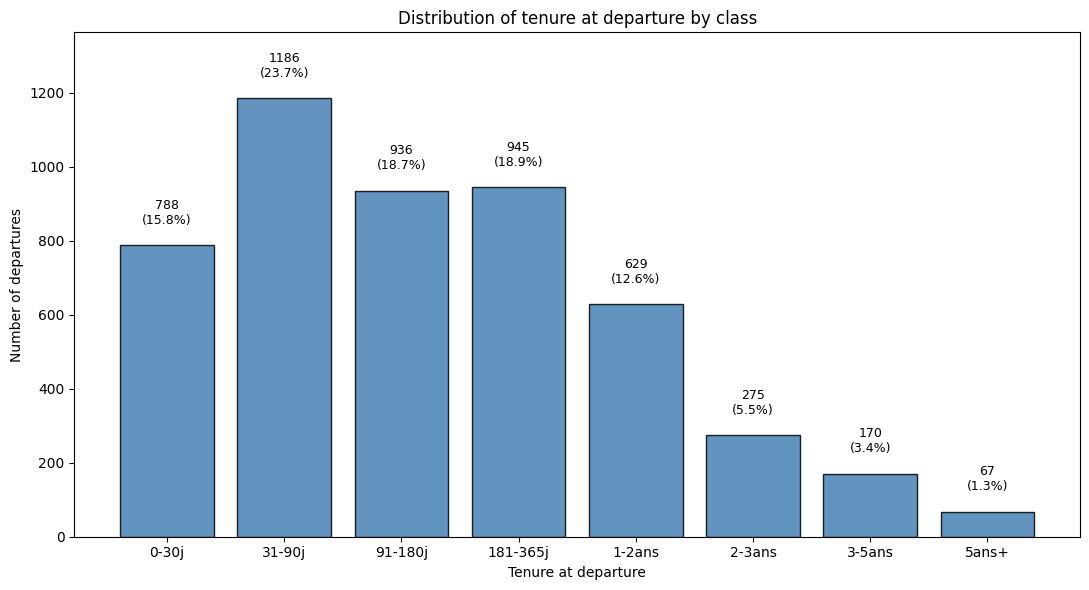

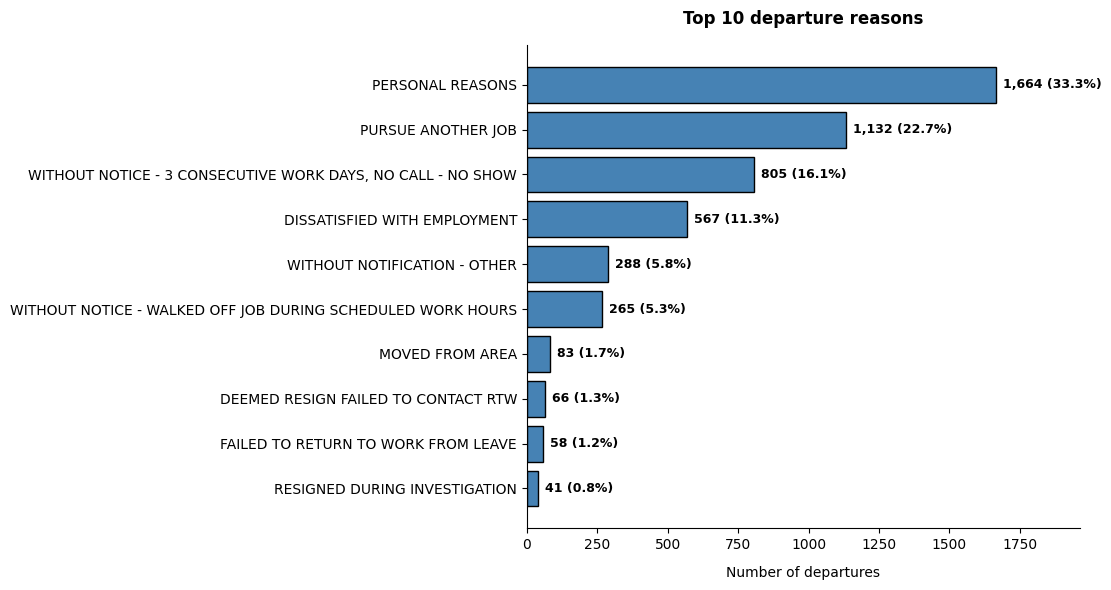

In [34]:
# DESCRIPTIVE ANALYSIS

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency
from itertools import combinations

plt.style.use("default")
sns.set_palette("muted")
 
# ============================================================
# 1. TENURE AT DEPARTURE
# ============================================================
section("1. Tenure at departure")

base_partants_final["term_date"] = pd.to_datetime(base_partants_final["term_date"], errors='coerce')

date_ref = "adjusted_hire_date" if "adjusted_hire_date" in base_partants_final.columns else "hire_date"
base_partants_final[date_ref] = pd.to_datetime(base_partants_final[date_ref], errors='coerce')

base_partants_final["anciennete_jours"] = (base_partants_final["term_date"] - base_partants_final[date_ref]).dt.days

paliers = [30, 90, 180, 365, 730]
print("\nShare of departures occurring before each threshold:")
for p in paliers:
    part = (base_partants_final["anciennete_jours"] <= p).mean() * 100
    print(f"  - Avant {p:>4} jours ({p/30.44:.1f} mois) : {part:.2f}%")
 

bins = [0, 30, 90, 180, 365, 730, 1095, 1825, np.inf]
labels = ["0-30j", "31-90j", "91-180j", "181-365j", "1-2ans", "2-3ans", "3-5ans", "5ans+"]
base_partants_final["classe_anciennete"] = pd.cut(base_partants_final["anciennete_jours"], bins=bins, labels=labels)
 
repartition_anc = base_partants_final["classe_anciennete"].value_counts().reindex(labels)
 
fig, ax = plt.subplots(figsize=(11, 6))
bars = ax.bar(repartition_anc.index, repartition_anc.values,
              color="steelblue", edgecolor="black", alpha=0.85)

total = repartition_anc.sum()
for bar, val in zip(bars, repartition_anc.values):
    pct = val / total * 100
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + total * 0.01,
            f"{val}\n({pct:.1f}%)", ha="center", va="bottom", fontsize=9)
 
ax.set_xlabel("Tenure at departure")
ax.set_ylabel("Number of departures")
ax.set_title("Distribution of tenure at departure by class")
ax.set_ylim(0, repartition_anc.max() * 1.15)
plt.tight_layout()
plt.show()
 

# ============================================================
# 2. PROFILE OF DEPARTURE REASONS
# ============================================================

col_motif = "reason_code"

if col_motif in base_partants_final.columns:
    # 1. Quick statistics in the console
    total_lignes = len(base_partants_final)
    non_na = base_partants_final[col_motif].notna().sum()
    nb_na = base_partants_final[col_motif].isna().sum()
    pct_remplissage = (non_na / total_lignes) * 100
    
    #print("═" * 70)
    #print(f" COLUMN PROFILE: {col_motif.upper()}")
    #print("═" * 70)
    #print(f" • Documented rows (non-NA) : {non_na:,} ({pct_remplissage:.2f}%)")
    #print(f" • Missing rows (NA)           : {nb_na:,} ({100 - pct_remplissage:.2f}%)")
    #print("-" * 70)
    #print("Top 10 raw reasons:\n", base_partants_final[col_motif].value_counts().head(10))
    #print("-" * 70)

    top_motifs = base_partants_final[col_motif].dropna().value_counts().head(10)
    total_motifs_valides = base_partants_final[col_motif].notna().sum()

    top_motifs_sorted = top_motifs.sort_values(ascending=True)

    fig, ax = plt.subplots(figsize=(11, 6))

    bars = ax.barh(
        top_motifs_sorted.index, 
        top_motifs_sorted.values,
        color="steelblue", 
        edgecolor="black"
    )

    for bar in bars:
        val = bar.get_width()
        pct = (val / total_motifs_valides) * 100
        ax.text(
            val + (total_motifs_valides * 0.005), 
            bar.get_y() + bar.get_height() / 2,
            f"{val:,} ({pct:.1f}%)", 
            va="center", 
            ha="left",
            fontsize=9,
            weight="bold"
        )

    # Chart aesthetic adjustments
    ax.set_xlabel("Number of departures", fontsize=10, labelpad=10)
    ax.set_title("Top 10 departure reasons", fontsize=12, pad=15, weight="bold")
    ax.set_xlim(0, top_motifs.max() * 1.18)
    
    # Nettoyage des bordures (spines) pour un rendu plus moderne
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    
    plt.tight_layout()
    plt.show()

else:
    print(f"[ERROR] Column '{col_motif}' not found in the DataFrame.")

### Tenure by main departure reasons

The distribution of tenure by main departure reasons shows that separations mainly concern employees with less than **one year** of tenure, regardless of the departure reason. Reasons related to **job dissatisfaction** or **absence without notice** particularly concern the most recent employees, while departures for **another job** are relatively more frequent among employees with **one to three years of tenure**. Departures of employees with more than three years of tenure remain generally minor, regardless of the reason considered.

The cumulative distribution of departures by month reveals slight seasonality. The months of **April** and **June** record the highest departure numbers, followed by **May** and **July**. Conversely, the months of **November** and **December** show the lowest departure levels. This trend suggests that departures are more concentrated during the second quarter of the year.



══════════════════════════════════════════════════════════════════════
  Cross-tab of departure reason x tenure
══════════════════════════════════════════════════════════════════════


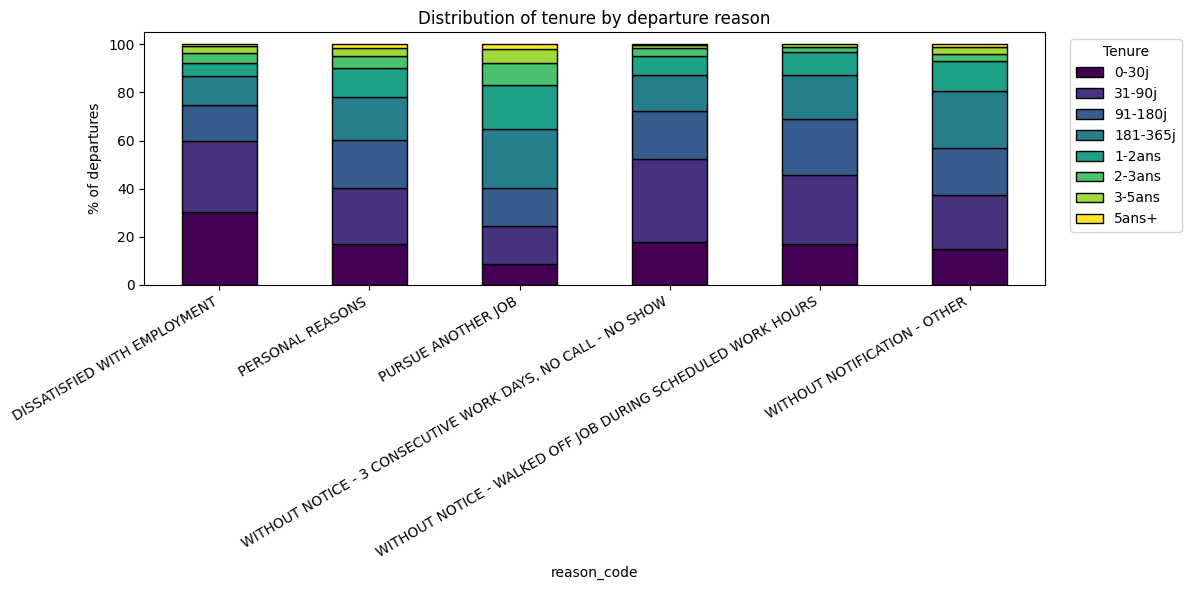

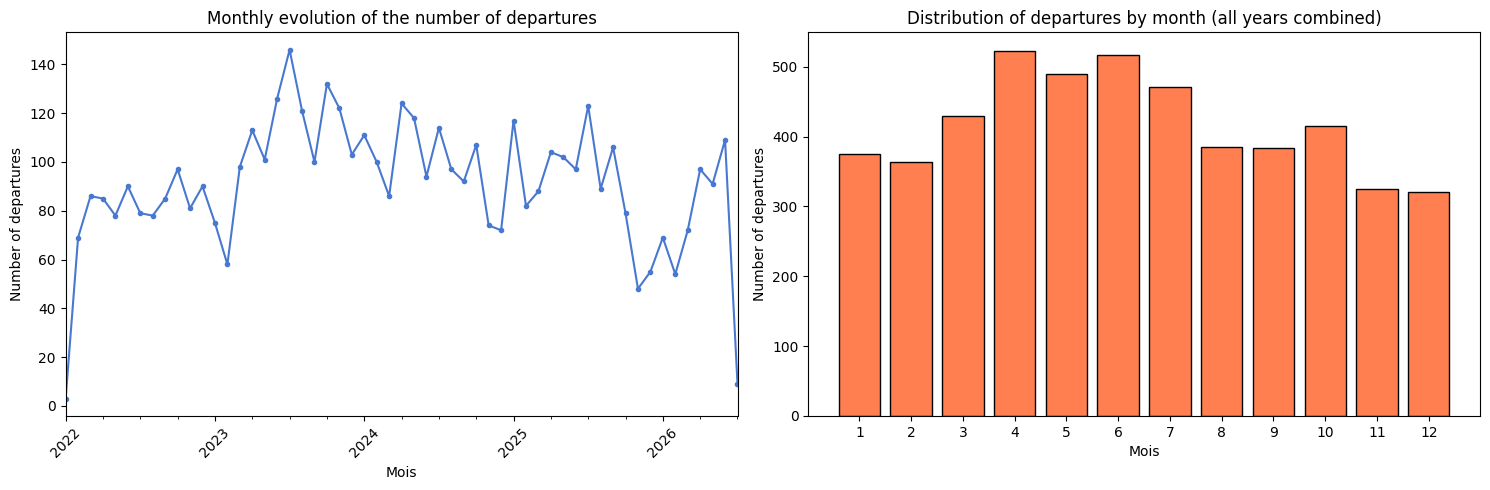

In [35]:

# 3. CROSS-TAB OF REASON & TENURE

section("Cross-tab of departure reason x tenure")

top6_motifs = base_partants_final["reason_code"].value_counts().head(6).index
df_crois = base_partants_final[base_partants_final["reason_code"].isin(top6_motifs)]

tab_crois = pd.crosstab(df_crois["reason_code"], df_crois["classe_anciennete"], normalize="index") * 100
#print("Distribution (%) of tenure for each reason (top 6):")
#print(tab_crois.round(1))

fig, ax = plt.subplots(figsize=(12, 6))
tab_crois.plot(kind="bar", stacked=True, ax=ax, colormap="viridis", edgecolor="black")
ax.set_ylabel("% of departures")
ax.set_title("Distribution of tenure by departure reason")
ax.legend(title="Tenure", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

# 4. SEASONALITY OF DEPARTURES
base_partants_final["annee_mois"] = base_partants_final["term_date"].dt.to_period("M")
base_partants_final["mois"] = base_partants_final["term_date"].dt.month
base_partants_final["annee"] = base_partants_final["term_date"].dt.year

serie_mensuelle = base_partants_final.groupby("annee_mois").size()

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
serie_mensuelle.plot(ax=axes[0], marker="o", markersize=3)
axes[0].set_title("Monthly evolution of the number of departures")
axes[0].set_xlabel("Mois")
axes[0].set_ylabel("Number of departures")
axes[0].tick_params(axis="x", rotation=45)


depart_par_mois = base_partants_final.groupby("mois").size()
axes[1].bar(depart_par_mois.index, depart_par_mois.values, color="coral", edgecolor="black")
axes[1].set_title("Distribution of departures by month (all years combined)")
axes[1].set_xlabel("Mois")
axes[1].set_ylabel("Number of departures")
axes[1].set_xticks(range(1, 13))

plt.tight_layout()
plt.show()


### Relationship between assigned site and departures

The independence test reveals a **statistically significant association** between employees' assigned site and observed departures (**p-value < 0.001**). The independence hypothesis is therefore rejected at the 5% threshold, suggesting that the distribution of departures varies significantly by site.

This result indicates that the **assigned site** could be a relevant explanatory factor in attrition analysis and deserves to be taken into account in in-depth descriptive analyses as well as in predictive models.

In [36]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.stats import chisquare

dc_sites=tables["dc_sites"]

dc_sites.rename(columns={'cost_center': 'department'}, inplace=True)

dc_sites_unique = dc_sites[["department", "dc_name"]].drop_duplicates(
    subset=["department"]
)

base_partants_final = pd.merge(
    base_partants_final,
    dc_sites_unique[["department", "dc_name"]], 
    left_on="department", 
    right_on="department",
    how="left",
)

df_dc_counts = base_partants_final["dc_name"].value_counts().to_frame(name="Nombre_de_departs")
df_dc_counts["Proportion (%)"] = (
    base_partants_final["dc_name"].value_counts(normalize=True) * 100
).round(2)


total_departs = df_dc_counts["Nombre_de_departs"].sum()
nb_sites = len(df_dc_counts)
depart_moyen_theorique = total_departs / nb_sites

print("\n" + "═" * 60)
print(" DISTRIBUTION OF THE NUMBER OF DEPARTURES BY DISTRIBUTION CENTER")
print("═" * 60)
print(df_dc_counts.to_string())
print("─" * 60)
print(f" Total departures analyzed  : {total_departs:,}")
print(f" Theoretical average per site : {depart_moyen_theorique:.1f} departures")
print("─" * 60)

# =====================================================================
# 2. HOMOGENEITY TEST (Is there a site-related dependency?)
# =====================================================================

f_obs = df_dc_counts["Nombre_de_departs"].values
stat, p_val = chisquare(f_obs)

print("\n" + "═" * 60)
print(" CORRELATION / DEPENDENCE ANALYSIS (GOODNESS-OF-FIT TEST)")
print("═" * 60)
print(f" • Test p-value     : {p_val:.4e}")
print("─" * 60)

if p_val < 0.05:
    print(
        " Finding: The p-value is FAR below 5%.\n"
        "               The number of departures is strongly correlated with/dependent\n"
        "               on the site."
    )
else:
    print(
        " Finding: No significant difference.\n"
        "               Departures are distributed homogeneously\n"
        "               across all Distribution Centers."
    )
print("═" * 60 + "\n")


════════════════════════════════════════════════════════════
 DISTRIBUTION OF THE NUMBER OF DEPARTURES BY DISTRIBUTION CENTER
════════════════════════════════════════════════════════════
                     Nombre_de_departs  Proportion (%)
dc_name                                               
Indianola                          319            6.40
San Antonio Fresh                  276            5.53
Longview                           272            5.45
Montgomery Fresh                   225            4.51
San Antonio                        212            4.25
Clayton Fresh                      211            4.23
Bethel                             207            4.15
Pottsville Fresh                   204            4.09
Jonesville                         201            4.03
Zanesville                         192            3.85
Ardmore                            188            3.77
Walton                             187            3.75
Alachua                            186    

In [37]:
from statsmodels.tsa.seasonal import seasonal_decompose, STL
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import adfuller
from scipy.stats import kruskal

In [38]:
base_partants_final['mois'] = base_partants_final['term_date'].values.astype('datetime64[M]')

serie_totale = base_partants_final.groupby('mois').size().rename('nb_departs')

# Full reindexing across the entire month range, without gaps
index_complet = pd.date_range(serie_totale.index.min(), serie_totale.index.max(), freq='MS')
serie_totale = serie_totale.reindex(index_complet, fill_value=0)
serie_totale.index.name = 'mois'

print(f"Series built over {len(serie_totale)} months")
serie_totale.head(12)

Series built over 55 months


mois
2022-01-01     3
2022-02-01    69
2022-03-01    86
2022-04-01    85
2022-05-01    78
2022-06-01    90
2022-07-01    79
2022-08-01    78
2022-09-01    85
2022-10-01    97
2022-11-01    81
2022-12-01    90
Freq: MS, Name: nb_departs, dtype: int64

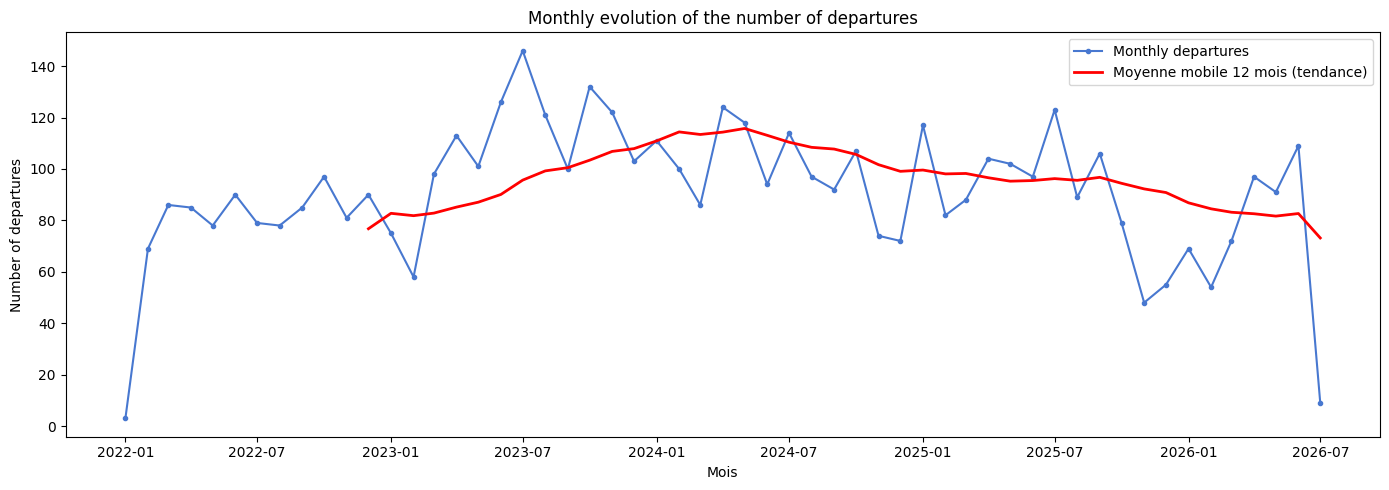

In [39]:
series_df = pd.DataFrame({
    'total': serie_totale
})
series_df.head(12)

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(series_df.index, series_df['total'], marker='o', markersize=3, label='Monthly departures')
ax.plot(series_df.index, series_df['total'].rolling(12).mean(), color='red', linewidth=2,
        label='Moyenne mobile 12 mois (tendance)')
ax.set_title("Monthly evolution of the number of departures")
ax.set_xlabel("Mois")
ax.set_ylabel("Number of departures")
ax.legend()
plt.tight_layout()
plt.show()

### Seasonality study

#### Decomposing the series (trend / seasonality / residual)

We use `STL` (Seasonal-Trend decomposition using Loess), which is more robust than classic
decomposition for noisy count series, with a periodicity fixed at 12 (annual seasonality
expected for HR data).

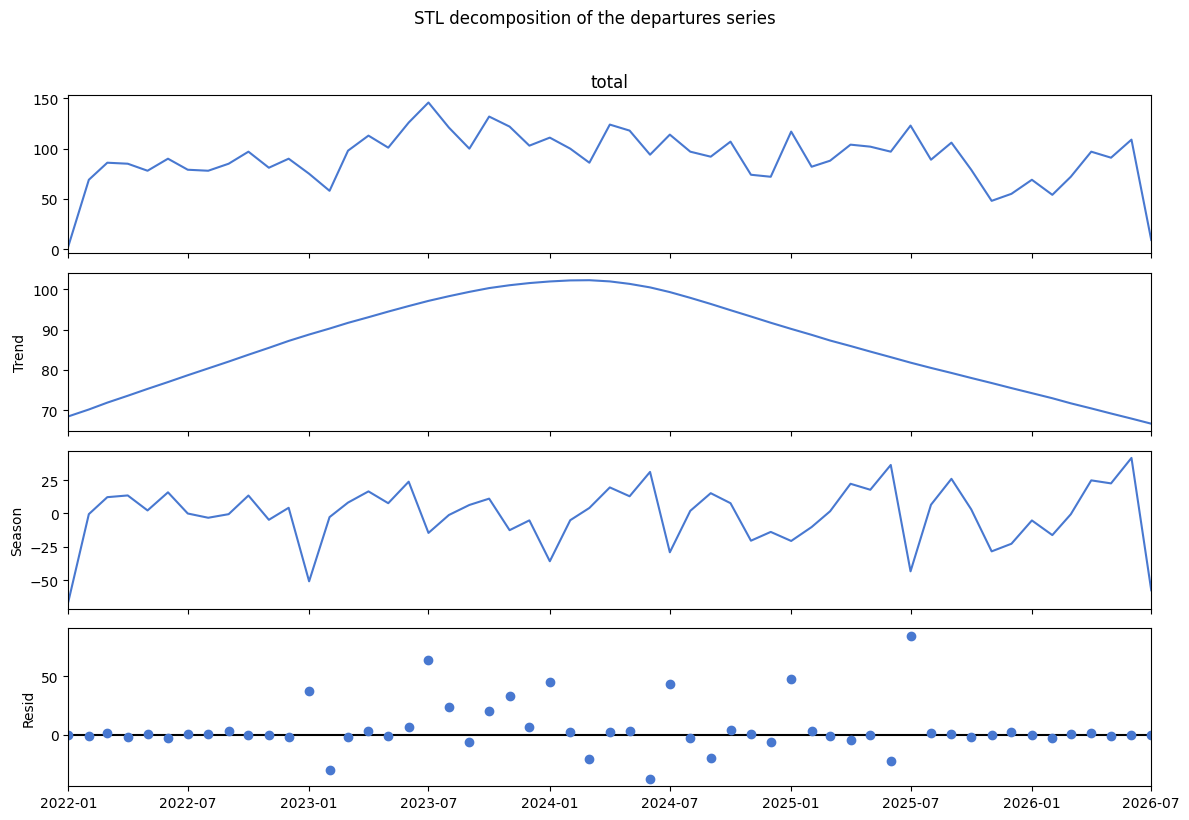

In [40]:
stl = STL(series_df['total'], period=12, robust=True)
resultat_stl = stl.fit()

fig = resultat_stl.plot()
fig.set_size_inches(12, 8)
plt.suptitle("STL decomposition of the departures series", y=1.02)
plt.tight_layout()
plt.show()

**Reading guide:**
- **Trend**: underlying evolution of the number of departures (structural growth/decline in attrition)
- **Seasonal**: pattern that repeats every year (e.g. peak in June/July, trough in December)
- **Resid**: what remains unexplained by the trend and seasonality (one-off shocks,
  exceptional events)

##### Seasonality strength (quantitative indicator)

A score between 0 (no seasonality) and 1 (very pronounced seasonality), based on the variance
of the residuals relative to the variance of (seasonal + residual).

In [41]:
var_resid = resultat_stl.resid.var()
var_saison_resid = (resultat_stl.seasonal + resultat_stl.resid).var()
force_saisonnalite = max(0, 1 - var_resid / var_saison_resid)

print(f"Seasonality strength: {force_saisonnalite:.2f}")
print("(close to 0 = no marked seasonality; close to 1 = very strong seasonality)")

Seasonality strength: 0.07
(close to 0 = no marked seasonality; close to 1 = very strong seasonality)


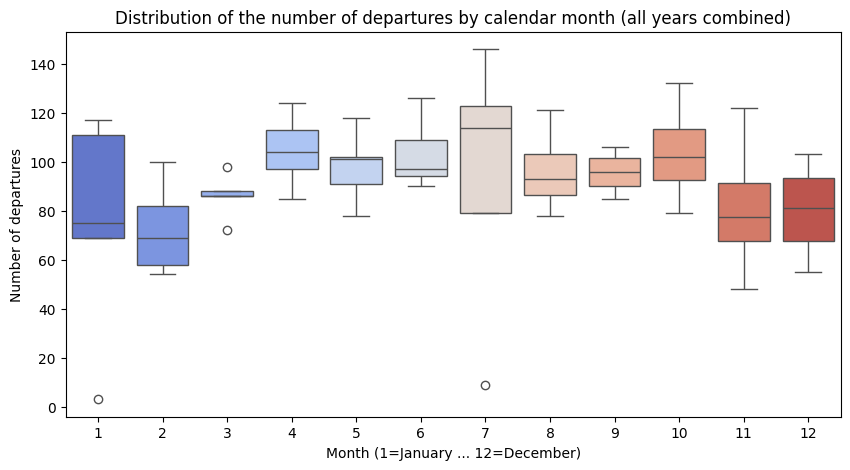

In [42]:
series_df_reset = series_df.reset_index()
series_df_reset['annee'] = series_df_reset['mois'].dt.year
series_df_reset['mois_calendaire'] = series_df_reset['mois'].dt.month

plt.figure(figsize=(10, 5))
sns.boxplot(data=series_df_reset, x='mois_calendaire', y='total', palette='coolwarm')
plt.title("Distribution of the number of departures by calendar month (all years combined)")
plt.xlabel("Month (1=January ... 12=December)")
plt.ylabel("Number of departures")
plt.show()

### Statistical seasonality test (Kruskal-Wallis)

We test whether the distribution of the number of departures differs significantly by
calendar month (a non-parametric test, suited to counts that do not necessarily follow a
normal distribution).

In [43]:
groupes = [g['total'].values for _, g in series_df_reset.groupby('mois_calendaire')]
stat, p_value = kruskal(*groupes)

print(f"Statistique de Kruskal-Wallis : {stat:.2f}")
print(f"p-value : {p_value:.4f}")

if p_value < 0.05:
    print("\n-> Significant difference between calendar months: seasonality is statistically confirmed.")
else:
    print("\n-> No significant difference detected between months (at the 5% threshold).")

Statistique de Kruskal-Wallis : 12.46
p-value : 0.3299

-> No significant difference detected between months (at the 5% threshold).


### Focus on Zanesville

In [44]:

sites_cibles = ["Zanesville Fresh", "Zanesville"]
df_zanesville = base_partants_final[base_partants_final["dc_name"].isin(sites_cibles)].reset_index(drop=True)

print("═" * 50)
print("FILTERING CHECK (ZANESVILLE)")
print("═" * 50)
print(df_zanesville["dc_name"].value_counts())
print("-" * 50)
print(f"Total extracted rows : {len(df_zanesville):,}")
print("═" * 50)



══════════════════════════════════════════════════
FILTERING CHECK (ZANESVILLE)
══════════════════════════════════════════════════
dc_name
Zanesville          192
Zanesville Fresh    139
Name: count, dtype: int64
--------------------------------------------------
Total extracted rows : 331
══════════════════════════════════════════════════


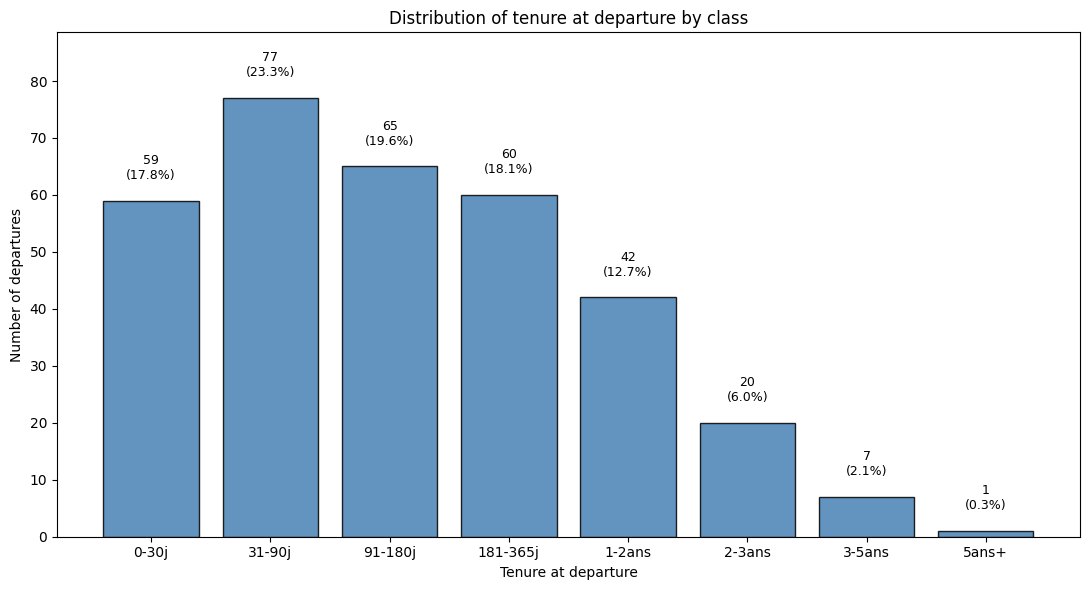

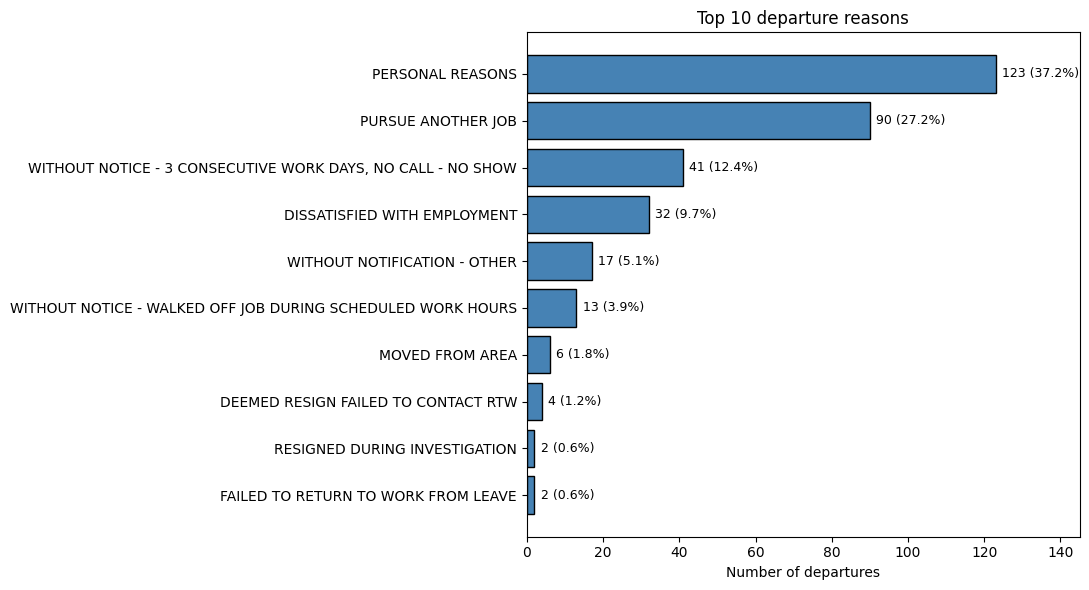

In [45]:
# DESCRIPTIVE ANALYSIS OF THE TERMINATION TABLE

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency
from itertools import combinations

plt.style.use("default")
sns.set_palette("muted")

 
repartition_anc = df_zanesville["classe_anciennete"].value_counts().reindex(labels)
 
fig, ax = plt.subplots(figsize=(11, 6))
bars = ax.bar(repartition_anc.index, repartition_anc.values,
              color="steelblue", edgecolor="black", alpha=0.85)

total = repartition_anc.sum()
for bar, val in zip(bars, repartition_anc.values):
    pct = val / total * 100
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + total * 0.01,
            f"{val}\n({pct:.1f}%)", ha="center", va="bottom", fontsize=9)
 
ax.set_xlabel("Tenure at departure")
ax.set_ylabel("Number of departures")
ax.set_title("Distribution of tenure at departure by class")
ax.set_ylim(0, repartition_anc.max() * 1.15)
plt.tight_layout()
plt.show()
 

# 2. PROFILE OF DEPARTURE REASONS 
 
fig, ax = plt.subplots(figsize=(11, 6))
top_motifs = df_zanesville["reason_code"].value_counts().head(10)
total_motifs = df_zanesville["reason_code"].notna().sum()
bars = ax.barh(top_motifs.sort_values().index, top_motifs.sort_values().values,
               color="steelblue", edgecolor="black")
 
for bar, val in zip(bars, top_motifs.sort_values().values):
    pct = val / total_motifs * 100
    ax.text(bar.get_width() + total_motifs * 0.005, bar.get_y() + bar.get_height() / 2,
            f"{val} ({pct:.1f}%)", va="center", fontsize=9)
 
ax.set_xlabel("Number of departures")
ax.set_title("Top 10 departure reasons")
ax.set_xlim(0, top_motifs.max() * 1.18)
plt.tight_layout()
plt.show()
 


### Tenure by main departure reasons at the Zanesville sites

The distribution of tenure by main departure reasons at the Zanesville site shows that separations mainly concern employees with less than **one year** of tenure, regardless of the departure reason. Reasons related to **job dissatisfaction** (`DISSATISFIED WITH EMPLOYMENT`) or **job abandonment** (`WITHOUT NOTICE 3 CONSECUTIVE WORK DAYS, NO CALL NO SHOW`) are very heavily concentrated among the most recent employees, with a critical share of departures occurring within the first month (0-30 days). Conversely, departures for **another job** (`PURSUE ANOTHER JOB`) are proportionally more frequent among employees with intermediate tenure of **one to five years**. Finally, departures of employees with more than five years of tenure remain generally marginal.  

The cumulative distribution of departures by month reveals a very pronounced spring seasonality at the Zanesville site. The months of **May** and **April** record by far the highest departure numbers, closely followed by **March**. Conversely, the months of **September** and **November** show the lowest departure levels of the year. This clear trend shows that terminations are heavily concentrated during **spring** (particularly at the end of the first quarter and the start of the second quarter), while activity stabilizes during the fall period.


══════════════════════════════════════════════════════════════════════
  Cross-tab of departure reason x tenure
══════════════════════════════════════════════════════════════════════


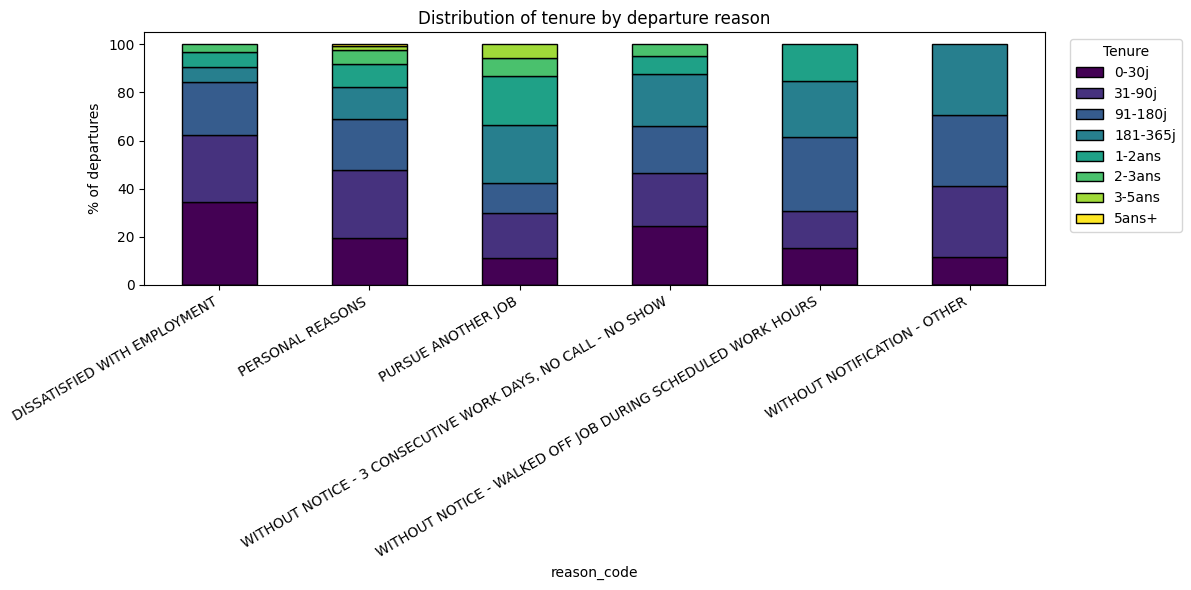

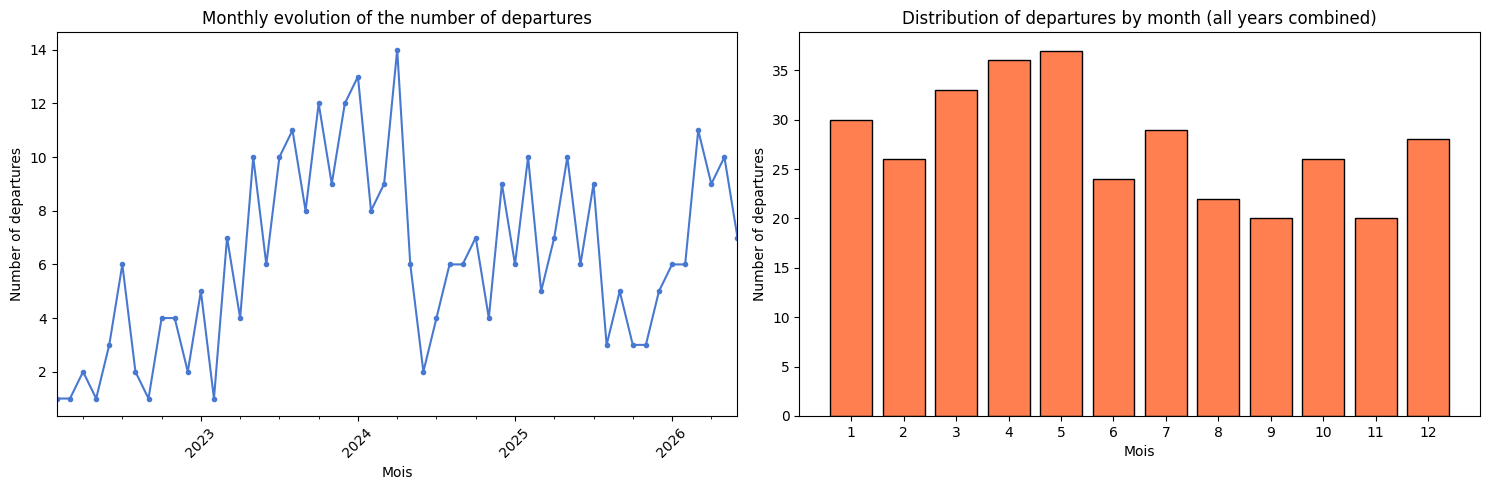

In [46]:

# 3. CROSS-TAB OF REASON & TENURE

section("Cross-tab of departure reason x tenure")

top6_motifs = df_zanesville["reason_code"].value_counts().head(6).index
df_crois = df_zanesville[df_zanesville["reason_code"].isin(top6_motifs)]

tab_crois = pd.crosstab(df_crois["reason_code"], df_crois["classe_anciennete"], normalize="index") * 100
#print("Distribution (%) of tenure for each reason (top 6):")
#print(tab_crois.round(1))

fig, ax = plt.subplots(figsize=(12, 6))
tab_crois.plot(kind="bar", stacked=True, ax=ax, colormap="viridis", edgecolor="black")
ax.set_ylabel("% of departures")
ax.set_title("Distribution of tenure by departure reason")
ax.legend(title="Tenure", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

# 4. SEASONALITY OF DEPARTURES

df_zanesville["annee_mois"] = df_zanesville["term_date"].dt.to_period("M")
df_zanesville["mois"] = df_zanesville["term_date"].dt.month
df_zanesville["annee"] = df_zanesville["term_date"].dt.year

serie_mensuelle = df_zanesville.groupby("annee_mois").size()

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
serie_mensuelle.plot(ax=axes[0], marker="o", markersize=3)
axes[0].set_title("Monthly evolution of the number of departures")
axes[0].set_xlabel("Mois")
axes[0].set_ylabel("Number of departures")
axes[0].tick_params(axis="x", rotation=45)


depart_par_mois = df_zanesville.groupby("mois").size()
axes[1].bar(depart_par_mois.index, depart_par_mois.values, color="coral", edgecolor="black")
axes[1].set_title("Distribution of departures by month (all years combined)")
axes[1].set_xlabel("Mois")
axes[1].set_ylabel("Number of departures")
axes[1].set_xticks(range(1, 13))

plt.tight_layout()
plt.show()

In [47]:

base_partants_final["rang_presence"] = base_partants_final.groupby("employee").cumcount() + 1
base_partants_final["C"] = 1
base_partants_final.columns = base_partants_final.columns.str.strip().str.lower()

print(f"Employees who left voluntarily: {len(base_partants_final)}")



Employees who left voluntarily: 4996


In [48]:
## SUMMARY OF INTERSECTIONS WITH THE Pay TABLE
Pay=tables["pay_weekly"]
set_Pay = set(Pay["employee"].dropna().astype(str))
set_terms = set(base_partants_final["employee"].dropna().astype(str))

terms_dans_Pay = len(set_terms & set_Pay)

print("\n" + "═" * 65)
print("SUMMARY OF INTERSECTIONS WITH THE Pay TABLE")
print("═" * 65)

print(
    f" TERMS EMPLOYEES PRESENT IN Pay           : {terms_dans_Pay:,} out of {len(set_terms):,}"
)

print("═" * 65 + "\n")


═════════════════════════════════════════════════════════════════
SUMMARY OF INTERSECTIONS WITH THE Pay TABLE
═════════════════════════════════════════════════════════════════
 TERMS EMPLOYEES PRESENT IN Pay           : 2,753 out of 4,830
═════════════════════════════════════════════════════════════════



### Table raw load quality

In [49]:
df_satisfaction = tables["satisfaction"]
cols_a_analyser = ["driver_id","title"]

for col in cols_a_analyser:
    if col in df_satisfaction.columns:
        
        total_lignes = len(df_satisfaction)
        nb_na = df_satisfaction[col].isna().sum()
        pct_na = (nb_na / total_lignes) * 100

        df_clean_col = (
            df_satisfaction[col]
            .fillna("MANQUANT_INTERNAL")
            .astype(str)
            .str.strip()
            .str.lower()
            .str.capitalize()
        )
        df_clean_col = df_clean_col.replace("Manquant_internal", np.nan)

        # Compute the number of distinct categories
        nb_distincts = df_clean_col.dropna().nunique()

        # Building the distribution table
        counts = df_clean_col.dropna().value_counts()
        percentages = df_clean_col.dropna().value_counts(normalize=True) * 100

        df_distribution = pd.DataFrame(
            {"Count": counts, "Percentage (%)": percentages}
        )

        # If the table is too long, only show the Top 15
        suffix_title = ""
        if len(df_distribution) > 15:
            df_distribution = df_distribution.head(15)
            suffix_title = " (Top 15 shown)"

        # 5. Displaying KPIs and titles
        print("\n" + "═" * 70)
        print(f" COLUMN ANALYSIS: {col.upper()}")
        print("═" * 70)
        print(f" • Number of distinct categories : {nb_distincts}")
        print(f" • Number of missing values (NA) : {nb_na} ({pct_na:.2f}%)")
        print(f" • Total number of rows             : {total_lignes}")
        print("-" * 70)

        # Using an HTML title
        display(
            HTML(f"<b>[Distribution table for {col}{suffix_title}]</b>")
        )

        # Formatting the Pandas table
        styled_df = df_distribution.style.format(
            {"Count": "{:,.0f}", "Percentage (%)": "{:.2f} %"}
        )
        display(styled_df)

    else:
        print("\n" + "═" * 70)
        print(
            f" [ERROR] Column '{col}' not found in the termination table."
        )
        print("═" * 70)


══════════════════════════════════════════════════════════════════════
 COLUMN ANALYSIS: DRIVER_ID
══════════════════════════════════════════════════════════════════════
 • Number of distinct categories : 4287
 • Number of missing values (NA) : 0 (0.00%)
 • Total number of rows             : 555449
----------------------------------------------------------------------


,Count,Percentage (%)
driver_id,,
3143581,954,0.17 %
3269219,795,0.14 %
3165210,631,0.11 %
2500618,616,0.11 %
3296952,603,0.11 %
3165142,572,0.10 %
3276392,568,0.10 %
3314867,561,0.10 %
2992739,552,0.10 %



══════════════════════════════════════════════════════════════════════
 COLUMN ANALYSIS: TITLE
══════════════════════════════════════════════════════════════════════
 • Number of distinct categories : 2
 • Number of missing values (NA) : 0 (0.00%)
 • Total number of rows             : 555449
----------------------------------------------------------------------


,Count,Percentage (%)
title,,
Load quality survey - dry,"368,947",66.42 %
Load quality survey - fresh,"186,502",33.58 %


In [50]:

df_satisfaction["submitted_at"] = pd.to_datetime(df_satisfaction["submitted_at"])
df_satisfaction = df_satisfaction[df_satisfaction["submitted_at"].dt.year.isin([2025, 2026])].reset_index(drop=True)

print(f"Lignes après filtre : {len(df_satisfaction):,}")
print(df_satisfaction["submitted_at"].dt.year.value_counts().sort_index())

dry_drivers   = set(df_satisfaction[df_satisfaction["title"] == "Load Quality Survey - Dry"]["driver_id"].unique())
fresh_drivers  = set(df_satisfaction[df_satisfaction["title"] == "Load Quality Survey - Fresh"]["driver_id"].unique())

only_dry       = dry_drivers - fresh_drivers
only_fresh     = fresh_drivers - dry_drivers
both           = dry_drivers & fresh_drivers

print(f"Chauffeurs uniquement Dry   : {len(only_dry)}")
print(f"Chauffeurs uniquement Fresh : {len(only_fresh)}")
print(f"Chauffeurs les deux         : {len(both)}")
print(f"Total unique                : {len(dry_drivers | fresh_drivers)}")

Lignes après filtre : 443,861
submitted_at
2025    289696
2026    154165
Name: count, dtype: int64
Chauffeurs uniquement Dry   : 1814
Chauffeurs uniquement Fresh : 802
Chauffeurs les deux         : 1190
Total unique                : 3806


In [51]:
# Cellule — Nombre d'audits par chauffeur par jour

df_satisfaction["date"] = pd.to_datetime(df_satisfaction["submitted_at"]).dt.date

dry_cols = ["wheels_broken","five_wheels_broken","five_rt_nets","water_five_layers",
            "heavy_toppers","secured_strap_tworows","etrac_straps_lastrow","clean_trailer",
            "stops_separated_loaddividers","store_labels","stops_loaded_sequence","trailer_threshold"]

dry = df_satisfaction[df_satisfaction["title"] == "Load Quality Survey - Dry"].copy()
dry = dry[dry[dry_cols].notna().any(axis=1)]

audits_par_jour = (
    dry.groupby(["driver_id", "date"])
    .size()
    .reset_index(name="n_audits_jour")
)

print(audits_par_jour["n_audits_jour"].value_counts().sort_index())
print(f"\nMax audits en 1 jour par 1 chauffeur : {audits_par_jour['n_audits_jour'].max()}")
print(f"\nExemple chauffeurs avec 2+ audits/jour :")
audits_par_jour[audits_par_jour["n_audits_jour"] >= 2].head(10)

n_audits_jour
1    28929
2     3354
3      144
4       35
5       10
Name: count, dtype: int64

Max audits en 1 jour par 1 chauffeur : 5

Exemple chauffeurs avec 2+ audits/jour :


,driver_id,date,n_audits_jour
46,1054036,2026-05-21,2
48,1054036,2026-05-28,2
51,1054036,2026-06-04,2
59,1054036,2026-06-18,2
66,1059424,2026-05-06,2
68,1059424,2026-05-14,2
69,1059424,2026-05-16,2
70,1059424,2026-05-20,2
83,1059424,2026-06-13,2
87,1059424,2026-06-20,2


In [52]:

standard_q_cols = [
    "wheels_broken","five_wheels_broken","five_rt_nets","water_five_layers",
    "heavy_toppers","secured_strap_tworows","etrac_straps_lastrow","clean_trailer",
    "stops_separated_loaddividers","store_labels","stops_loaded_sequence","trailer_threshold",
    "milk_crates_five_layers","front_freezer_door","pallets_height",
    "secure_strap_two_rows_alt","bulkhead_loadbar"
]

dg_cols = [c for c in df_satisfaction.columns if c.startswith("dg_")]

df_satisfaction["standard_filled"] = df_satisfaction[standard_q_cols].notna().any(axis=1)
df_satisfaction["dg_filled"]       = df_satisfaction[dg_cols].notna().any(axis=1)

#print(pd.crosstab(df_satisfaction["standard_filled"], df_satisfaction["dg_filled"], margins=True))
#print(pd.crosstab(df_satisfaction["title"], df_satisfaction["dg_filled"], margins=True))
#print(pd.crosstab(df_satisfaction["title"], df_satisfaction["standard_filled"], margins=True))

In [53]:
# Cellule — Nombre de questions remplies par ligne selon le groupe
standard = df_satisfaction[df_satisfaction["standard_filled"] == True]
dg = df_satisfaction[df_satisfaction["dg_filled"] == True]


In [54]:
STANDARD_QUESTIONS = {
    "wheels_broken":                "no",
    "five_wheels_broken":           "no",
    "five_rt_nets":                 "no",
    "water_five_layers":            "yes",
    "heavy_toppers":                "yes",
    "secured_strap_tworows":        "yes",
    "etrac_straps_lastrow":         "yes",
    "clean_trailer":                "yes",
    "stops_separated_loaddividers": "yes",
    "store_labels":                 "yes",
    "stops_loaded_sequence":        "yes",
    "trailer_threshold":            "no",
    "milk_crates_five_layers":      "yes",
    "front_freezer_door":           "no",
    "pallets_height":               "yes",
    "secure_strap_two_rows_alt":    "yes",
    "bulkhead_loadbar":             "yes",
}

DG_QUESTIONS = {
    "dg_rt_tires":                      "yes",
    "dg_rt_nets":                       "yes",
    "dg_rt_24_36_count":                "yes",
    "dg_fragile_toppers":               "no",
    "dg_stops_separated_load_divider":  "yes",
    "dg_labeled_product":               "yes",
    "dg_stops":                         "yes",
    "dg_rt_trailer_threshold":          "no",
    "dg_milk":                          "yes",
    "dg_empty_pallet":                  "no",
    "dg_pallets_7ft":                   "yes",
    "dg_bulkhead_secured":              "yes",
    "dg_secured_strap":                 "yes",
    "dg_clean_trailer":                 "yes",
}

def score_audit(row):
    if row["standard_filled"]:
        questions = STANDARD_QUESTIONS
        source = "standard"
    elif row["dg_filled"]:
        questions = DG_QUESTIONS
        source = "dg"
    else:
        return pd.Series({"source": None, "n_questions": None,
                          "n_correct": None, "compliance_pct": None})

    n_questions, n_correct = 0, 0
    for col, expected in questions.items():
        if pd.notna(row[col]):
            n_questions += 1
            if str(row[col]).strip().lower() == expected:
                n_correct += 1

    compliance_pct = round(n_correct / n_questions * 100, 2) if n_questions > 0 else None

    return pd.Series({
        "source":         source,
        "n_questions":    n_questions,
        "n_correct":      n_correct,
        "compliance_pct": compliance_pct,
    })

scores = df_satisfaction.apply(score_audit, axis=1)
df_scores = pd.concat(
    [df_satisfaction[["inbound_raw_events_id", "driver_id", "submitted_at", "title"]], scores],
    axis=1
)

df_scores = df_scores[df_scores["n_questions"] > 0].reset_index(drop=True)

print(f"{len(df_scores):,} audits scorés")
print(df_scores["source"].value_counts())
df_scores.head(10)

443,861 audits scorés
source
dg          390447
standard     53414
Name: count, dtype: int64


,inbound_raw_events_id,driver_id,submitted_at,title,source,n_questions,n_correct,compliance_pct
0,6a4af7c70c9af85a13d8dbd8,3670217,2026-07-06 00:33:06,Load Quality Survey - Fresh,standard,11,11,100.0
1,6a49a9cb5cdfdc2633c81653,3578269,2026-07-05 00:48:07,Load Quality Survey - Fresh,standard,11,11,100.0
2,6a498376bc50fa3a37369e49,3606701,2026-07-04 22:04:35,Load Quality Survey - Fresh,standard,11,11,100.0
3,6a496aedbc50fa3a37369ae9,3530118,2026-07-04 20:03:18,Load Quality Survey - Fresh,standard,11,11,100.0
4,6a4946945cdfdc2633c80777,3391792,2026-07-04 17:44:50,Load Quality Survey - Fresh,standard,11,11,100.0
5,6a492fbd5cdfdc2633c80177,2576046,2026-07-04 16:07:24,Load Quality Survey - Fresh,standard,11,11,100.0
6,6a4921dd0c9af85a13d8bbce,3849490,2026-07-04 15:08:10,Load Quality Survey - Fresh,standard,11,11,100.0
7,6a47f818bc50fa3a37364801,3085748,2026-07-03 17:57:41,Load Quality Survey - Fresh,standard,11,11,100.0
8,6a4717b40c9af85a13d830e2,3490755,2026-07-03 02:00:18,Load Quality Survey - Fresh,standard,11,11,100.0
9,6a46dfb15cdfdc2633c7642d,3801428,2026-07-02 22:01:20,Load Quality Survey - Fresh,standard,11,11,100.0


In [55]:
# Agrégation par chauffeur et par jour

df_scores["date"] = pd.to_datetime(df_scores["submitted_at"]).dt.date

driver_day_scores = (
    df_scores.groupby(["driver_id", "date"])
    .agg(
        n_audits        = ("inbound_raw_events_id", "count"),
        scores          = ("compliance_pct", list),
        dates_submitted = ("submitted_at", list),
        titles          = ("title", list)
    )
    .reset_index()
)

print(f"{len(driver_day_scores):,} lignes (chauffeur x jour)")
driver_day_scores.head(20)

385,142 lignes (chauffeur x jour)


,driver_id,date,n_audits,scores,dates_submitted,titles
0,1038133,2025-01-01,1,[33.33],[2025-01-01 19:43:27],[Load Quality Survey - Dry]
1,1038133,2025-01-02,1,[22.22],[2025-01-02 21:52:13],[Load Quality Survey - Dry]
2,1038133,2025-01-03,1,[11.11],[2025-01-03 23:00:00],[Load Quality Survey - Dry]
3,1038133,2025-01-07,1,[33.33],[2025-01-07 22:30:48],[Load Quality Survey - Dry]
4,1038133,2025-01-09,1,[44.44],[2025-01-09 22:05:00],[Load Quality Survey - Dry]
5,1038133,2025-01-10,1,[44.44],[2025-01-10 22:25:53],[Load Quality Survey - Dry]
6,1038133,2025-01-11,1,[66.67],[2025-01-11 23:50:02],[Load Quality Survey - Dry]
7,1038133,2025-01-14,1,[77.78],[2025-01-14 23:22:09],[Load Quality Survey - Dry]
8,1038133,2025-01-15,1,[33.33],[2025-01-15 23:52:18],[Load Quality Survey - Dry]
9,1038133,2025-01-17,1,[44.44],[2025-01-17 22:32:45],[Load Quality Survey - Dry]


## 1. Configuration necessaires

In [56]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.metrics import roc_auc_score, log_loss
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import roc_auc_score, log_loss, roc_curve
import xgboost as xgb
from lifelines import KaplanMeierFitter, CoxPHFitter
from lifelines.statistics import logrank_test
from lifelines.plotting import add_at_risk_counts
from sksurv.ensemble import RandomSurvivalForest
from sksurv.util import Surv
from sksurv.metrics import concordance_index_censored, integrated_brier_score
from sksurv.functions import StepFunction
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.model_selection import train_test_split
import shap


BUFFER_JOURS = 90 

COL_EMPLOYEE_PAY = "employee"
COL_CHECK_DATE = "check_date"
COL_WAGE_AMOUNT = "wage_amount"
COL_HOURS = "hours"
COL_RATE = "rate"
COL_CHECK_DESC = "check_desc"
COL_PAY_UNITS = "pay_units"
COL_PAY_SUM_GRP = "pay_sum_grp"
COL_DEPARTMENT = "department"
COL_JOB_CODE = "job_code"
COL_DATE_HIRED = "date_hired"


COL_EMPLOYEE_TERMS = "employee"
COL_DATE_DEPART = "term_date"  

DATE_SNAPSHOT = pd.Timestamp.today().normalize()


### Buffer temporel : date_reference + date_limite par employe

- Parti : date_reference = date de depart (terms_df)
- Actif : date_reference = date_snapshot (commune a tous les actifs)
- date_limite = date_reference - BUFFER_JOURS

C'est cette date_limite qui borne toutes les features en aval (paie,
discipline, satisfaction, watchlist, anciennete)

### Selection des actifs et merge

In [57]:
staffing=tables["staffing"]

cibles = ["Working", "Training"]
df_staffing = staffing[staffing["description"].isin(cibles)].reset_index(drop=True)

df_staffing.rename(columns={'eid': 'employee'}, inplace=True)
df_staffing.rename(columns={'cost_center_location': 'dc_name'}, inplace=True)
df_staffing["employee"] = df_staffing["employee"].astype(str).str.strip()
base_partants_final["employee"] = base_partants_final["employee"].astype(str).str.strip()
df_staffing["description"] = df_staffing["description"].astype(str).str.strip().str.title()
#df_staffing["description"] = df_staffing["description"].replace("Covid", "COVID")

ids_partants = set(base_partants_final["employee"])
staffing_sans_partants = df_staffing[~df_staffing["employee"].isin(ids_partants)].copy()

print(f"Staffing initial       : {len(df_staffing)} lignes")
print(f"Partants retirés        : {df_staffing['employee'].isin(ids_partants).sum()} lignes")
print(f"Staffing sans partants   : {len(staffing_sans_partants)} lignes")


actifs = staffing_sans_partants.copy()
print(f"{len(actifs)} employés retenus comme actifs")

actifs["description"].value_counts()

actifs["C"] = 0

actifs.columns = actifs.columns.str.strip().str.lower()

actifs_final = actifs[[
    "employee", "adjusted_hire_date", "c",
    "department", "dc_name"
]]

actifs_final.head()

Staffing initial       : 404594 lignes
Partants retirés        : 146533 lignes
Staffing sans partants   : 258061 lignes
258061 employés retenus comme actifs


,employee,adjusted_hire_date,c,department,dc_name
5,2950555,NaT,0,96144,JACKSON
10,2930395,NaT,0,96444,ATLANTA
14,3155424,NaT,0,98186,BLAIR FRESH
15,598715,NaT,0,96164,LONGVIEW
16,3143552,NaT,0,96144,JACKSON


In [58]:
actifs_uniques = actifs_final.drop_duplicates(
    subset=["employee"], keep="last"
).reset_index(drop=True)

actifs_uniques["rang_presence"] =1

# 3. Affichage du bilan du nettoyage
print("═" * 50)
print(" NETTOYAGE DES DOUBLONS TERMINÉ")
print("═" * 50)
print(f" Lignes avant filtrage : {len(actifs_final):,}")
print(f" Employés actifs      : {len(actifs_uniques):,}")
print(f" Doublons supprimés    : {len(actifs_final) - len(actifs_uniques):,}")
print("═" * 50)

══════════════════════════════════════════════════
 NETTOYAGE DES DOUBLONS TERMINÉ
══════════════════════════════════════════════════
 Lignes avant filtrage : 258,061
 Employés actifs      : 3,628
 Doublons supprimés    : 254,433
══════════════════════════════════════════════════


In [59]:
colonnes_interet = [
    "employee",
    "rang_presence",
    "dc_name",
    "department",
    "term_date",
    "c",
    "adjusted_hire_date"
]
base_partants_final = base_partants_final[colonnes_interet].copy()

data_final = pd.concat([base_partants_final, actifs_uniques], ignore_index=True)

### Attribution date limites

In [60]:
def attribuer_date_limite(df_all_drivers2, partants, date_snapshot, buffer_jours):
    
    terms_clean = partants.copy()
    
    terms_clean[COL_EMPLOYEE_TERMS] = (
        terms_clean[COL_EMPLOYEE_TERMS].astype(str).str.strip().str.lower()
    )
    terms_clean[COL_DATE_DEPART] = pd.to_datetime(terms_clean[COL_DATE_DEPART], errors="coerce")

    departs = terms_clean.set_index(COL_EMPLOYEE_TERMS)[COL_DATE_DEPART].to_dict()

    #employes = df_all_drivers2["employee"]
    
    ref = df_all_drivers2[["employee"]].copy()

    ref["date_reference"] = ref["employee"].map(departs)
    ref["est_parti"] = ref["date_reference"].notna()
    ref["date_reference"] = ref["date_reference"].fillna(date_snapshot)

    ref["date_limite"] = ref["date_reference"] - pd.Timedelta(days=buffer_jours)

    return ref[["employee", "date_reference", "est_parti", "date_limite"]]

dates_limites = attribuer_date_limite(data_final, base_partants_final, DATE_SNAPSHOT, BUFFER_JOURS)
dates_limites.tail

<bound method NDFrame.tail of      employee date_reference  est_parti date_limite
0     2374364     2025-01-26       True  2024-10-28
1     3723735     2026-02-02       True  2025-11-04
2     3723735     2026-02-02       True  2025-11-04
3     3005954     2025-02-20       True  2024-11-22
4     3631437     2025-08-21       True  2025-05-23
...       ...            ...        ...         ...
8619  3417192     2026-07-31      False  2026-05-02
8620  2668611     2026-07-31      False  2026-05-02
8621  1777149     2026-07-31      False  2026-05-02
8622  2536606     2026-07-31      False  2026-05-02
8623  2355491     2026-07-31      False  2026-05-02

[8624 rows x 4 columns]>

### Calcul des metrics de performances


In [61]:
def construire_df_weekly(tables):
    
    df_pay = tables["pay_weekly"].copy()

    df_pay[COL_EMPLOYEE_PAY] = df_pay[COL_EMPLOYEE_PAY].astype(str).str.strip().str.lower()
    df_pay[COL_CHECK_DATE] = pd.to_datetime(df_pay[COL_CHECK_DATE], errors="coerce")
    df_pay = df_pay.dropna(subset=[COL_CHECK_DATE])
    df_pay[COL_WAGE_AMOUNT] = pd.to_numeric(df_pay[COL_WAGE_AMOUNT], errors="coerce").fillna(0)

    df_pay["id_paye_unique"] = (
        df_pay[COL_EMPLOYEE_PAY] + "_" + df_pay[COL_CHECK_DATE].dt.strftime("%Y-%m-%d")
    )
    df_pay["id_pay"] = df_pay["id_paye_unique"].astype(str) + "_" + df_pay[COL_PAY_SUM_GRP].astype(str)
    df_pay = df_pay.drop_duplicates(subset="id_pay", keep="last")

    df_pay[COL_HOURS] = pd.to_numeric(df_pay[COL_HOURS], errors="coerce").fillna(0)
    df_pay[COL_RATE] = pd.to_numeric(df_pay[COL_RATE], errors="coerce").fillna(0)

    df_pay["miles_conduits"] = np.where(df_pay[COL_CHECK_DESC] == "#MILES", df_pay[COL_RATE], 0)
    df_pay["stops_faits"] = np.where(df_pay[COL_CHECK_DESC] == "#STOPS", df_pay[COL_RATE], 0)
    df_pay["heures_travaillees"] = np.where(df_pay[COL_CHECK_DESC] == "HRS ONLY", df_pay[COL_HOURS], 0)
    df_pay["rate_mile_ligne"] = np.where(df_pay[COL_CHECK_DESC] == "#MILES", df_pay[COL_PAY_UNITS], np.nan)

    df_weekly1 = (
        df_pay.groupby("id_paye_unique")
        .agg(
            department=(COL_DEPARTMENT, "first"),
            job_code=(COL_JOB_CODE, "first"),
            date_hired=(COL_DATE_HIRED, "first"),
            employee=(COL_EMPLOYEE_PAY, "first"),
            check_date=(COL_CHECK_DATE, "first"),
            salaire_total=(COL_WAGE_AMOUNT, "sum"),
            total_miles=("miles_conduits", "sum"),
            total_stops=("stops_faits", "sum"),
            total_hours=("heures_travaillees", "sum"),
            rate_per_mile=("rate_mile_ligne", "mean"),
        )
        .reset_index()
        .sort_values(by=["employee", "check_date"])
    )

    df_weekly1 = df_weekly1.set_index("check_date")

    df_weekly1["avg_weekly_miles_90d"] = (
        df_weekly1.groupby("employee")["total_miles"].rolling(window="90D", min_periods=1).mean().values
    )
    df_weekly1["avg_weekly_stops_90d"] = (
        df_weekly1.groupby("employee")["total_stops"].rolling(window="90D", min_periods=1).mean().values
    )
    df_weekly1["avg_weekly_wage_90d"] = (
        df_weekly1.groupby("employee")["salaire_total"].rolling(window="90D", min_periods=1).mean().values
    )

    df_weekly1["total_miles_90d"] = (
        df_weekly1.groupby("employee")["total_miles"]
        .rolling(window="90D", min_periods=1)
        .sum()
        .values
    )

    df_weekly1["total_stops_90d"] = (
        df_weekly1.groupby("employee")["total_stops"]
        .rolling(window="90D", min_periods=1)
        .sum()
        .values
    )

    df_weekly1["total_salaire_90d"] = (
        df_weekly1.groupby("employee")["salaire_total"]
        .rolling(window="90D", min_periods=1)
        .sum()
        .values
    )

    df_weekly1["dc_avg_rate"] = df_weekly1.groupby("department")["rate_per_mile"].transform("mean")
    df_weekly1["region_avg_rate"] = df_weekly1["rate_per_mile"].mean()
    df_weekly1["rate_vs_dc_pct"] = df_weekly1["rate_per_mile"] / df_weekly1["dc_avg_rate"]
    df_weekly1["rate_vs_region_pct"] = df_weekly1["rate_per_mile"] / df_weekly1["region_avg_rate"]

    df_weekly1["prev_check_date"] = (
        df_weekly1.groupby("employee").apply(lambda x: x.index.to_series().shift(1)).values
    )
    df_weekly1["pay_gap_days"] = (df_weekly1.index - df_weekly1["prev_check_date"]).dt.days
    df_weekly1["is_pay_gap"] = (df_weekly1["pay_gap_days"] > 8) | (df_weekly1["salaire_total"] == 0)

    df_weekly1["avg_hours_past_3w"] = (
        df_weekly1.groupby("employee")["total_hours"].rolling(window="21D", min_periods=1).mean().values
    )
    df_weekly1["hours_declining"] = (
        (df_weekly1["total_hours"] < (df_weekly1["avg_hours_past_3w"] * 0.75))
        & (df_weekly1["avg_hours_past_3w"] > 0)
    )

    df_weekly1["wage_std_90d"] = (
        df_weekly1.groupby("employee")["salaire_total"].rolling(window="90D", min_periods=3).std().values
    )
    df_weekly1["wage_volatility_pct"] = df_weekly1["wage_std_90d"] / df_weekly1["avg_weekly_wage_90d"]

    return df_weekly1.reset_index()

df_weekly = construire_df_weekly(tables)
df_weekly.head()

,check_date,id_paye_unique,department,job_code,date_hired,employee,salaire_total,total_miles,total_stops,total_hours,...,region_avg_rate,rate_vs_dc_pct,rate_vs_region_pct,prev_check_date,pay_gap_days,is_pay_gap,avg_hours_past_3w,hours_declining,wage_std_90d,wage_volatility_pct
0,2024-01-05,1038133_2024-01-05,96604,1807,2008-02-14,1038133,1984.98,0.54,51.0,61.81,...,1277.535329,0.788465,0.879271,NaT,NaN,False,61.810000,False,NaN,NaN
1,2024-01-12,1038133_2024-01-12,96604,1807,2008-02-14,1038133,2157.18,0.54,51.0,103.70,...,1277.535329,1.091343,1.217031,2024-01-05,7.0,False,82.755000,False,NaN,NaN
2,2024-01-19,1038133_2024-01-19,96604,1807,2008-02-14,1038133,1373.99,0.54,51.0,67.75,...,1277.535329,0.780533,0.870426,2024-01-12,7.0,False,77.753333,False,411.571824,0.223836
3,2024-01-26,1038133_2024-01-26,96604,1807,2008-02-14,1038133,1596.16,0.54,51.0,17.66,...,1277.535329,0.706411,0.787767,2024-01-19,7.0,False,63.036667,True,357.261825,0.200926
4,2024-02-02,1038133_2024-02-02,96604,1807,2008-02-14,1038133,1717.48,0.54,51.0,47.41,...,1277.535329,1.075900,1.199810,2024-01-26,7.0,False,44.273333,False,310.582388,0.175872


### Selection dans Wage des paies de 2025 et 2026

In [62]:
import pandas as pd

# 1. S'assurer que la colonne est bien au format Date
df_weekly['check_date'] = pd.to_datetime(df_weekly['check_date'])

# 2. Calculer la fréquence par année (triée par ordre chronologique)
frequences = df_weekly['check_date'].dt.year.value_counts().sort_index()
print(frequences)

# Filtrer sur les années 2025 et 2026
#df_weekly = df_weekly[df_weekly['check_date'].dt.year.isin([2025, 2026])]
df_weekly = df_weekly[df_weekly['check_date'].dt.year.isin([2025, 2026])].copy()

# Vérification optionnelle
print(f"Nombre de lignes restantes : {len(df_weekly)}")

check_date
2024    106438
2025    105111
2026     54504
Name: count, dtype: int64
Nombre de lignes restantes : 159615


### Verification des correspondances

In [63]:
# 1. Extraction et nettoyage des identifiants d'employés dans les deux bases
employees_score = set(
    df_scores['driver_id'].dropna().astype(str).str.strip().str.lower()
)

col_emp_weekly = 'employee' if 'employee' in df_weekly.columns else 'eid'
employees_weekly = set(
    df_weekly[col_emp_weekly].dropna().astype(str).str.strip().str.lower()
)

communs = employees_score.intersection(employees_weekly)

nb_score = len(employees_score)
nb_communs = len(communs)
pct = (nb_communs / nb_score * 100) if nb_score > 0 else 0

print(f"Employés uniques dans df_score : {nb_score}")
print(f"Employés uniques dans Wage : {len(employees_weekly)}")
print(f"Employés de df_score présents dans Wage : {nb_communs} ({pct:.2f}%)")

Employés uniques dans df_score : 3806
Employés uniques dans Wage : 4272
Employés de df_score présents dans Wage : 3802 (99.89%)


In [64]:
df_compensation=tables["conpensation_plan"].copy()

def calculer_indicateurs_performance_90d(df_weekly, df_compensation):
    df = df_weekly.copy()
    comp = df_compensation.copy()

    # 1. Nettoyage et harmonisation des clés de jonction
    df["department_clean"] = df["department"].astype(str).str.strip().str.lower()
    comp["cost_center_clean"] = comp["cost_center"].astype(str).str.strip().str.lower()

    # 2. Joindre la table compensation_plan pour récupérer les prévisions annuelles
    df = df.merge(
        comp[["cost_center_clean", "average_w2", "comps_target_for_miles", "comps_target_for_stops"]],
        left_on="department_clean",
        right_on="cost_center_clean",
        how="left"
    )

    DIVISEUR_PERIODE = 3 
    
    df["prev_miles_90d"] = df["comps_target_for_miles"] / DIVISEUR_PERIODE
    df["prev_stops_90d"] = df["comps_target_for_stops"] / DIVISEUR_PERIODE
    df["prev_wage_90d"] = df["average_w2"] / DIVISEUR_PERIODE

    # 4. Calcul des Ratios de Performance (Réel 90d / Prévision 90d)
    df["perf_miles_pct_90d"] = df["total_miles_90d"] / df["prev_miles_90d"]
    df["perf_stops_pct_90d"] = df["total_stops_90d"] / df["prev_stops_90d"]
    df["perf_wage_pct_90d"] = df["total_salaire_90d"] / df["prev_wage_90d"]

    # 5. Nettoyage des colonnes temporaires
    #cols_to_drop = ["department_clean", "cost_center_clean"]
    #df = df.drop(columns=[c for c in cols_to_drop if c in df.columns])

    return df

df_weekly= calculer_indicateurs_performance_90d(df_weekly, df_compensation)
#df_weekly_perf= calculer_indicateurs_performance_90d(df_weekly, df_compensation)
df_weekly.head()

,check_date,id_paye_unique,department,job_code,date_hired,employee,salaire_total,total_miles,total_stops,total_hours,...,cost_center_clean,average_w2,comps_target_for_miles,comps_target_for_stops,prev_miles_90d,prev_stops_90d,prev_wage_90d,perf_miles_pct_90d,perf_stops_pct_90d,perf_wage_pct_90d
0,2025-01-03,1038133_2025-01-03,96604,1807,2008-02-14,1038133,2564.63,0.55,52.0,42.89,...,96604,75000.0,1350.0,11.0,450.0,3.666667,25000.0,0.015889,184.363636,1.016312
1,2025-01-10,1038133_2025-01-10,96604,1807,2008-02-14,1038133,1648.95,0.55,52.0,43.14,...,96604,75000.0,1350.0,11.0,450.0,3.666667,25000.0,0.015889,184.363636,0.940766
2,2025-01-17,1038133_2025-01-17,96604,1807,2008-02-14,1038133,1673.02,0.55,52.0,55.02,...,96604,75000.0,1350.0,11.0,450.0,3.666667,25000.0,0.015889,184.363636,0.983876
3,2025-01-24,1038133_2025-01-24,96604,1807,2008-02-14,1038133,1736.44,0.55,52.0,55.42,...,96604,75000.0,1350.0,11.0,450.0,3.666667,25000.0,0.015889,184.363636,0.988328
4,2025-02-07,1038133_2025-02-07,96604,1807,2008-02-14,1038133,1707.97,0.55,52.0,55.28,...,96604,75000.0,1350.0,11.0,450.0,3.666667,25000.0,0.014667,170.181818,0.936892


In [65]:
def construire_profil_employe(df_weekly, terms_df, date_snapshot, buffer_jours):
    
    dates_limites = attribuer_date_limite(df_weekly, base_partants_final, date_snapshot, buffer_jours)

    df = df_weekly.merge(dates_limites, on="employee", how="left")

    df_filtre = df[df["check_date"] <= df["date_limite"]].copy()

    n_exclus = df["employee"].nunique() - df_filtre["employee"].nunique()
    if n_exclus > 0:
        print(f"Attention : {n_exclus} employe(s) exclu(s) : aucune donnee disponible avant leur date_limite "
              f"(anciennete < {buffer_jours} jours au moment du depart/snapshot).")

    df_employee_profile = (
        df_filtre.groupby("employee")
        .agg(
            department=("department", "last"),
            job_code=("job_code", "last"),
            date_hired=("date_hired", "last"),
            date_limite=("date_limite", "last"),
            est_parti=("est_parti", "last"),
            salaire_cumule=("salaire_total", "sum"),
            miles_cumules=("total_miles", "sum"),
            stops_cumules=("total_stops", "sum"),
            heures_cumulees=("total_hours", "sum"),
            avg_weekly_miles_actuel=("avg_weekly_miles_90d", "last"),
            avg_weekly_stops_actuel=("avg_weekly_stops_90d", "last"),
            avg_weekly_wage_actuel=("avg_weekly_wage_90d", "last"),
            volatilite_salariale_actuelle=("wage_volatility_pct", "last"),
            rate_vs_dc_moyen=("rate_vs_dc_pct", "mean"),
            rate_vs_region_moyen=("rate_vs_region_pct", "mean"),
            nombre_de_pay_gaps=("is_pay_gap", "sum"),
            nombre_semaines_declin=("hours_declining", "sum"),
            derniere_semaine_en_declin=("hours_declining", "last"),
            nb_semaines_observees=("check_date", "count"),
            perf_wage_pct_90d=("perf_wage_pct_90d", "last"),
            perf_stops_pct_90d=("perf_stops_pct_90d", "last"),
            perf_miles_pct_90d=("perf_miles_pct_90d", "last"),
            rate_per_mile=("rate_per_mile", "mean")
        )
        .reset_index()
    )

    for col in ["salaire_cumule", "miles_cumules", "stops_cumules", "heures_cumulees"]:
        df_employee_profile[f"{col}_par_semaine"] = (
            df_employee_profile[col] / df_employee_profile["nb_semaines_observees"].replace(0, np.nan)
        )

    df_employee_profile["Y"] = df_employee_profile["est_parti"].astype(int)

    return df_employee_profile

all_drivers = construire_profil_employe(df_weekly, base_partants_final, DATE_SNAPSHOT, BUFFER_JOURS)
#dates_limites = attribuer_date_limite(df_weekly, terms_df, DATE_SNAPSHOT, BUFFER_JOURS)
all_drivers.head()

Attention : 1055 employe(s) exclu(s) : aucune donnee disponible avant leur date_limite (anciennete < 90 jours au moment du depart/snapshot).


,employee,department,job_code,date_hired,date_limite,est_parti,salaire_cumule,miles_cumules,stops_cumules,heures_cumulees,...,nb_semaines_observees,perf_wage_pct_90d,perf_stops_pct_90d,perf_miles_pct_90d,rate_per_mile,salaire_cumule_par_semaine,miles_cumules_par_semaine,stops_cumules_par_semaine,heures_cumulees_par_semaine,Y
0,1038133,96604,1807,2008-02-14,2026-05-02,False,10416902.13,3099.87,293220.0,289016.10,...,5751,1.040582,187.909091,0.016178,1548.900870,1811.320141,0.539014,50.985915,50.254930,0
1,1054036,96604,1807,2008-04-07,2026-05-02,False,1661407.34,252.84,25800.0,46458.92,...,1462,0.734268,163.636364,0.013067,1454.976667,1136.393529,0.172941,17.647059,31.777647,0
2,106214,96494,1807,1998-10-09,2026-05-02,False,7933571.73,2780.19,176463.0,200572.47,...,3969,0.728507,60.720000,0.021600,1052.007742,1998.884286,0.700476,44.460317,50.534762,0
3,1083695,96604,1807,2008-06-26,2026-05-02,False,1271410.53,191.10,17550.0,33404.67,...,1170,0.631214,122.727273,0.010889,1190.114000,1086.675667,0.163333,15.000000,28.551000,0
4,1105323,96164,1807,2008-08-26,2025-02-14,True,187086.73,67.26,6270.0,4128.32,...,114,0.664905,198.000000,0.014160,1133.803333,1641.111667,0.590000,55.000000,36.213333,1


### 6. Enrichissements bornes : discipline, satisfaction, watchlist, anciennete

In [66]:
df_watchlist=tables["watch_list"]

def _parser_liste_dates(chaine, sep=","):
    if pd.isna(chaine) or str(chaine).strip() == "":
        return []
    morceaux = [d.strip() for d in str(chaine).split(sep) if d.strip() != ""]
    dates = pd.to_datetime(morceaux, errors="coerce")
    return [d for d in dates if pd.notna(d)]


def construire_nb_actions_bornee(df_analyse_discipline, dates_limites_df,
                                 col_liste="liste_action_dates", sep=","):
    df_discipline = df_analyse_discipline.copy()
    df_discipline["employee"] = df_discipline["eid"].astype(str).str.strip().str.lower()
    
    df = df_discipline.merge(
        dates_limites_df[["employee", "date_limite"]], on="employee", how="left"
    )
    def compter(row):
        if pd.isna(row["date_limite"]):
            return np.nan
        dates = _parser_liste_dates(row[col_liste], sep=sep)
        return sum(d <= row["date_limite"] for d in dates)

    df["nb_indiscipline"] = df.apply(compter, axis=1)
    return df[["employee", "nb_indiscipline"]].drop_duplicates(subset=["employee"])

    
def construire_nb_voe_bornee(df_analyse, dates_limites_df,
                             col_liste="liste_created_date", sep=","):
    
    df = df_analyse.copy()

    df["employee"] = df["eid"].astype(str).str.strip().str.lower() 

    df = df.merge(
        dates_limites_df[["employee", "date_limite"]], on="employee", how="left"
    )

    def compter(row):
        if pd.isna(row["date_limite"]):
            return np.nan
        dates = _parser_liste_dates(row[col_liste], sep=sep)
        return sum(d <= row["date_limite"] for d in dates)

    df["nb_voe_requested_t"] = df.apply(compter, axis=1)
 
    return (
        df[["employee", "nb_voe_requested_t"]]
        .sort_values(by="nb_voe_requested_t", ascending=False)
        .drop_duplicates(subset=["employee"], keep="first")
    )


def construire_watchlist_bornee(df_watchlist, dates_limites_df):

    dl_clean = dates_limites_df[["employee", "date_limite"]].dropna()
    dl_map = dict(zip(
        dl_clean["employee"].astype(str).str.strip().str.lower(), 
        pd.to_datetime(dl_clean["date_limite"])
    ))

    colonnes_utiles = ["employee_number", "datetimereceived", "watchlist_score", "change_in_last_30_days"]
    df = df_watchlist[colonnes_utiles].copy()
    
    df["employee"] = df["employee_number"].astype(str).str.strip().str.lower()
    df["datetimereceived"] = pd.to_datetime(df["datetimereceived"], errors="coerce")
    
    df = df[df["employee"].isin(dl_map.keys())]

    df["date_limite"] = df["employee"].map(dl_map)

    df = df[df["datetimereceived"] <= df["date_limite"]]

    df_agg = (
        df.sort_values("datetimereceived")
        .groupby("employee", as_index=False)
        .agg(
            watchlist_score_actuel=("watchlist_score", "last"),
            change_last_30_days_actuel=("change_in_last_30_days", "last"),
            last_date_watchlist=("datetimereceived", "last"),
        )
    )
    
    return df_agg


def construire_anciennete_nouv(df_population, dates_limites_df, col_date_hired="date_hired"):
    df_pop = df_population.copy()
    df_pop["employee"] = df_pop["employee"].astype(str).str.strip().str.lower()
    
    dl_clean = dates_limites_df[["employee", "date_limite"]].copy()
    dl_clean["employee"] = dl_clean["employee"].astype(str).str.strip().str.lower()
    dl_clean = dl_clean.drop_duplicates(subset=["employee"], keep="last")

    df = df_pop.merge(dl_clean, on="employee", how="left")
    
    df[col_date_hired] = pd.to_datetime(df[col_date_hired], errors="coerce")
    df["duree"] = (df["date_limite"] - df[col_date_hired]).dt.days

    bornes = [-1, 30, 365, 1825, np.inf]
    labels = ["[0-30j]", "[31-365j]", "[366j a 5ans]", "[Plus de 5 ans]"]
    
    df["anciennete_nouv"] = pd.cut(df["duree"], bins=bornes, labels=labels)

    return df[["employee", "duree", "anciennete_nouv"]].drop_duplicates(subset=["employee"])


def construire_nb_inspection_bornee(df_roadside, dates_limites_df):
  
    df = df_roadside.copy()
    df["employee"] = df["eid"].astype(str).str.strip().str.lower()
    df["date_of_inspection"] = pd.to_datetime(df["date_of_inspection"], errors="coerce")
    

    dl = dates_limites_df[["employee", "date_limite"]].copy()
    dl["employee"] = dl["employee"].astype(str).str.strip().str.lower()
    dl["date_limite"] = pd.to_datetime(dl["date_limite"])
    
    df = df.merge(dl, on="employee", how="inner")
    
    # Filtrer : uniquement les inspections passées ou égales à la date limite
    df = df[df["date_of_inspection"] <= df["date_limite"]]
    
    df_agg = (
        df.groupby("employee", as_index=False)
        .agg(nb_inspection=("date_of_inspection", "nunique"))
    )
    
    return df_agg


def construire_score_borne(df_score, dates_limites_df, col_date="submitted_at"):
    """
    Calcule le nombre d'enquêtes et la moyenne du taux de conformité 
    pour chaque chauffeur jusqu'à sa date_limite.
    """
    df = df_scores.copy()
    
    # Nettoyage de l'ID employé (driver_id)
    df["employee"] = df["driver_id"].astype(str).str.strip().str.lower()
    df[col_date] = pd.to_datetime(df[col_date], errors="coerce")
    
    # Nettoyage des dates limites
    dl = dates_limites_df[["employee", "date_limite"]].copy()
    dl["employee"] = dl["employee"].astype(str).str.strip().str.lower()
    dl["date_limite"] = pd.to_datetime(dl["date_limite"])
    
    # Jonction et filtrage temporel
    df = df.merge(dl, on="employee", how="inner")
    df = df[df[col_date] <= df["date_limite"]]
    
    # Agrégation par chauffeur
    df_agg = (
        df.groupby("employee", as_index=False)
        .agg(
            nb_surveys=("inbound_raw_events_id", "nunique"),
            avg_compliance_pct=("compliance_pct", "mean")
        )
    )
    
    return df_agg


def enrichir_df_all_drivers(all_drivers, dates_limites_df,
                            df_analyse_discipline=None, df_analyse=None,
                            df_watchlist=None, df_roadside=None,
                            df_score=None):
    
    df = all_drivers.copy()
    df["employee"] = df["employee"].astype(str).str.strip().str.lower()
    
    dates_limites_clean = dates_limites_df.copy()
    dates_limites_clean["employee"] = dates_limites_clean["employee"].astype(str).str.strip().str.lower()
    dates_limites_clean = dates_limites_clean.drop_duplicates(subset=["employee"], keep="last")

    anc = construire_anciennete_nouv(df[["employee", "date_hired"]], dates_limites_clean)
    df = df.drop(columns=[c for c in ["duree", "anciennete_nouv"] if c in df.columns], errors="ignore")
    df = df.merge(anc, on="employee", how="left")

    if df_analyse_discipline is not None:
        nb_indiscipline = construire_nb_actions_bornee(df_analyse_discipline, dates_limites_clean)
        df = df.merge(nb_indiscipline, on="employee", how="left", validate="many_to_one")
        df["nb_indiscipline"] = df["nb_indiscipline"].fillna(0).astype(int)

    if df_analyse is not None:
        nb_voe = construire_nb_voe_bornee(df_analyse, dates_limites_clean)
        df = df.merge(nb_voe, on="employee", how="left", validate="many_to_one")
        df["nb_voe_requested_t"] = df["nb_voe_requested_t"].fillna(0).astype(int)

    if df_watchlist is not None:
        watch = construire_watchlist_bornee(df_watchlist, dates_limites_clean)
        df = df.merge(watch[["employee", "watchlist_score_actuel"]], on="employee", how="left", validate="many_to_one")
        df["watchlist_score_actuel"] = df["watchlist_score_actuel"].fillna(0)

    if df_roadside is not None:
        nb_inspection = construire_nb_inspection_bornee(df_roadside, dates_limites_clean)
        df = df.merge(nb_inspection, on="employee", how="left", validate="many_to_one")
        df["nb_inspection"] = df["nb_inspection"].fillna(0).astype(int)

    if df_score is not None:
        scores = construire_score_borne(df_score, dates_limites_clean)
        df = df.merge(scores, on="employee", how="left", validate="many_to_one")
        df["nb_surveys"] = df["nb_surveys"].fillna(0).astype(int)
        df["avg_compliance_pct"] = df["avg_compliance_pct"].fillna(0.0)

    return df

all_drivers1 = enrichir_df_all_drivers(
    all_drivers, dates_limites,
    df_analyse_discipline=df_analyse_discipline,
    df_analyse=df_analyse_conversations,
    df_watchlist=df_watchlist,
    df_roadside=df_roadside,
    df_score=df_scores
)

all_drivers1.head()

,employee,department,job_code,date_hired,date_limite,est_parti,salaire_cumule,miles_cumules,stops_cumules,heures_cumulees,...,heures_cumulees_par_semaine,Y,duree,anciennete_nouv,nb_indiscipline,nb_voe_requested_t,watchlist_score_actuel,nb_inspection,nb_surveys,avg_compliance_pct
0,1038133,96604,1807,2008-02-14,2026-05-02,False,10416902.13,3099.87,293220.0,289016.10,...,50.254930,0,6652.0,[Plus de 5 ans],0,0,3.0,3,298,47.513121
1,1054036,96604,1807,2008-04-07,2026-05-02,False,1661407.34,252.84,25800.0,46458.92,...,31.777647,0,6599.0,[Plus de 5 ans],1,0,21.0,1,51,87.058824
2,106214,96494,1807,1998-10-09,2026-05-02,False,7933571.73,2780.19,176463.0,200572.47,...,50.534762,0,10067.0,[Plus de 5 ans],0,0,12.0,1,212,73.443396
3,1083695,96604,1807,2008-06-26,2026-05-02,False,1271410.53,191.10,17550.0,33404.67,...,28.551000,0,6519.0,[Plus de 5 ans],0,0,1.0,0,46,71.304348
4,1105323,96164,1807,2008-08-26,2025-02-14,True,187086.73,67.26,6270.0,4128.32,...,36.213333,1,6016.0,[Plus de 5 ans],0,0,0.0,0,9,83.952222


In [67]:
all_drivers1 = all_drivers1.drop(columns=["nb_voe_requested_t"], errors="ignore")

all_drivers1["employee"] = all_drivers1["employee"].astype(str).str.strip()

# Standardisation de l'identifiant côté conversations
df_analyse_conversations["employee"] = df_analyse_conversations["eid"].astype(str).str.strip().str.lower()
df_analyse_conversations["employee"] = df_analyse_conversations["employee"].astype(str).str.strip()

# 2. Le merge direct
all_drivers1 = all_drivers1.merge(df_analyse_conversations[["employee", "nb_voe_requested_t"]].drop_duplicates(), on="employee", how="left")

all_drivers1["nb_voe_requested_t"] = all_drivers1["nb_voe_requested_t"].fillna(0).astype(int)

### Sauvegarde de la base finale

In [68]:
all_drivers1.to_csv("all_drivers_bon2.csv", index=False, encoding="utf-8-sig")

#df_all_drivers.to_excel("df_all_drivers_final.xlsx", index=False)

print("Exportation réussie !")

Exportation réussie !


### Exploration de la base finale

In [69]:
import pandas as pd
from IPython.display import display

all_drivers1 = pd.read_csv('all_drivers_bon2.csv', sep=',', encoding='utf-8')
df_analyse = all_drivers1  # Ton DataFrame à analyser
nom_base = "ALL_DRIVERS"

nb_individus = df_analyse.shape[0]
nb_variables = df_analyse.shape[1]

print(f"\n# =======================================================================================")
print(f"# VUE COMPLÈTE DE LA BASE : {nom_base}")
print(f"# Structure : {nb_individus:,} individus  |  {nb_variables} variables")
print(f"# =======================================================================================")

lignes_rapport = []

for col in df_analyse.columns:
    total_val = len(df_analyse[col])
    na_count = df_analyse[col].isna().sum()
    na_pct = (na_count / total_val) * 100
    available_pct = 100 - na_pct
    dtype = str(df_analyse[col].dtype)
    completude_str = f"{available_pct:.1f}%"
    
    col_clean = df_analyse[col].dropna()
    
    # Cas variable 100% vide
    if col_clean.empty:
        lignes_rapport.append({
            "Variable": col, "Type": dtype, "Nb NA": na_count, "Complétude": completude_str,
            "Métrique / Modalité": "[Alerte] Variable 100% vide", "Valeur / Effectif": "-", "Part / Proportion": "-"
        })
        continue

    if 'date' in col.lower() or 'stamp' in col.lower() or pd.api.types.is_datetime64_any_dtype(df_analyse[col]):
        try:
            col_date = pd.to_datetime(col_clean, errors='coerce')
            min_str = str(col_date.min().date()) if pd.notna(col_date.min()) else "NaT"
            max_str = str(col_date.max().date()) if pd.notna(col_date.max()) else "NaT"
        except Exception:
            min_str, max_str = "Err. Format", "Err. Format"
            
        lignes_rapport.append({
            "Variable": col, "Type": "Date", "Nb NA": na_count, "Complétude": completude_str,
            "Métrique / Modalité": "Borne Minimale (Min)", "Valeur / Effectif": min_str, "Part / Proportion": "-"
        })
        lignes_rapport.append({
            "Variable": col, "Type": "Date", "Nb NA": na_count, "Complétude": completude_str,
            "Métrique / Modalité": "Borne Maximale (Max)", "Valeur / Effectif": max_str, "Part / Proportion": "-"
        })
        
    # RÈGLE 2 : CATÉGORIELLES & TARGET Y (Déplacée ici pour intercepter Y, est_parti, department, etc.)
    elif (col == 'Y' or 
          pd.api.types.is_object_dtype(df_analyse[col].dtype) or 
          col_clean.nunique() <= 12 or 
          any(keyword in col.lower() for keyword in ['department', 'code', 'presence', 'action', 'mois', 'est_parti', 'nouv'])):
        
        distinct_count = col_clean.nunique()
        freq_abs = col_clean.value_counts()
        freq_rel = col_clean.value_counts(normalize=True) * 100
        
        # Détermination du sous-type exact pour l'affichage
        type_label = "Target (Y)" if col == 'Y' else "Catégorielle"
        
        lignes_rapport.append({
            "Variable": col, "Type": type_label, "Nb NA": na_count, "Complétude": completude_str,
            "Métrique / Modalité": "Nombre total de modalités", "Valeur / Effectif": f"{distinct_count:,} modalités", "Part / Proportion": "-"
        })
        
        limit = min(12, distinct_count)
        for i in range(limit):
            mod = freq_abs.index[i]
            val_abs = freq_abs.iloc[i]
            val_rel = freq_rel.iloc[i]
            
            mod_str = str(int(mod)) if isinstance(mod, float) and mod.is_integer() else str(mod)
            
            lignes_rapport.append({
                "Variable": col, "Type": type_label, "Nb NA": na_count, "Complétude": completude_str,
                "Métrique / Modalité": f"  ◽ {mod_str[:30]}", 
                "Valeur / Effectif": f"{val_abs:,} obs.", 
                "Part / Proportion": f"{val_rel:.1f}%"
            })
            
        if distinct_count > 12:
            lignes_rapport.append({
                "Variable": col, "Type": type_label, "Nb NA": na_count, "Complétude": completude_str,
                "Métrique / Modalité": f"  ... (+ {distinct_count - 12} autres)", 
                "Valeur / Effectif": "-", "Part / Proportion": "-"
            })

    # RÈGLE 3 : IDENTIFIANTS PURS (employee, eid)
    elif 'employee' in col.lower() or 'eid' in col.lower():
        lignes_rapport.append({
            "Variable": col, "Type": "ID (Identifiant)", "Nb NA": na_count, "Complétude": completude_str,
            "Métrique / Modalité": "Valeurs uniques", "Valeur / Effectif": f"{col_clean.nunique():,} distincts", "Part / Proportion": "-"
        })
            
    # RÈGLE 4 : NUMÉRIQUES CONTINUES
    else:
        desc = col_clean.describe()
        metrics = [
            ("Minimum (0%)", desc['min'], "0% des obs."),
            ("Quartile 1 (25%)", desc['25%'], "25% des obs."),
            ("Médiane (50%)", desc['50%'], "50% des obs."),
            ("Quartile 3 (75%)", desc['75%'], "75% des obs."),
            ("Maximum (100%)", desc['max'], "100% des obs."),
            ("Moyenne (µ)", desc['mean'], "-"),
            ("Écart-type (σ)", desc['std'], "-")
        ]
        for metric_name, val, prop in metrics:
            lignes_rapport.append({
                "Variable": col, "Type": f"Numérique ({dtype})", "Nb NA": na_count, "Complétude": completude_str,
                "Métrique / Modalité": metric_name, "Valeur / Effectif": f"{val:,.2f}", "Part / Proportion": prop
            })

# Création du DataFrame
df_rapport_complet = pd.DataFrame(lignes_rapport)

# Masquage visuel des répétitions
df_visuel = df_rapport_complet.copy()
df_visuel["Variable"] = df_visuel["Variable"].mask(df_visuel["Variable"].duplicated(), "")
df_visuel["Type"] = df_visuel["Type"].mask(df_visuel["Type"].duplicated(), "")

mask_doublons = df_rapport_complet["Variable"].duplicated()
df_visuel["Nb NA"] = df_visuel["Nb NA"].mask(mask_doublons, "")
df_visuel["Complétude"] = df_visuel["Complétude"].mask(mask_doublons, "")

# Rendu HTML
rendu_final = (df_visuel.style
    .format({"Nb NA": lambda x: f"{x:,.0f}" if isinstance(x, (int, float)) and x != "" else x})
    .set_properties(**{
        'text-align': 'left',
        'font-family': 'Segoe UI, sans-serif',
        'padding': '8px 12px',
        'vertical-align': 'middle'
    })
    .set_table_styles([
        {'selector': 'th', 'props': [('background-color', '#2c3e50'), ('color', 'white'), ('font-weight', '600'), ('text-transform', 'uppercase'), ('font-size', '11px')]},
        {'selector': 'td', 'props': [('border-bottom', '1px solid #eef2f5'), ('border-right', '1px solid #eef2f5')]},
        {'selector': 'tr:hover', 'props': [('background-color', '#f8f9fa')]}
    ])
    .hide(axis="index")
)

display(rendu_final)


# =======================================================================================
# VUE COMPLÈTE DE LA BASE : ALL_DRIVERS
# Structure : 3,217 individus  |  37 variables
# =======================================================================================


Variable,Type,Nb NA,Complétude,Métrique / Modalité,Valeur / Effectif,Part / Proportion
employee,ID (Identifiant),0,100.0%,Valeurs uniques,"3,217 distincts",-
department,Catégorielle,0,100.0%,Nombre total de modalités,74 modalités,-
,,,,◽ 96164,164 obs.,5.1%
,,,,◽ 96424,146 obs.,4.5%
,,,,◽ 96914,134 obs.,4.2%
,,,,◽ 96124,133 obs.,4.1%
,,,,◽ 96474,131 obs.,4.1%
,,,,◽ 96804,131 obs.,4.1%
,,,,◽ 96604,126 obs.,3.9%
,,,,◽ 96464,123 obs.,3.8%


### Analyse des correlations

In [70]:
import pandas as pd
import numpy as np
import scipy.stats as stats
from IPython.display import display, HTML

cols_a_exclure = ['employee', 'eid', 'date_limite', 'date_hired', 'est_parti', 'duree', 'nb_surveys']
cols_etudiees = [c for c in all_drivers1.columns if c not in cols_a_exclure]
df_stats = all_drivers1[cols_etudiees].copy()

# Typage strict
cols_quali = [c for c in df_stats.columns if c == 'Y' or df_stats[c].dtype == 'object' or df_stats[c].nunique() <= 12 or any(k in c.lower() for k in ['department', 'code', 'presence', 'action', 'mois', 'nouv'])]
cols_quanti = [c for c in df_stats.columns if c not in cols_quali and not any(k in c.lower() for k in ['date', 'stamp'])]

def calculer_cramer_v(x, y):
    tab = pd.crosstab(x, y)
    if tab.size == 0 or tab.shape[0] < 2 or tab.shape[1] < 2: return 0.0
    chi2, _, _, _ = stats.chi2_contingency(tab)
    n = tab.sum().sum()
    r, c = tab.shape
    return np.sqrt(chi2 / (n * min(r - 1, c - 1))) if min(r - 1, c - 1) > 0 else 0.0

def calculer_anova_eta2_rapide(quanti_col, quali_col, df):
    df_temp = df[[quanti_col, quali_col]].dropna()
    if df_temp[quali_col].nunique() < 2 or len(df_temp) < 5: return 0.0
    y = df_temp[quanti_col].values
    groups = df_temp[quali_col].values
    grand_mean = np.mean(y)
    ss_total = np.sum((y - grand_mean) ** 2)
    if ss_total == 0: return 0.0
    distinct_groups = np.unique(groups)
    ss_between = 0.0
    for g in distinct_groups:
        y_g = y[groups == g]
        ss_between += len(y_g) * ((np.mean(y_g) - grand_mean) ** 2)
    return ss_between / ss_total

def styliser_matrice(df_mat, titre, cmap, vmin, vmax):
    print("\n" + "="*85)
    print(f" {titre}".center(85))
    print("="*85)
    rendu = (df_mat.style
        .background_gradient(cmap=cmap, vmin=vmin, vmax=vmax)
        .format("{:.2f}")
        .set_properties(**{'font-family': 'Segoe UI, sans-serif', 'padding': '6px', 'text-align': 'center', 'font-size': '11px'})
        .set_table_styles([{'selector': 'th', 'props': [('background-color', '#2c3e50'), ('color', 'white'), ('font-weight', 'bold')]}])
    )
    display(rendu)

# TABLEAU 1 : Corrélation Pearson 
if len(cols_quanti) > 1:
    mat_quanti = df_stats[cols_quanti].corr(method='pearson').fillna(0.0)
    styliser_matrice(mat_quanti, "1. MATRICE DE CORRÉLATION DES VARIABLES QUANTITATIVES (Pearson)", 'coolwarm', -1, 1)

# TABLEAU 2 : V de Cramer 
if len(cols_quali) > 1:
    mat_quali = pd.DataFrame(index=cols_quali, columns=cols_quali, dtype=float)
    for c1 in cols_quali:
        for c2 in cols_quali:
            mat_quali.loc[c1, c2] = 1.0 if c1 == c2 else calculer_cramer_v(df_stats[c1], df_stats[c2])
    styliser_matrice(mat_quali, "2. MATRICE D'ASSOCIATION DES VARIABLES CATÉGORIELLES (V de Cramer)", 'YlOrRd', 0, 1)

# TABLEAU 3 : ANOVA Eta-squared
if cols_quanti and cols_quali:
    mat_mixte = pd.DataFrame(index=cols_quanti, columns=cols_quali, dtype=float)
    for quanti in cols_quanti:
        for quali in cols_quali:
            mat_mixte.loc[quanti, quali] = calculer_anova_eta2_rapide(quanti, quali, df_stats)
    styliser_matrice(mat_mixte, "3. MATRICE DE DÉPENDANCE MIXTE", 'Purples', 0, 1)


            1. MATRICE DE CORRÉLATION DES VARIABLES QUANTITATIVES (Pearson)          


,salaire_cumule,miles_cumules,stops_cumules,heures_cumulees,avg_weekly_miles_actuel,avg_weekly_stops_actuel,avg_weekly_wage_actuel,volatilite_salariale_actuelle,rate_vs_dc_moyen,rate_vs_region_moyen,nombre_de_pay_gaps,nombre_semaines_declin,nb_semaines_observees,perf_wage_pct_90d,perf_stops_pct_90d,perf_miles_pct_90d,rate_per_mile,salaire_cumule_par_semaine,miles_cumules_par_semaine,stops_cumules_par_semaine,heures_cumulees_par_semaine,watchlist_score_actuel,avg_compliance_pct
salaire_cumule,1.00,0.96,0.91,0.97,0.45,0.39,0.75,0.48,0.47,0.37,0.15,0.74,0.96,0.74,0.28,0.45,0.37,0.69,0.48,0.41,0.45,-0.25,0.14
miles_cumules,0.96,1.00,0.93,0.96,0.53,0.44,0.69,0.49,0.37,0.28,0.18,0.75,0.96,0.68,0.30,0.51,0.28,0.63,0.57,0.46,0.46,-0.24,0.17
stops_cumules,0.91,0.93,1.00,0.92,0.50,0.56,0.67,0.45,0.36,0.30,0.16,0.68,0.90,0.65,0.47,0.45,0.30,0.61,0.53,0.60,0.46,-0.23,0.15
heures_cumulees,0.97,0.96,0.92,1.00,0.46,0.40,0.70,0.48,0.42,0.35,0.15,0.73,0.98,0.72,0.30,0.45,0.35,0.63,0.49,0.42,0.50,-0.24,0.17
avg_weekly_miles_actuel,0.45,0.53,0.50,0.46,1.00,0.84,0.66,0.05,0.26,0.16,0.05,0.30,0.44,0.70,0.59,0.90,0.16,0.64,0.90,0.75,0.73,-0.04,0.43
avg_weekly_stops_actuel,0.39,0.44,0.56,0.40,0.84,1.00,0.59,0.03,0.23,0.23,0.03,0.22,0.36,0.60,0.86,0.69,0.23,0.58,0.75,0.92,0.66,-0.04,0.32
avg_weekly_wage_actuel,0.75,0.69,0.67,0.70,0.66,0.59,1.00,0.16,0.66,0.53,0.06,0.45,0.67,0.88,0.43,0.62,0.53,0.93,0.65,0.58,0.65,-0.17,0.27
volatilite_salariale_actuelle,0.48,0.49,0.45,0.48,0.05,0.03,0.16,1.00,0.11,0.07,0.27,0.43,0.49,0.13,-0.01,0.03,0.07,0.19,0.18,0.13,0.11,-0.14,0.07
rate_vs_dc_moyen,0.47,0.37,0.36,0.42,0.26,0.23,0.66,0.11,1.00,0.83,0.00,0.18,0.36,0.63,0.21,0.26,0.83,0.71,0.29,0.24,0.54,-0.11,0.03
rate_vs_region_moyen,0.37,0.28,0.30,0.35,0.16,0.23,0.53,0.07,0.83,1.00,-0.01,0.13,0.29,0.51,0.36,-0.04,1.00,0.57,0.17,0.24,0.49,-0.11,0.03



          2. MATRICE D'ASSOCIATION DES VARIABLES CATÉGORIELLES (V de Cramer)         


,department,job_code,derniere_semaine_en_declin,Y,anciennete_nouv,nb_indiscipline,nb_inspection,nb_voe_requested_t
department,1.00,0.89,0.17,0.16,0.22,0.14,0.12,0.11
job_code,0.89,1.00,0.14,0.08,0.10,0.08,0.06,0.05
derniere_semaine_en_declin,0.17,0.14,1.00,0.08,0.07,0.08,0.03,0.04
Y,0.16,0.08,0.08,1.00,0.27,0.16,0.13,0.22
anciennete_nouv,0.22,0.10,0.07,0.27,1.00,0.12,0.22,0.06
nb_indiscipline,0.14,0.08,0.08,0.16,0.12,1.00,0.06,0.07
nb_inspection,0.12,0.06,0.03,0.13,0.22,0.06,1.00,0.05
nb_voe_requested_t,0.11,0.05,0.04,0.22,0.06,0.07,0.05,1.00



                            3. MATRICE DE DÉPENDANCE MIXTE                           


,department,job_code,derniere_semaine_en_declin,Y,anciennete_nouv,nb_indiscipline,nb_inspection,nb_voe_requested_t
salaire_cumule,0.05,0.01,0.02,0.12,0.26,0.07,0.21,0.01
miles_cumules,0.07,0.03,0.02,0.12,0.25,0.09,0.19,0.01
stops_cumules,0.11,0.03,0.02,0.11,0.22,0.09,0.17,0.01
heures_cumulees,0.05,0.02,0.02,0.12,0.25,0.09,0.20,0.01
avg_weekly_miles_actuel,0.19,0.13,0.00,0.01,0.12,0.06,0.07,0.00
avg_weekly_stops_actuel,0.39,0.10,0.00,0.01,0.09,0.05,0.05,0.00
avg_weekly_wage_actuel,0.10,0.02,0.01,0.04,0.14,0.04,0.15,0.01
volatilite_salariale_actuelle,0.06,0.04,0.00,0.11,0.09,0.01,0.07,0.01
rate_vs_dc_moyen,0.02,0.01,0.01,0.01,0.03,0.01,0.08,0.00
rate_vs_region_moyen,0.37,0.01,0.01,0.00,0.02,0.01,0.07,0.00


### Fonctions

In [71]:
from sklearn.metrics import precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, roc_curve
import matplotlib.pyplot as plt
import numpy as np

def plot_confusion_matrix(nom, y_test, y_pred_seuil, labels=('Reste', 'Part')):
    cm = confusion_matrix(y_test, y_pred_seuil)
    fig, ax = plt.subplots(figsize=(5, 4))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
    disp.plot(ax=ax, cmap='Blues', colorbar=False)
    ax.set_title(f'Matrice de confusion — {nom}', fontweight='bold')
    plt.tight_layout()
    plt.show()
    return cm

def optimiser_seuil_capacite(nom, y_test, y_proba, capacite_pct=0.20):
    """
    Détermine un seuil en fonction de la capacité opérationnelle des RH
    Principe :
    - Les RH ne peuvent suivre que X % des employés.
    - Le seuil est fixé de manière à ne retenir que les X % ayant les
      probabilités d'attrition les plus élevées.
    """

    seuil = np.quantile(y_proba, 1 - capacite_pct)

    # Prédictions
    y_pred = (y_proba >= seuil).astype(int)

    # Métriques
    recall = recall_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred)

    nb_flagues = y_pred.sum()
    nb_total = len(y_pred)

    print(f"\n{'='*50}")
    print(f"Modèle : {nom}")
    print(f"Capacité RH : {capacite_pct:.0%}")
    print(f"Seuil retenu : {seuil:.4f}")
    print(f"Employés à suivre : {nb_flagues}/{nb_total} ({nb_flagues/nb_total:.1%})")
    print(f"Recall    : {recall:.3f}")
    print(f"Precision : {precision:.3f}")
    print(f"F1-score  : {f1:.3f}")
    print(f"{'='*50}")

    return seuil

In [72]:
import numpy as np
import pandas as pd
from sklearn.metrics import (
    roc_auc_score, log_loss, precision_score, recall_score,
    f1_score, accuracy_score, confusion_matrix, roc_curve
)

def optimiser_seuil_train(y_true_train, y_proba_train, capacite_pct=None, metric="f1"):
   
    y_true_train = np.asarray(y_true_train)
    y_proba_train = np.asarray(y_proba_train)

    # Grille de seuils
    seuils = np.unique(np.quantile(y_proba_train, np.linspace(0.01, 0.99, 99)))

    if capacite_pct is not None:
        # Seuil correspondant à un taux de positifs prédit ≈ capacite_pct
        seuil = np.quantile(y_proba_train, 1 - capacite_pct)
        return float(seuil)

    best_seuil, best_score = 0.5, -np.inf
    for s in seuils:
        y_pred = (y_proba_train >= s).astype(int)
        if metric == "f1":
            score = f1_score(y_true_train, y_pred, zero_division=0)
        elif metric == "recall":
            score = recall_score(y_true_train, y_pred, zero_division=0)
        elif metric == "precision":
            score = precision_score(y_true_train, y_pred, zero_division=0)
        else:
            raise ValueError("metric doit être 'f1', 'recall' ou 'precision'")

        if score > best_score:
            best_score = score
            best_seuil = s

    return float(best_seuil)


def evaluer_au_seuil(y_true, y_proba, seuil, labels=("Reste", "Part")):
    """Évalue les métriques à un seuil fixé (à n'utiliser que sur le test)."""
    y_pred = (np.asarray(y_proba) >= seuil).astype(int)
    y_true = np.asarray(y_true)

    cm = confusion_matrix(y_true, y_pred)
    metrics = {
        "seuil": seuil,
        "AUC": roc_auc_score(y_true, y_proba),
        "LogLoss": log_loss(y_true, y_proba),
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, zero_division=0),
        "Recall": recall_score(y_true, y_pred, zero_division=0),
        "F1": f1_score(y_true, y_pred, zero_division=0),
        "confusion_matrix": cm,
    }
    return metrics

### Recherche des meilleures variables

In [73]:
import re
import numpy as np
import pandas as pd
import warnings
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score

warnings.filterwarnings("ignore")

RANDOM_STATE = 42
N_SPLITS = 5
TARGET_COL = "Y"

# ----------------------------------------------------------------------------
# 1. Pool de candidats : dérivé automatiquement de all_drivers1
#    (même logique que ta cellule 21 : on exclut juste les ID/dates/fuites)
# ----------------------------------------------------------------------------
cols_a_exclure = ['employee', 'eid', 'date_limite', 'date_hired',
                  'est_parti', 'duree', 'nb_surveys', TARGET_COL]

cols_etudiees = [c for c in all_drivers1.columns if c not in cols_a_exclure]

# Typage auto (même heuristique que ta cellule 21)
CANDIDATE_CAT = [
    c for c in cols_etudiees
    if all_drivers1[c].dtype == 'object'
    or all_drivers1[c].nunique() <= 12
    or any(k in c.lower() for k in ['department', 'code', 'presence', 'action', 'mois', 'nouv'])
]
CANDIDATE_NUM = [
    c for c in cols_etudiees
    if c not in CANDIDATE_CAT and not any(k in c.lower() for k in ['date', 'stamp'])
]

print(f"Candidats catégoriels ({len(CANDIDATE_CAT)}) : {CANDIDATE_CAT}")
print(f"Candidats numériques ({len(CANDIDATE_NUM)}) : {CANDIDATE_NUM}")
print(f"Total : {len(CANDIDATE_CAT) + len(CANDIDATE_NUM)} variables candidates")

Candidats catégoriels (7) : ['department', 'job_code', 'derniere_semaine_en_declin', 'anciennete_nouv', 'nb_indiscipline', 'nb_inspection', 'nb_voe_requested_t']
Candidats numériques (23) : ['salaire_cumule', 'miles_cumules', 'stops_cumules', 'heures_cumulees', 'avg_weekly_miles_actuel', 'avg_weekly_stops_actuel', 'avg_weekly_wage_actuel', 'volatilite_salariale_actuelle', 'rate_vs_dc_moyen', 'rate_vs_region_moyen', 'nombre_de_pay_gaps', 'nombre_semaines_declin', 'nb_semaines_observees', 'perf_wage_pct_90d', 'perf_stops_pct_90d', 'perf_miles_pct_90d', 'rate_per_mile', 'salaire_cumule_par_semaine', 'miles_cumules_par_semaine', 'stops_cumules_par_semaine', 'heures_cumulees_par_semaine', 'watchlist_score_actuel', 'avg_compliance_pct']
Total : 30 variables candidates


### Filtre de redondance (multicolinéarité) avant sélection

In [74]:
def filtrer_redondance(df, num_cols, seuil=0.90):
    corr = df[num_cols].corr().abs()
    to_drop = set()
    cols = list(num_cols)
    for i in range(len(cols)):
        for j in range(i + 1, len(cols)):
            a, b = cols[i], cols[j]
            if a in to_drop or b in to_drop:
                continue
            if corr.loc[a, b] > seuil:
                drop_candidate = b if df[a].std() >= df[b].std() else a
                to_drop.add(drop_candidate)
    kept = [c for c in num_cols if c not in to_drop]
    print(f"Variables numériques écartées pour redondance (corr > {seuil}) : {sorted(to_drop)}")
    return kept

CANDIDATE_NUM_FILTRE = filtrer_redondance(all_drivers1, CANDIDATE_NUM, seuil=0.90)


Variables numériques écartées pour redondance (corr > 0.9) : ['heures_cumulees', 'miles_cumules', 'miles_cumules_par_semaine', 'nb_semaines_observees', 'perf_miles_pct_90d', 'rate_vs_region_moyen', 'salaire_cumule_par_semaine', 'stops_cumules', 'stops_cumules_par_semaine']


In [78]:
def score_subset(df, num_cols, cat_cols, model_name, target_col=TARGET_COL,
                  n_splits=N_SPLITS, random_state=RANDOM_STATE):
    if len(num_cols) + len(cat_cols) == 0:
        return -np.inf

    cfg = MODELS[model_name]
    X_raw = df[num_cols + cat_cols].copy()
    Y = df[target_col].copy()

    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=random_state)
    aucs = []

    for tr_idx, te_idx in skf.split(X_raw, Y):
        X_train, X_test = X_raw.iloc[tr_idx], X_raw.iloc[te_idx]
        Y_train, Y_test = Y.iloc[tr_idx], Y.iloc[te_idx]

        preprocessor = build_preprocessor(num_cols, cat_cols, cfg["drop_first"])
        X_train_enc = preprocessor.fit_transform(X_train)
        X_test_enc = preprocessor.transform(X_test)

        if cfg["needs_named_df"]:
            feat_names = clean_names(
                num_cols + (list(preprocessor.named_transformers_["cat"].get_feature_names_out(cat_cols))
                            if cat_cols else [])
            )
            X_train_enc = pd.DataFrame(X_train_enc, columns=feat_names)
            X_test_enc = pd.DataFrame(X_test_enc, columns=feat_names)

        if cfg.get("needs_spw"):
            spw = (Y_train == 0).sum() / max((Y_train == 1).sum(), 1)
            model = cfg["estimator"](scale_pos_weight=spw)
        else:
            model = cfg["estimator"]()

        model.fit(X_train_enc, Y_train)
        pred = model.predict_proba(X_test_enc)[:, 1]
        aucs.append(roc_auc_score(Y_test, pred))

    return np.mean(aucs)

### Forward stepwise selection (greedy) par modèle

In [79]:
def forward_selection(df, candidate_num, candidate_cat, model_name,
                       max_features=15, tol=0.001, verbose=True):
    remaining = [("num", c) for c in candidate_num] + [("cat", c) for c in candidate_cat]
    selected_num, selected_cat = [], []
    history = []
    best_score = -np.inf

    while remaining and (len(selected_num) + len(selected_cat)) < max_features:
        scores = []
        for kind, var in remaining:
            trial_num = selected_num + ([var] if kind == "num" else [])
            trial_cat = selected_cat + ([var] if kind == "cat" else [])
            s = score_subset(df, trial_num, trial_cat, model_name)
            scores.append((s, kind, var))

        scores.sort(reverse=True, key=lambda x: x[0])
        best_new_score, kind, var = scores[0]

        gain = best_new_score - best_score
        if gain < tol:
            break

        if kind == "num":
            selected_num.append(var)
        else:
            selected_cat.append(var)
        remaining.remove((kind, var))
        best_score = best_new_score
        history.append({"variable": var, "type": kind, "auc_cv": best_score, "gain": gain})

        if verbose:
            print(f"  [{model_name}] + {var} ({kind}) -> AUC CV = {best_score:.4f} (gain {gain:+.4f})")

    return {
        "num_cols": selected_num,
        "cat_cols": selected_cat,
        "auc_cv": best_score,
        "history": pd.DataFrame(history),
    }

### Resultats

In [81]:
MODELS = {
    "Logit": LogisticRegression(),
    "RandomForest": RandomForestClassifier(random_state=42),
    "XGBoost": XGBClassifier(random_state=42),
    "LightGBM": LGBMClassifier(random_state=42),
}

resultats_selection = {}

for model_name in ["Logit", "RandomForest", "XGBoost", "LightGBM"]:
    print(f"\n{'='*70}\nSÉLECTION POUR : {model_name}\n{'='*70}")
    res = forward_selection(
        all_drivers1,
        candidate_num=CANDIDATE_NUM_FILTRE,
        candidate_cat=CANDIDATE_CAT,
        model_name=model_name,
        max_features=15,
        tol=0.001,
    )
    resultats_selection[model_name] = res

# ----------------------------------------------------------------------------
# 6. Tableau comparatif + consensus inter-modèles
# ----------------------------------------------------------------------------
recap = []
for model_name, res in resultats_selection.items():
    recap.append({
        "Modèle": model_name,
        "AUC CV": round(res["auc_cv"], 4),
        "Nb variables": len(res["num_cols"]) + len(res["cat_cols"]),
        "Variables numériques": ", ".join(res["num_cols"]),
        "Variables catégorielles": ", ".join(res["cat_cols"]),
    })
df_recap = pd.DataFrame(recap)
print("\n\n=== TABLEAU COMPARATIF ===")
display(df_recap)

# Fréquence de sélection de chaque variable across models (consensus)
from collections import Counter
compteur = Counter()
for res in resultats_selection.values():
    compteur.update(res["num_cols"] + res["cat_cols"])

df_consensus = (pd.DataFrame(compteur.items(), columns=["Variable", "Nb modèles"])
                .sort_values("Nb modèles", ascending=False).reset_index(drop=True))
print("\n=== CONSENSUS INTER-MODÈLES (variables les plus robustes) ===")
display(df_consensus)

NameError: name 'LogisticRegression' is not defined

### Modele logistique : odds ratios + performance

Split aleatoire stratifie (pas de split temporel ici, coherent avec
l'objectif "determinants" plutot que "prediction").

In [ ]:
# Filtrer et afficher les 9 lignes qui ont un NA sur 'anciennete_nouv'
#all_drivers1[all_drivers1['anciennete_nouv'].isna()]

# Imputation des variables numériques par la médiane
all_drivers1['volatilite_salariale_actuelle'] = all_drivers1['volatilite_salariale_actuelle'].fillna(all_drivers1['volatilite_salariale_actuelle'].median())
all_drivers1['perf_wage_pct_90d'] = all_drivers1['perf_wage_pct_90d'].fillna(all_drivers1['perf_wage_pct_90d'].median())

# Imputation de la variable catégorielle par le mode (ou "Inconnu")
#all_drivers1['anciennete_nouv'] = all_drivers1['anciennete_nouv'].fillna(all_drivers1['anciennete_nouv'].mode()[0])

                 Generalized Linear Model Regression Results                  
Dep. Variable:                      Y   No. Observations:                 2397
Model:                            GLM   Df Residuals:                  3611.00
Model Family:                Binomial   Df Model:                           44
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -1712.0
Date:                Tue, 28 Jul 2026   Deviance:                       3424.0
Time:                        12:58:02   Pearson chi2:                 3.43e+03
No. Iterations:                    20   Pseudo R-squ. (CS):             0.4964
Covariance Type:            nonrobust                                         
                                         coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------------------
cons

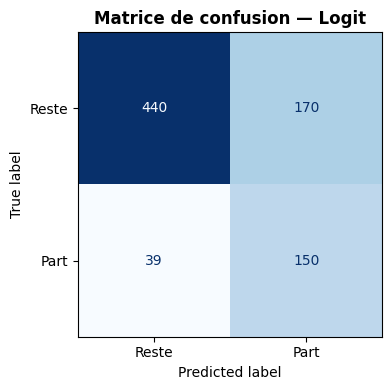

array([[440, 170],
       [ 39, 150]])

In [ ]:

CAT_COLS = [
    "anciennete_nouv",
    "department",
]

NUM_COLS = [
    "nb_voe_requested_t",
    "nb_indiscipline",
    "nb_inspection",
    "salaire_cumule",
    "volatilite_salariale_actuelle",
    "nombre_semaines_declin",
    "perf_wage_pct_90d",
    "watchlist_score_actuel",
    "avg_compliance_pct",
]

RANDOM_STATE = 42

def entrainer_logit(df_all_drivers, num_cols, cat_cols, random_state=RANDOM_STATE):
    X = df_all_drivers[num_cols + cat_cols].copy()
    Y = df_all_drivers["Y"].copy()

    X_train, X_test, Y_train, Y_test = train_test_split(
        X, Y, test_size=0.25, random_state=random_state, stratify=Y
    )

    preprocessor = ColumnTransformer(
        [
            ("num", StandardScaler(), num_cols),
            ("cat", OneHotEncoder(drop="first", sparse_output=False, min_frequency=0.01, handle_unknown="infrequent_if_exist"), cat_cols),
        ]
    )

    X_train_enc = preprocessor.fit_transform(X_train)
    X_test_enc = preprocessor.transform(X_test)

    feature_names = num_cols + list(
        preprocessor.named_transformers_["cat"].get_feature_names_out(cat_cols)
    )

    X_train_enc = pd.DataFrame(X_train_enc, columns=feature_names)
    X_test_enc = pd.DataFrame(X_test_enc, columns=feature_names)

    X_train_sm = sm.add_constant(X_train_enc)
    X_test_sm = sm.add_constant(X_test_enc, has_constant="add")

    Y_train_r = Y_train.reset_index(drop=True)

    # Pondération manuelle (statsmodels Logit n'a pas de class_weight natif) :
    # on repondère chaque classe pour équilibrer sa contribution à la vraisemblance,
    # même logique que class_weight="balanced" de sklearn.
    n_pos = (Y_train_r == 1).sum()
    n_neg = (Y_train_r == 0).sum()
    poids = Y_train_r.map({0: 1.0, 1: n_neg / n_pos})

    # GLM Binomial + freq_weights = equivalent pondéré du Logit (mêmes coefficients/OR/p-values,
    # à l'approximation près de la variance liée aux poids non-entiers)
    logit_model = sm.GLM(
        Y_train_r, X_train_sm,
        family=sm.families.Binomial(),
        freq_weights=poids
    ).fit()
    print(logit_model.summary())

    odds_ratios = pd.DataFrame({
        "OR": np.exp(logit_model.params),
        "p_value": logit_model.pvalues,
    }).sort_values("OR", ascending=False)

    print("\n--- Odds Ratios ---")
    print(odds_ratios)

    pred_logit = logit_model.predict(X_test_sm)
    auc_logit = roc_auc_score(Y_test, pred_logit)
    ll_logit = log_loss(Y_test, pred_logit)
    print(f"\nAUC-ROC = {auc_logit:.3f} | LogLoss = {ll_logit:.3f}")

    return logit_model, odds_ratios, Y_test, pred_logit

# 1. On appelle la fonction en récupérant toutes les variables nécessaires
logit_model, odds_ratios, Y_test, pred_logit = entrainer_logit(all_drivers1, NUM_COLS, CAT_COLS)

# 2. Choisir un seuil (ex: capacite RH, ou 0.5, ou Youden)
seuil = optimiser_seuil_capacite("Logit", Y_test, pred_logit, capacite_pct=0.4)

# 3. Transformer les probabilites en classes predites (0/1) a ce seuil
y_pred_seuil = (pred_logit >= seuil).astype(int)

# 4. Afficher la matrice
plot_confusion_matrix("Logit", Y_test, y_pred_seuil, labels=('Reste', 'Part'))

                 Generalized Linear Model Regression Results                  
Dep. Variable:                      Y   No. Observations:                 2397
Model:                            GLM   Df Residuals:                  3611.00
Model Family:                Binomial   Df Model:                           44
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -1712.0
Date:                Tue, 28 Jul 2026   Deviance:                       3424.0
Time:                        17:42:42   Pearson chi2:                 3.43e+03
No. Iterations:                    20   Pseudo R-squ. (CS):             0.4964
Covariance Type:            nonrobust                                         
                                         coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------------------
cons

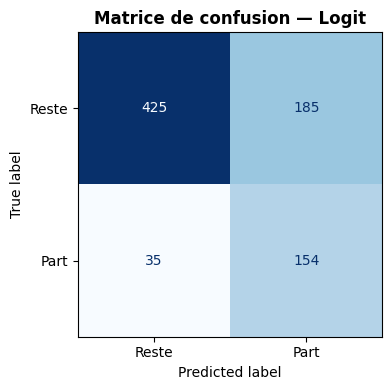

array([[425, 185],
       [ 35, 154]])

In [ ]:
CAT_COLS = [
    "anciennete_nouv",
    "department",
]

NUM_COLS = [
    "nb_voe_requested_t",
    "nb_indiscipline",
    "nb_inspection",
    "salaire_cumule",
    "volatilite_salariale_actuelle",
    "nombre_semaines_declin",
    "perf_wage_pct_90d",
    "watchlist_score_actuel",
    "avg_compliance_pct",
]

RANDOM_STATE = 42

def optimiser_seuil_train(y_true_train, y_proba_train, capacite_pct=0.4):
    """Optimise le seuil UNIQUEMENT sur le train."""
    y_proba_train = np.asarray(y_proba_train)
    if capacite_pct is not None:
        return float(np.quantile(y_proba_train, 1 - capacite_pct))
    # fallback F1 si pas de capacité
    from sklearn.metrics import f1_score
    seuils = np.unique(np.quantile(y_proba_train, np.linspace(0.01, 0.99, 99)))
    best_seuil, best_score = 0.5, -np.inf
    for s in seuils:
        score = f1_score(y_true_train, (y_proba_train >= s).astype(int), zero_division=0)
        if score > best_score:
            best_score, best_seuil = score, s
    return float(best_seuil)


def entrainer_logit(df_all_drivers, num_cols, cat_cols, random_state=RANDOM_STATE):
    X = df_all_drivers[num_cols + cat_cols].copy()
    Y = df_all_drivers["Y"].copy()

    X_train, X_test, Y_train, Y_test = train_test_split(
        X, Y, test_size=0.25, random_state=random_state, stratify=Y
    )

    preprocessor = ColumnTransformer(
        [
            ("num", StandardScaler(), num_cols),
            ("cat", OneHotEncoder(
                drop="first",
                sparse_output=False,
                min_frequency=0.01,
                handle_unknown="infrequent_if_exist"
            ), cat_cols),
        ]
    )

    X_train_enc = preprocessor.fit_transform(X_train)
    X_test_enc = preprocessor.transform(X_test)

    feature_names = num_cols + list(
        preprocessor.named_transformers_["cat"].get_feature_names_out(cat_cols)
    )

    X_train_enc = pd.DataFrame(X_train_enc, columns=feature_names)
    X_test_enc = pd.DataFrame(X_test_enc, columns=feature_names)

    X_train_sm = sm.add_constant(X_train_enc)
    X_test_sm = sm.add_constant(X_test_enc, has_constant="add")

    Y_train_r = Y_train.reset_index(drop=True)

    n_pos = (Y_train_r == 1).sum()
    n_neg = (Y_train_r == 0).sum()
    poids = Y_train_r.map({0: 1.0, 1: n_neg / n_pos})

    logit_model = sm.GLM(
        Y_train_r, X_train_sm,
        family=sm.families.Binomial(),
        freq_weights=poids
    ).fit()
    print(logit_model.summary())

    odds_ratios = pd.DataFrame({
        "OR": np.exp(logit_model.params),
        "p_value": logit_model.pvalues,
    }).sort_values("OR", ascending=False)

    print("\n--- Odds Ratios ---")
    print(odds_ratios)

    # Probabilités train + test
    pred_train = logit_model.predict(X_train_sm)
    pred_test = logit_model.predict(X_test_sm)

    auc_logit = roc_auc_score(Y_test, pred_test)
    ll_logit = log_loss(Y_test, pred_test)
    print(f"\nAUC-ROC (test) = {auc_logit:.3f} | LogLoss (test) = {ll_logit:.3f}")

    return logit_model, odds_ratios, Y_train, pred_train, Y_test, pred_test


# 1. Entraînement
logit_model, odds_ratios, Y_train, pred_train, Y_test, pred_test = entrainer_logit(
    all_drivers1, NUM_COLS, CAT_COLS
)

# 2. Seuil optimisé sur le TRAIN uniquement
seuil = optimiser_seuil_train(Y_train, pred_train, capacite_pct=0.4)
print(f"\nSeuil optimisé sur le train : {seuil:.4f}")

# 3. Appliquer ce seuil une seule fois sur le TEST
y_pred_seuil = (pred_test >= seuil).astype(int)

# 4. Matrice de confusion sur le TEST
plot_confusion_matrix("Logit", Y_test, y_pred_seuil, labels=('Reste', 'Part'))

### Synthèse des résultats du modèle

Le modèle de régression logistique met en évidence plusieurs facteurs significativement associés au risque de départ des employés. Parmi les variables quantitatives, le nombre de demandes de vérification d'emploi (`nb_voe_requested_t`), le nombre d'inspections (`nb_inspection`) et le kilométrage hebdomadaire moyen (`avg_weekly_miles_actuel`) augmentent significativement le risque d'attrition. À l'inverse, le score *Watchlist*, le salaire cumulé, le nombre d'indisciplines ainsi qu'une ancienneté plus élevée sont associés à une diminution du risque de départ.

Les résultats montrent également que le département d'appartenance influence significativement la probabilité de départ. Plusieurs départements présentent un risque d'attrition significativement plus faible que le département de référence, ce qui suggère l'existence de différences organisationnelles ou managériales entre les sites.

Sur le plan de la qualité d'ajustement, le modèle explique une part importante de la variabilité du phénomène, avec un pseudo-$R^2$ de Cox et Snell égal à **0,496**, indiquant un pouvoir explicatif satisfaisant pour un modèle logistique.

Les performances prédictives obtenues sur l'échantillon de test sont également encourageantes. Le modèle atteint un **rappel (Recall) de 79,5 %**, ce qui signifie qu'il identifie correctement près de huit employés sur dix ayant effectivement quitté l'entreprise. La **précision (Precision) de 46.9 %** indique qu'environ un employé sur deux prédit comme partant quitte effectivement l'entreprise. Enfin, le **F1-score de 0,58** traduit un compromis satisfaisant entre la précision et le rappel.

Dans l'ensemble, ces résultats montrent que le modèle possède une bonne capacité à détecter les employés à risque de départ. Il constitue ainsi un outil pertinent pour l'identification précoce des situations d'attrition, même si certains résultats contre-intuitifs (notamment concernant le nombre d'indisciplines) méritent une analyse complémentaire.

### Variables significatives

### VIF

In [ ]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

def calculer_vif(df_all_drivers, num_cols, cat_cols):
    # 1. On isole les variables explicatives (comme dans l'entraînement)
    X = df_all_drivers[num_cols + cat_cols].copy()
    
    # 2. On applique EXACTEMENT le même preprocessor (sans la cible Y)
    preprocessor = ColumnTransformer(
        [
            ("num", StandardScaler(), num_cols),
            ("cat", OneHotEncoder(drop="first", sparse_output=False, min_frequency=0.01, handle_unknown="infrequent_if_exist"), cat_cols),
        ]
    )
    
    X_enc = preprocessor.fit_transform(X)
    
    # Reconstruire les noms de colonnes
    feature_names = num_cols + list(
        preprocessor.named_transformers_["cat"].get_feature_names_out(cat_cols)
    )
    
    # Convertir en DataFrame et ajouter la constante (obligatoire pour le VIF)
    X_df = pd.DataFrame(X_enc, columns=feature_names)
    X_df = sm.add_constant(X_df)
    
    # 3. Calcul du VIF pour chaque feature
    vif_data = pd.DataFrame()
    vif_data["Feature"] = X_df.columns
    vif_data["VIF"] = [variance_inflation_factor(X_df.values, i) for i in range(X_df.shape[1])]
    
    # On retire la constante de l'affichage final car son VIF est toujours très élevé et normal
    vif_data = vif_data[vif_data["Feature"] != "const"].sort_values("VIF", ascending=False)
    
    print("\n--- Tableau des VIF ---")
    print(vif_data.to_string(index=False))
    
    return vif_data

# Lancement du calcul
vif_df = calculer_vif(all_drivers1, NUM_COLS, CAT_COLS)


--- Tableau des VIF ---
                           Feature       VIF
     anciennete_nouv_[366j a 5ans] 12.397482
         anciennete_nouv_[31-365j]  9.726630
   anciennete_nouv_[Plus de 5 ans]  7.460125
                    salaire_cumule  5.625831
                 perf_wage_pct_90d  3.418201
                  department_96164  2.741589
                  department_96424  2.595803
            nombre_semaines_declin  2.531915
                  department_96914  2.442603
                  department_96474  2.418292
                  department_96124  2.405120
                  department_96804  2.385033
                  department_96604  2.342107
     department_infrequent_sklearn  2.342045
                  department_96414  2.319038
                  department_96464  2.315144
                  department_96934  2.269192
                  department_96434  2.243284
                  department_96494  2.194759
                  department_96524  2.189385
                  department_9

In [ ]:
# Tableau des coefficients
resultats = pd.DataFrame({
    "Variable": logit_model.params.index,
    "Coefficient": logit_model.params.values,
    "Odds Ratio (OR)": np.exp(logit_model.params.values),
    "p-value": logit_model.pvalues.values
})

# Suppression de la constante
resultats = resultats[resultats["Variable"] != "const"]

# Conservation uniquement des variables significatives (5 %)
resultats = resultats[resultats["p-value"] < 0.05]

# Séparation de la variable et de la modalité
resultats["Modalité"] = ""

for var in CAT_COLS:
    masque = resultats["Variable"].str.startswith(var + "_")
    resultats.loc[masque, "Modalité"] = (
        resultats.loc[masque, "Variable"]
        .str.replace(var + "_", "", regex=False)
    )
    resultats.loc[masque, "Variable"] = var

# Arrondis
resultats["Coefficient"] = resultats["Coefficient"].round(4)
resultats["Odds Ratio (OR)"] = resultats["Odds Ratio (OR)"].round(3)
resultats["p-value"] = resultats["p-value"].round(4)

# Tri par p-value
resultats = resultats.sort_values("p-value")

# Réorganisation des colonnes
resultats = resultats[
    ["Variable", "Modalité", "Coefficient", "Odds Ratio (OR)", "p-value"]
]

#print(resultats)

In [ ]:
# À mettre à la place de votre dernier "print(resultats)"

# On remplace les chaînes vides par un tiret pour le visuel
df_style = resultats.copy()
df_style["Modalité"] = df_style["Modalité"].replace("", "—")

from tabulate import tabulate

# On remplace les cases vides par des tirets pour que ce soit plus propre
resultats["Modalité"] = resultats["Modalité"].replace("", "—")

print("\n" + "="*90)
print(" TABLEAU DES VARIABLES ET COEFFICIENTS SIGNIFICATIFS (p < 0.05)")
print("="*90)

# Affichage sous forme de tableau "Grid" (style base de données)
print(tabulate(resultats, headers="keys", tablefmt="round", showindex=False))
print("="*90)


 TABLEAU DES VARIABLES ET COEFFICIENTS SIGNIFICATIFS (p < 0.05)
Variable                       Modalité              Coefficient    Odds Ratio (OR)    p-value
-----------------------------  ------------------  -------------  -----------------  ---------
nb_voe_requested_t             —                          0.5279              1.695     0
salaire_cumule                 —                         -0.8839              0.413     0
watchlist_score_actuel         —                         -0.6718              0.511     0
volatilite_salariale_actuelle  —                         -0.9485              0.387     0
anciennete_nouv                [31-365j]                 -1.2696              0.281     0
anciennete_nouv                [366j a 5ans]             -2.2111              0.11      0
anciennete_nouv                [Plus de 5 ans]           -2.2224              0.108     0
department                     infrequent_sklearn        -1.2824              0.277     0.0003
department          

### Commentaire des résultats du modèle de régression logistique

Le tableau présente les coefficients, les odds ratios (OR) et les *p-values* des variables statistiquement significatives au seuil de 5 % dans le modèle logistique. L'odds ratio mesure le facteur multiplicatif appliqué aux *odds* de départ (Y = 1) pour une augmentation d'un écart-type (variables numériques standardisées) ou pour l'appartenance à une modalité donnée par rapport à la catégorie de référence (variables catégorielles). Un OR inférieur à 1 traduit un effet protecteur, tandis qu'un OR supérieur à 1 indique une augmentation du risque de départ.

### Variables numériques

**`nb_voe_requested_t`** (OR = 1,695 ; *p* < 0,001) : Une augmentation d'un écart-type du nombre de demandes de vérification d'emploi (VOE) est associée à une augmentation de **69,5 %** des *odds* de départ. Cette variable constitue le principal facteur de risque mis en évidence par le modèle.

**`salaire_cumule`** (OR = 0,413 ; *p* < 0,001) : Une augmentation d'un écart-type du salaire cumulé est associée à une réduction de **58,7 %** des *odds* de départ, indiquant qu'une rémunération cumulée plus élevée favorise la rétention des employés.

**`watchlist_score_actuel`** (OR = 0,511 ; *p* < 0,001) : Une augmentation d'un écart-type du score *Watchlist* est associée à une réduction de **48,9 %** des *odds* de départ, traduisant un effet protecteur significatif.

**`volatilite_salariale_actuelle`** (OR = 0,387 ; *p* < 0,001) : Une augmentation d'un écart-type de la volatilité salariale actuelle est associée à une réduction de **61,3 %** des *odds* de départ. Bien que statistiquement significatif, ce résultat demeure contre-intuitif et devra être interprété avec prudence.

**`nb_inspection`** (OR = 1,148 ; *p* = 0,014) : Une augmentation d'un écart-type du nombre d'inspections est associée à une augmentation de **14,8 %** des *odds* de départ, traduisant un effet positif modéré sur le risque d'attrition.

**`nb_indiscipline`** (OR = 0,884 ; *p* = 0,019) : Une augmentation d'un écart-type du nombre d'indisciplines est associée à une réduction de **11,6 %** des *odds* de départ. Bien que statistiquement significatif, ce résultat demeure contre-intuitif et devra être interprété avec prudence.

### Ancienneté (`anciennete_nouv`)

Par rapport à la catégorie de référence (**0–30 jours**), les trois autres modalités présentent un effet protecteur qui s'accentue avec l'ancienneté.

| Modalité | OR | Réduction des *odds* |
|:---|---:|---:|
| 31–365 jours | 0,281 | 71,9 % |
| 366 jours à 5 ans | 0,110 | 89,0 % |
| Plus de 5 ans | 0,108 | 89,2 % |

Ces résultats montrent que le risque de départ est particulièrement élevé au cours du premier mois suivant l'embauche, puis diminue fortement avec l'ancienneté.

### Département

Trois modalités de la variable **`department`** présentent un effet protecteur significatif par rapport à la catégorie de référence. Les *odds ratios* varient entre **0,277** (modalité **infrequent_sklearn**) et **0,416** (département **96424**), correspondant à une réduction des *odds* de départ comprise entre **58,4 %** et **72,3 %**. Le département **96574** présente également un effet protecteur (OR = 0,337), soit une réduction de **66,3 %** des *odds* de départ. Ces résultats mettent en évidence une hétérogénéité du risque d'attrition entre les départements, suggérant que des facteurs organisationnels ou managériaux propres à certains départements peuvent influencer la probabilité de départ des employés.

### Random Forest

#### Recherche des meilleurs parametres

In [ ]:
import optuna
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score

def optimiser_rf_optuna(df_all_drivers, num_cols, cat_cols, n_trials=30, random_state=RANDOM_STATE):
    # 1. Traitement des données
    X = df_all_drivers[num_cols + cat_cols].copy()
    Y = df_all_drivers["Y"].copy()

    X_train, X_test, Y_train, Y_test = train_test_split(
        X, Y, test_size=0.25, random_state=random_state, stratify=Y
    )

    preprocessor = ColumnTransformer(
        [
            ("num", StandardScaler(), num_cols),
            ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False, min_frequency=0.01), cat_cols),
        ]
    )

    X_train_enc = preprocessor.fit_transform(X_train)

    # 2. Fonction objectif Optuna pour Random Forest
    def objective(trial):
        params = {
            "n_estimators": trial.suggest_int("n_estimators", 100, 800, step=100),
            "max_depth": trial.suggest_int("max_depth", 4, 15),
            "min_samples_split": trial.suggest_int("min_samples_split", 2, 20),
            "min_samples_leaf": trial.suggest_int("min_samples_leaf", 5, 50),
            "max_features": trial.suggest_float("max_features", 0.3, 1.0),
            "class_weight": "balanced",
            "random_state": random_state,
            "n_jobs": -1
        }

        clf = RandomForestClassifier(**params)
        
        score = cross_val_score(clf, X_train_enc, Y_train, cv=3, scoring="roc_auc").mean()
        return score

    # 3. Lancement d'Optuna
    optuna.logging.set_verbosity(optuna.logging.WARNING)
    study = optuna.create_study(direction="maximize")
    study.optimize(objective, n_trials=n_trials)

    print("--- Meilleurs hyperparamètres Random Forest ---")
    print(study.best_params)
    
    return study.best_params

meilleurs_params_rf = optimiser_rf_optuna(all_drivers1, NUM_COLS, CAT_COLS, n_trials=30)

--- Meilleurs hyperparamètres Random Forest ---
{'n_estimators': 700, 'max_depth': 15, 'min_samples_split': 9, 'min_samples_leaf': 5, 'max_features': 0.9479010634048293}



--- Performances du Random Forest ---
AUC-ROC = 0.886 | LogLoss = 0.357


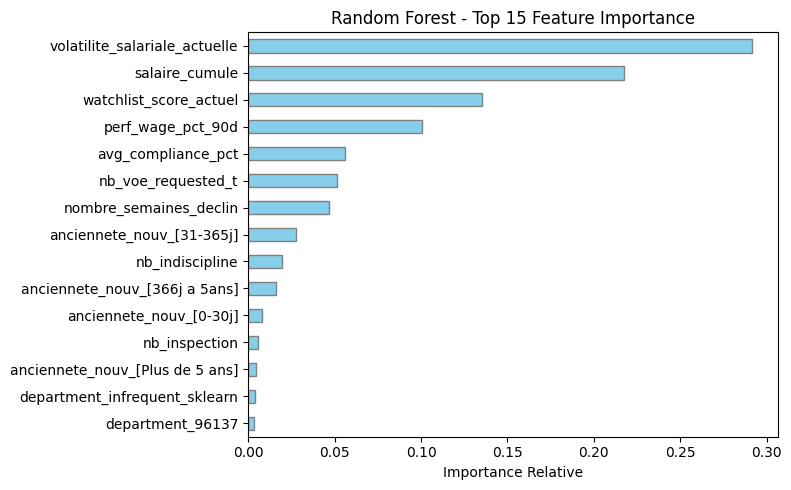


Modèle : Random Forest
Capacité RH : 20%
Seuil retenu : 0.5741
Employés à suivre : 160/799 (20.0%)
Recall    : 0.624
Precision : 0.738
F1-score  : 0.676


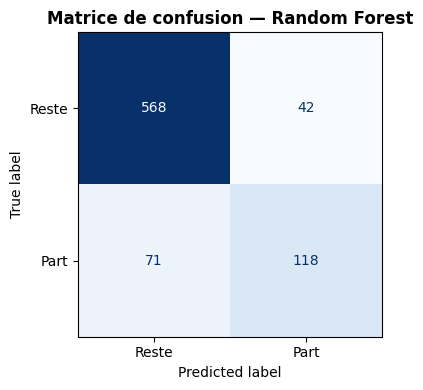

array([[568,  42],
       [ 71, 118]])

In [ ]:
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier

def entrainer_rf(df_all_drivers, num_cols, cat_cols, random_state=RANDOM_STATE):
    # 1. On sépare les données (X, Y)
    X = df_all_drivers[num_cols + cat_cols].copy()
    Y = df_all_drivers["Y"].copy()

    X_train, X_test, Y_train, Y_test = train_test_split(
        X, Y, test_size=0.25, random_state=random_state, stratify=Y
    )

    # 2. Pipeline adapté (Pour le RF, pas besoin de drop="first", handle_unknown="ignore" redevient possible !)
    preprocessor_rf = ColumnTransformer(
        [
            ("num", StandardScaler(), num_cols),
            ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False, min_frequency=0.01), cat_cols),
        ]
    )

    # Encodage des matrices
    X_train_enc = preprocessor_rf.fit_transform(X_train)
    X_test_enc = preprocessor_rf.transform(X_test)

    # Récupération propre des noms de features
    feature_names = num_cols + list(
        preprocessor_rf.named_transformers_["cat"].get_feature_names_out(cat_cols)
    )


    rf_model = RandomForestClassifier(
    **meilleurs_params_rf,
    class_weight="balanced",
    random_state=random_state,
    n_jobs=-1
)
    
    rf_model.fit(X_train_enc, Y_train)

    # 4. Prédictions et Évaluation
    pred_rf = rf_model.predict_proba(X_test_enc)[:, 1]
    auc_rf = roc_auc_score(Y_test, pred_rf)
    ll_rf = log_loss(Y_test, pred_rf)
    
    print("\n--- Performances du Random Forest ---")
    print(f"AUC-ROC = {auc_rf:.3f} | LogLoss = {ll_rf:.3f}")

    # 5. Extraction et Graphique des Importances de Variables
    top_n = 15
    importances = pd.Series(rf_model.feature_importances_, index=feature_names).sort_values(ascending=False).head(top_n)
    
    plt.figure(figsize=(8, 5))
    importances.sort_values().plot(kind="barh", color="skyblue", edgecolor="gray")
    plt.title(f"Random Forest - Top {top_n} Feature Importance")
    plt.xlabel("Importance Relative")
    plt.tight_layout()
    plt.show()

    return rf_model, importances, Y_test, pred_rf

# Lancement du modèle
rf_model, rf_importances, Y_test, pred_rf = entrainer_rf(all_drivers1, NUM_COLS, CAT_COLS)

# 2. Choisir un seuil (ex: capacite RH, ou 0.5, ou Youden)
seuil = optimiser_seuil_capacite("Random Forest", Y_test, pred_rf, capacite_pct=0.2)

# 3. Transformer les probabilites en classes predites (0/1) a ce seuil
y_pred_seuil = (pred_rf >= seuil).astype(int)

# 4. Afficher la matrice
plot_confusion_matrix("Random Forest", Y_test, y_pred_seuil, labels=('Reste', 'Part'))

### Modèle XGBoost

#### Recherche des meilleurs parametres

In [ ]:
import optuna
import xgboost as xgb
from sklearn.model_selection import cross_val_score

def optimiser_xgb_optuna(df_all_drivers, num_cols, cat_cols, n_trials=30, random_state=RANDOM_STATE):
    # 1. Préparation et encodage des données
    X = df_all_drivers[num_cols + cat_cols].copy()
    Y = df_all_drivers["Y"].copy()

    X_train, X_test, Y_train, Y_test = train_test_split(
        X, Y, test_size=0.25, random_state=random_state, stratify=Y
    )

    preprocessor = ColumnTransformer(
        [
            ("num", StandardScaler(), num_cols),
            ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False, min_frequency=0.01), cat_cols),
        ]
    )

    X_train_enc = preprocessor.fit_transform(X_train)
    raw_feature_names = num_cols + list(preprocessor.named_transformers_["cat"].get_feature_names_out(cat_cols))
    feature_names = [re.sub(r'[\[\]<>\s]', '_', name) for name in raw_feature_names]
    
    X_train_enc_df = pd.DataFrame(X_train_enc, columns=feature_names)

    # 2. Calcul du scale_pos_weight
    scale_pos_weight_val = (Y_train == 0).sum() / (Y_train == 1).sum()

    # 3. Fonction objectif pour Optuna
    def objective(trial):
        params = {
            "n_estimators": trial.suggest_int("n_estimators", 100, 800, step=100),
            "max_depth": trial.suggest_int("max_depth", 2, 8),
            "learning_rate": trial.suggest_float("learning_rate", 0.005, 0.1, log=True),
            "subsample": trial.suggest_float("subsample", 0.6, 1.0),
            "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
            "scale_pos_weight": scale_pos_weight_val,
            "eval_metric": "logloss",
            "random_state": random_state
        }

        clf = xgb.XGBClassifier(**params)
        
        # On évalue avec une Cross-Validation (ex: AUC-ROC)
        score = cross_val_score(clf, X_train_enc_df, Y_train, cv=3, scoring="roc_auc").mean()
        return score

    # 4. Lancement de la recherche
    optuna.logging.set_verbosity(optuna.logging.WARNING) 
    study = optuna.create_study(direction="maximize")
    study.optimize(objective, n_trials=n_trials)

    print("Meilleurs hyperparamètres trouvés :")
    print(study.best_params)
    
    return study.best_params

meilleurs_params = optimiser_xgb_optuna(all_drivers1, NUM_COLS, CAT_COLS, n_trials=50)

Recherche des meilleurs hyperparamètres avec Optuna
Meilleurs hyperparamètres trouvés :
{'n_estimators': 700, 'max_depth': 8, 'learning_rate': 0.007392549945573628, 'subsample': 0.620253390584947, 'colsample_bytree': 0.9246426414572534}



--- Performances de XGBoost ---
AUC-ROC = 0.891 | LogLoss = 0.355

--- Calcul des valeurs SHAP ---


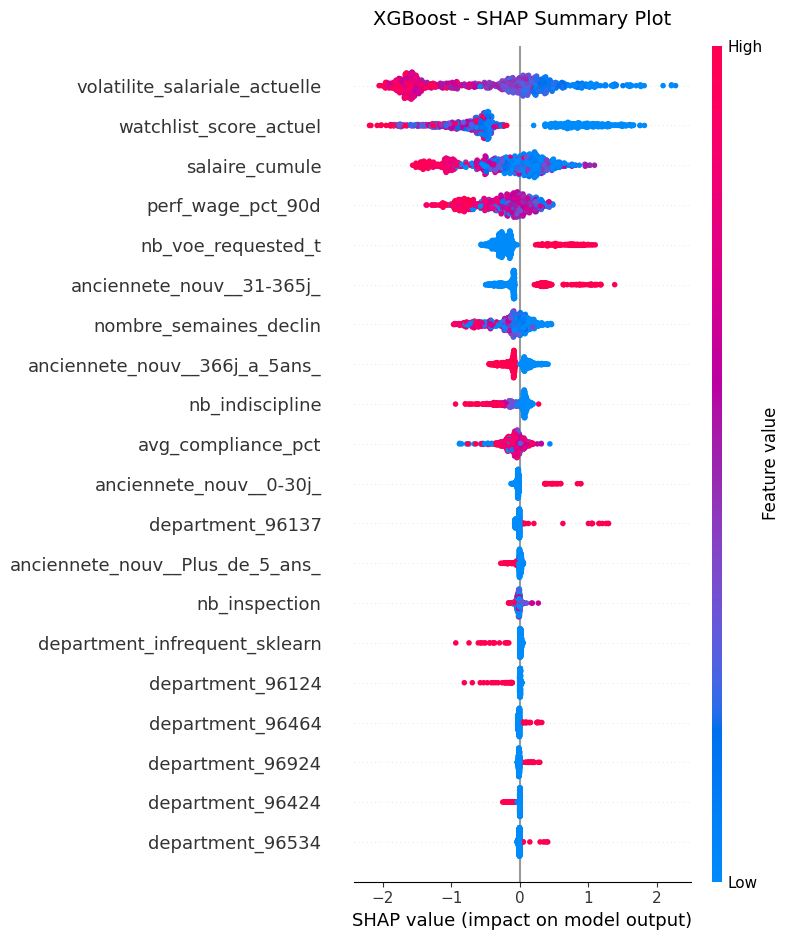


Modèle : XGBoost
Capacité RH : 40%
Seuil retenu : 0.3281
Employés à suivre : 320/799 (40.1%)
Recall    : 0.852
Precision : 0.503
F1-score  : 0.633


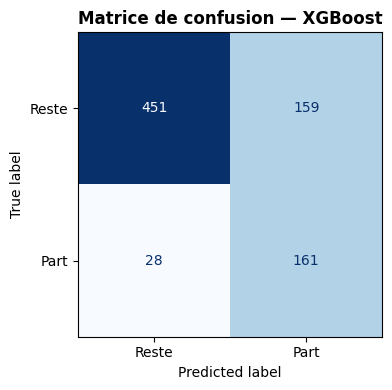

array([[451, 159],
       [ 28, 161]])

In [ ]:
import xgboost as xgb
import shap
import matplotlib.pyplot as plt
import re

def entrainer_xgb(df_all_drivers, num_cols, cat_cols, random_state=RANDOM_STATE):
    X = df_all_drivers[num_cols + cat_cols].copy()
    Y = df_all_drivers["Y"].copy()

    X_train, X_test, Y_train, Y_test = train_test_split(
        X, Y, test_size=0.25, random_state=random_state, stratify=Y
    )

    # 2. Pipeline d'encodage
    preprocessor_xgb = ColumnTransformer(
        [
            ("num", StandardScaler(), num_cols),
            ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False, min_frequency=0.01), cat_cols),
        ]
    )

    X_train_enc = preprocessor_xgb.fit_transform(X_train)
    X_test_enc = preprocessor_xgb.transform(X_test)

    # Récupération brute des noms de features
    raw_feature_names = num_cols + list(
        preprocessor_xgb.named_transformers_["cat"].get_feature_names_out(cat_cols)
    )

    feature_names = [re.sub(r'[\[\]<>\s]', '_', name) for name in raw_feature_names]

    # Convertir en DataFrames nommés avec les colonnes propres
    X_train_enc_df = pd.DataFrame(X_train_enc, columns=feature_names)
    X_test_enc_df = pd.DataFrame(X_test_enc, columns=feature_names)

    # 3. Définition et entraînement de XGBoost

    scale_pos_weight = (Y_train == 0).sum() / (Y_train == 1).sum()  

    xgb_clf = xgb.XGBClassifier(
    **meilleurs_params,
    scale_pos_weight=scale_pos_weight,
    eval_metric="logloss",
    random_state=random_state
   )
    
    xgb_clf.fit(X_train_enc_df, Y_train)

    # 4. Évaluation
    pred_xgb = xgb_clf.predict_proba(X_test_enc_df)[:, 1]
    auc_xgb = roc_auc_score(Y_test, pred_xgb)
    ll_xgb = log_loss(Y_test, pred_xgb)
    
    print("\n--- Performances de XGBoost ---")
    print(f"AUC-ROC = {auc_xgb:.3f} | LogLoss = {ll_xgb:.3f}")

    # 5. Interprétation SHAP
    print("\n--- Calcul des valeurs SHAP ---")
    explainer_xgb = shap.TreeExplainer(xgb_clf)
    shap_values_xgb = explainer_xgb(X_test_enc_df)

    # Affichage du summary plot
    plt.figure(figsize=(10, 6))
    shap.summary_plot(shap_values_xgb, X_test_enc_df, show=False)
    plt.title("XGBoost - SHAP Summary Plot", fontsize=14, pad=15)
    plt.tight_layout()
    plt.show()

    return xgb_clf, shap_values_xgb, Y_test, pred_xgb

# Lancement du modèle XGBoost + SHAP
xgb_clf, shap_values, Y_test, pred_xgb = entrainer_xgb(all_drivers1, NUM_COLS, CAT_COLS)

# 2. Choisir un seuil (ex: capacite RH, ou 0.5, ou Youden)
seuil = optimiser_seuil_capacite("XGBoost", Y_test, pred_xgb, capacite_pct=0.4)

# 3. Transformer les probabilites en classes predites (0/1) a ce seuil
y_pred_seuil = (pred_xgb >= seuil).astype(int)

# 4. Afficher la matrice
plot_confusion_matrix("XGBoost", Y_test, y_pred_seuil, labels=('Reste', 'Part'))

### Résultats du modèle XGBoost

#### Performances du modèle

Le modèle XGBoost présente de bonnes performances de classification. L'aire sous la courbe ROC (**AUC = 0,891**) indique une excellente capacité à discriminer les employés susceptibles de quitter l'entreprise de ceux qui resteront. En effet, une valeur d'AUC proche de 1 traduit une très bonne qualité de discrimination, tandis qu'une valeur de 0,5 correspond à un modèle équivalent à un classement aléatoire.

Par ailleurs, la **LogLoss égale à 0,355** reste relativement faible, ce qui montre que les probabilités prédites par le modèle sont globalement bien calibrées. Ces résultats confirment que le modèle XGBoost fournit des prédictions fiables pour l'identification des employés à risque d'attrition.

#### Importance des variables (SHAP)

#### Principe de lecture

Le graphique SHAP (*SHapley Additive exPlanations*) présente, pour chaque variable du modèle, la distribution des contributions individuelles à la prédiction sur l'ensemble de test. Chaque point représente un employé ; sa position horizontale indique l'ampleur et le sens de l'effet de la variable sur la probabilité prédite de départ (valeur SHAP positive = effet augmentant la probabilité prédite de départ ; valeur SHAP négative = effet réduisant cette probabilité). La couleur représente la valeur prise par la variable pour chaque observation (rouge = valeur élevée, bleu = valeur faible). Les variables sont classées par ordre décroissant d'importance globale, mesurée par la moyenne des valeurs absolues des contributions SHAP.

#### Interprétation

Les valeurs SHAP permettent d'interpréter l'influence de chaque variable sur les prédictions du modèle. Les variables sont classées selon leur importance moyenne absolue, les plus influentes apparaissant en haut de la figure.

La volatilité salariale actuelle (**`volatilite_salariale_actuelle`**) est la variable la plus importante du modèle. Des valeurs élevées (points rouges) sont principalement associées à des valeurs SHAP négatives, traduisant un effet protecteur qui réduit la probabilité prédite de départ. À l'inverse, des valeurs faibles (points bleus) contribuent davantage à accroître cette probabilité.

Le salaire cumulé (**`salaire_cumule`**) constitue également un déterminant majeur. Les valeurs élevées de cette variable sont majoritairement associées à des contributions SHAP négatives, indiquant qu'une rémunération cumulée plus importante favorise la rétention des employés. Ce résultat est cohérent avec celui obtenu par le modèle de régression logistique.

Le score **`watchlist_score_actuel`** figure parmi les variables les plus influentes. Les valeurs élevées sont principalement associées à des contributions SHAP négatives, tandis que les valeurs faibles tendent à augmenter la probabilité prédite de départ. Cette relation confirme son rôle protecteur observé dans la régression logistique.

Le nombre de demandes de vérification d'emploi (**`nb_voe_requested_t`**) exerce un effet positif marqué sur le risque de départ. Les valeurs élevées de cette variable (points rouges) sont concentrées du côté des valeurs SHAP positives, traduisant une augmentation importante de la probabilité prédite de départ et suggérant une démarche active de recherche d'opportunités professionnelles.

Les différentes modalités de l'ancienneté (**`anciennete_nouv`**) jouent également un rôle important. Les employés appartenant à la catégorie **31 à 365 jours** présentent généralement des contributions SHAP positives, indiquant un risque plus élevé de départ. En revanche, les catégories **366 jours à 5 ans** et **Plus de 5 ans** sont principalement associées à des valeurs SHAP négatives, traduisant un effet protecteur lié à une ancienneté plus importante.

La variable **`nb_inspection`** présente un effet globalement positif sur la probabilité de départ, bien que son importance soit plus modérée. Les observations présentant un nombre élevé d'inspections contribuent davantage à augmenter les prédictions du modèle.

La variable **`nb_indiscipline`** présente un effet plus nuancé. Globalement, les valeurs élevées sont davantage associées à des contributions SHAP négatives, ce qui suggère un effet protecteur. Ce résultat, également observé avec la régression logistique, demeure contre-intuitif et devra être interprété avec prudence.

Enfin, certaines modalités du **département** (**`department`**) apparaissent parmi les variables d'importance plus faible, mais contribuent néanmoins à différencier le risque de départ entre groupes d'employés. Ces résultats suggèrent l'existence d'effets organisationnels ou managériaux propres à certains départements.

Dans l'ensemble, les résultats du modèle XGBoost sont cohérents avec ceux obtenus par la régression logistique. Les deux approches identifient les mêmes déterminants majeurs de l'attrition, notamment la volatilité salariale, le salaire cumulé, le score *Watchlist*, les demandes de vérification d'emploi, les inspections et les périodes critiques d'ancienneté. Cette convergence renforce la robustesse des facteurs identifiés comme étant associés au risque de départ des employés.

### Recherche des meilleurs parametres pour le modele

In [ ]:
import optuna
import lightgbm as lgb
from sklearn.model_selection import cross_val_score

def optimiser_lgb_optuna(df_all_drivers, num_cols, cat_cols, n_trials=30, random_state=RANDOM_STATE):
    # 1. Traitement des données identiques
    X = df_all_drivers[num_cols + cat_cols].copy()
    Y = df_all_drivers["Y"].copy()

    X_train, X_test, Y_train, Y_test = train_test_split(
        X, Y, test_size=0.25, random_state=random_state, stratify=Y
    )

    preprocessor = ColumnTransformer(
        [
            ("num", StandardScaler(), num_cols),
            ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False, min_frequency=0.01), cat_cols),
        ]
    )

    X_train_enc = preprocessor.fit_transform(X_train)
    raw_feature_names = num_cols + list(preprocessor.named_transformers_["cat"].get_feature_names_out(cat_cols))
    feature_names = [re.sub(r'[\[\]<>\s]', '_', name) for name in raw_feature_names]
    
    X_train_enc_df = pd.DataFrame(X_train_enc, columns=feature_names)

    # 2. Fonction objectif Optuna pour LightGBM
    def objective(trial):
        max_depth = trial.suggest_int("max_depth", 3, 8)
        # On contraint num_leaves par rapport à max_depth
        max_leaves = 2**max_depth - 1
        num_leaves = trial.suggest_int("num_leaves", 7, min(64, max_leaves))

        params = {
            "n_estimators": trial.suggest_int("n_estimators", 100, 800, step=100),
            "max_depth": max_depth,
            "num_leaves": num_leaves,
            "learning_rate": trial.suggest_float("learning_rate", 0.005, 0.1, log=True),
            "subsample": trial.suggest_float("subsample", 0.6, 1.0),
            "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
            "min_child_samples": trial.suggest_int("min_child_samples", 10, 50),
            "is_unbalance": True,
            "random_state": random_state,
            "verbose": -1
        }

        clf = lgb.LGBMClassifier(**params)
        
        score = cross_val_score(clf, X_train_enc_df, Y_train, cv=3, scoring="roc_auc").mean()
        return score

    # 3. Lancement d'Optuna
    optuna.logging.set_verbosity(optuna.logging.WARNING)
    study = optuna.create_study(direction="maximize")
    study.optimize(objective, n_trials=n_trials)

    print("--- Meilleurs hyperparamètres LightGBM ---")
    print(study.best_params)
    
    return study.best_params
# 1. Recherche des paramètres
meilleurs_params_lgb = optimiser_lgb_optuna(all_drivers1, NUM_COLS, CAT_COLS, n_trials=30)

--- Meilleurs hyperparamètres LightGBM ---
{'max_depth': 8, 'num_leaves': 42, 'n_estimators': 700, 'learning_rate': 0.011346229053308543, 'subsample': 0.6414692492435411, 'colsample_bytree': 0.9236727882125491, 'min_child_samples': 33}


### Modele LightGBM


--- Performances de LightGBM ---
AUC-ROC = 0.898 | LogLoss = 0.354

--- Calcul des valeurs SHAP ---


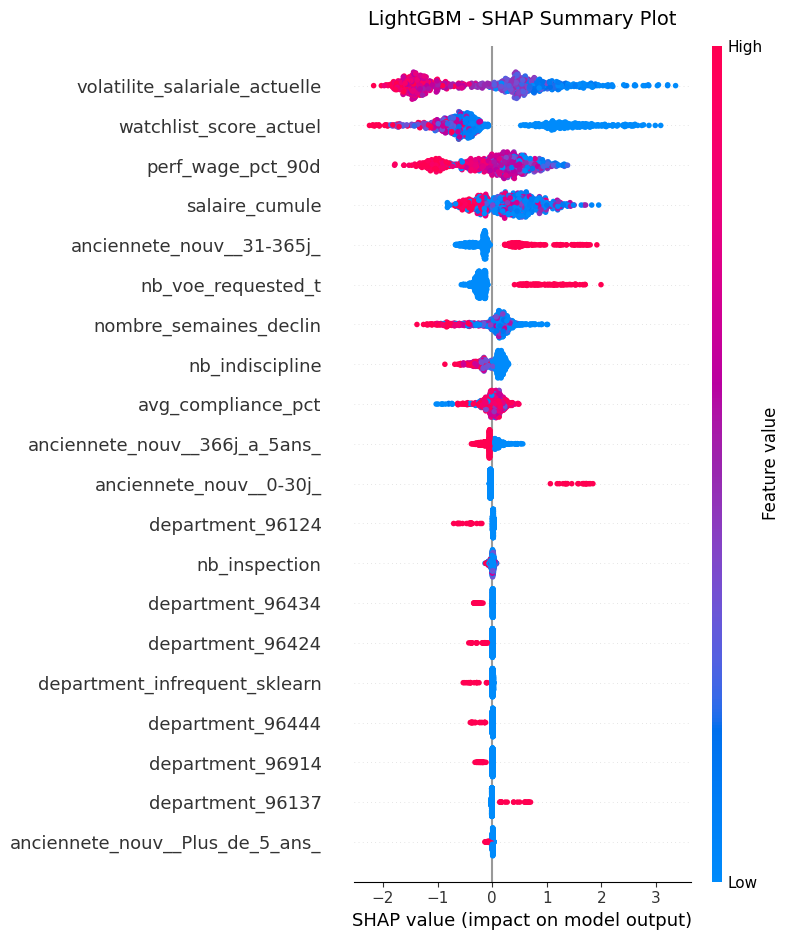


Modèle : LightGBM
Capacité RH : 20%
Seuil retenu : 0.6793
Employés à suivre : 160/799 (20.0%)
Recall    : 0.603
Precision : 0.713
F1-score  : 0.653


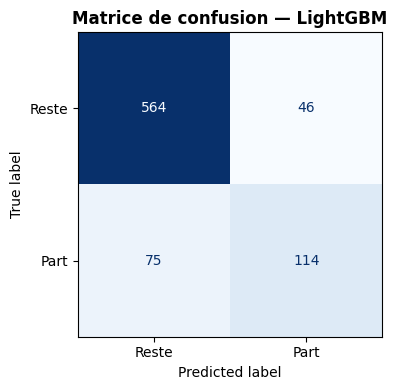

array([[564,  46],
       [ 75, 114]])

In [ ]:
import lightgbm as lgb
import shap
import matplotlib.pyplot as plt
import re

def entrainer_lgb(df_all_drivers, num_cols, cat_cols, random_state=RANDOM_STATE):
    # 1. Séparation des données
    X = df_all_drivers[num_cols + cat_cols].copy()
    Y = df_all_drivers["Y"].copy()

    X_train, X_test, Y_train, Y_test = train_test_split(
        X, Y, test_size=0.25, random_state=random_state, stratify=Y
    )

    # 2. Pipeline d'encodage (On garde le même pour comparer équitablement)
    preprocessor_lgb = ColumnTransformer(
        [
            ("num", StandardScaler(), num_cols),
            ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False, min_frequency=0.01), cat_cols),
        ]
    )

    X_train_enc = preprocessor_lgb.fit_transform(X_train)
    X_test_enc = preprocessor_lgb.transform(X_test)

    raw_feature_names = num_cols + list(
        preprocessor_lgb.named_transformers_["cat"].get_feature_names_out(cat_cols)
    )

    # Nettoyage des noms (LightGBM est plus tolérant, mais JSON/SHAP aiment la propreté)
    feature_names = [re.sub(r'[\[\]<>\s]', '_', name) for name in raw_feature_names]

    X_train_enc_df = pd.DataFrame(X_train_enc, columns=feature_names)
    X_test_enc_df = pd.DataFrame(X_test_enc, columns=feature_names)

    lgb_clf = lgb.LGBMClassifier(
    **meilleurs_params_lgb,
    is_unbalance=True,
    random_state=random_state,
    verbose=-1
    )

    lgb_clf.fit(X_train_enc_df, Y_train)

    # 4. Évaluation
    pred_lgb = lgb_clf.predict_proba(X_test_enc_df)[:, 1]
    auc_lgb = roc_auc_score(Y_test, pred_lgb)
    ll_lgb = log_loss(Y_test, pred_lgb)
    
    print("\n--- Performances de LightGBM ---")
    print(f"AUC-ROC = {auc_lgb:.3f} | LogLoss = {ll_lgb:.3f}")

    # 5. Interprétation SHAP
    print("\n--- Calcul des valeurs SHAP ---")
    explainer_lgb = shap.TreeExplainer(lgb_clf)
    shap_values_lgb = explainer_lgb(X_test_enc_df)

    # Affichage du summary plot
    plt.figure(figsize=(10, 6))
    shap.summary_plot(shap_values_lgb, X_test_enc_df, show=False)
    plt.title("LightGBM - SHAP Summary Plot", fontsize=14, pad=15)
    plt.tight_layout()
    plt.show()

    return lgb_clf, shap_values_lgb, Y_test, pred_lgb

# Appel du modèle
lgb_clf, shap_values_lgb, Y_test, pred_lgb = entrainer_lgb(all_drivers1, NUM_COLS, CAT_COLS)

# 2. Choisir un seuil (ex: capacite RH, ou 0.5, ou Youden)
seuil = optimiser_seuil_capacite("LightGBM", Y_test, pred_lgb, capacite_pct=0.2)

# 3. Transformer les probabilites en classes predites (0/1) a ce seuil
y_pred_seuil = (pred_lgb >= seuil).astype(int)

# 4. Afficher la matrice
plot_confusion_matrix("LightGBM", Y_test, y_pred_seuil, labels=('Reste', 'Part'))

### Résultats du modèle LightGBM

#### Performances du modèle

Le modèle LightGBM présente d'excellentes performances de classification. L'aire sous la courbe ROC (**AUC = 0,898**) traduit une excellente capacité à distinguer les employés susceptibles de quitter l'entreprise de ceux qui resteront. Cette valeur, très proche de 1, témoigne d'une forte capacité discriminante du modèle.

Par ailleurs, la **LogLoss de 0,354** indique une bonne qualité de calibration des probabilités prédites. Cette valeur, légèrement inférieure à celle obtenue avec le modèle XGBoost, suggère que les probabilités estimées par LightGBM sont légèrement plus précises.

#### Importance des variables (SHAP)

### Interprétation

Les valeurs SHAP permettent d'identifier les variables ayant la plus forte influence sur les prédictions du modèle.

La **volatilité salariale actuelle (`volatilite_salariale_actuelle`)** apparaît comme la variable la plus importante. Les valeurs élevées de cette variable (points rouges) sont principalement associées à des valeurs SHAP négatives, traduisant un effet protecteur réduisant la probabilité prédite de départ. À l'inverse, les faibles valeurs (points bleus) tendent à accroître cette probabilité.

Le **score Watchlist (`watchlist_score_actuel`)** constitue le deuxième déterminant majeur. Les valeurs élevées sont majoritairement associées à des contributions SHAP négatives, indiquant une diminution du risque de départ, tandis que les valeurs faibles contribuent davantage à augmenter la probabilité prédite d'attrition.

Le **pourcentage de salaire à la performance (`perf_wage_pct_90d`)** figure également parmi les variables les plus influentes. Les valeurs élevées sont principalement associées à des valeurs SHAP négatives, ce qui suggère qu'une part plus importante de rémunération liée à la performance exerce un effet protecteur vis-à-vis du départ.

Le **salaire cumulé (`salaire_cumule`)** confirme également son rôle protecteur. Les valeurs élevées de cette variable sont globalement associées à des contributions SHAP négatives, indiquant une diminution de la probabilité prédite de départ. Ce résultat est cohérent avec ceux obtenus par la régression logistique et le modèle XGBoost.

L'**ancienneté comprise entre 31 et 365 jours** (`anciennete_nouv__31-365j_`) constitue un facteur important d'attrition. Les employés appartenant à cette catégorie présentent des valeurs SHAP positives, traduisant un risque plus élevé de départ durant cette période. À l'inverse, la modalité **366 jours à 5 ans** (`anciennete_nouv__366j_a_5ans_`) est davantage associée à des valeurs SHAP négatives, mettant en évidence un effet protecteur lié à une ancienneté plus importante.

Le **nombre de demandes de vérification d'emploi (`nb_voe_requested_t`)** exerce un effet positif marqué sur la probabilité de départ. Les valeurs élevées de cette variable sont principalement associées à des contributions SHAP positives, confirmant qu'une activité importante de vérification d'emploi constitue un indicateur de risque d'attrition.

Les variables **`nombre_semaines_declin`**, **`nb_indiscipline`** et **`avg_compliance_pct`** contribuent également aux prédictions, bien que leur influence soit plus modérée. Les résultats concernant **`nb_indiscipline`** suggèrent un effet globalement protecteur, qui devra néanmoins être interprété avec prudence compte tenu de son caractère contre-intuitif.

Enfin, plusieurs modalités des variables **ancienneté** et **département** apparaissent parmi les variables importantes, traduisant l'existence d'effets spécifiques liés aux caractéristiques des employés et à leur environnement organisationnel.

Dans l'ensemble, le modèle LightGBM confirme les principaux déterminants de l'attrition identifiés par les modèles précédents. Les variables liées à la volatilité salariale, au score *Watchlist*, à la rémunération, aux demandes de vérification d'emploi et aux périodes critiques d'ancienneté demeurent les facteurs les plus influents. La forte cohérence observée entre les modèles de régression logistique, XGBoost et LightGBM renforce la robustesse des résultats obtenus.

### Modele Neural Network


--- Performances du MLP (Réseau de neurones) ---
AUC-ROC = 0.827 | LogLoss = 1.593


100%|██████████| 100/100 [00:01<00:00, 81.14it/s]


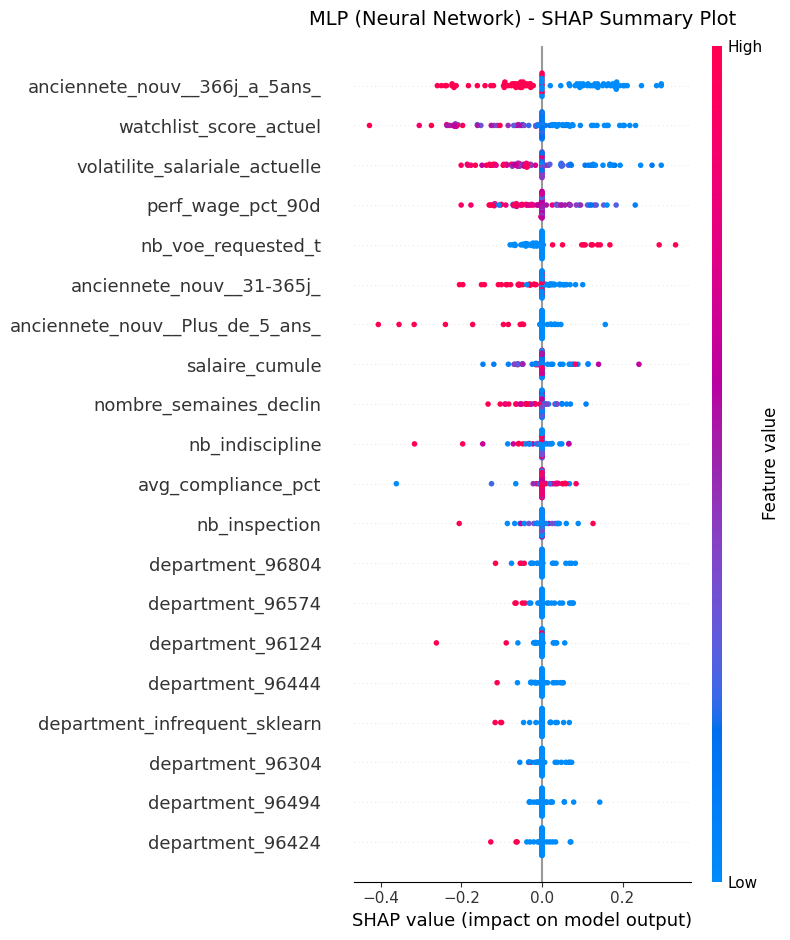


Modèle : MLP
Capacité RH : 20%
Seuil retenu : 0.5062
Employés à suivre : 160/799 (20.0%)
Recall    : 0.508
Precision : 0.600
F1-score  : 0.550


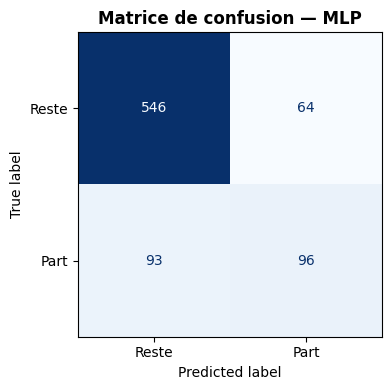

array([[546,  64],
       [ 93,  96]])

In [ ]:
from sklearn.neural_network import MLPClassifier
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
import shap
import matplotlib.pyplot as plt
import re

def entrainer_mlp(df_all_drivers, num_cols, cat_cols, random_state=RANDOM_STATE):
    # 1. Préparation des listes de colonnes
    cols_imputer = ['salaire_moyen', 'volatilite_salaire_pct']
    
    num_cols_clean = [c for c in num_cols if c not in cols_imputer]
    
    X = df_all_drivers[num_cols + cat_cols].copy()
    Y = df_all_drivers["Y"].copy()

    # Gestion de la Watchlist
    if 'watchlist_score' in X.columns:
        X['watchlist_score_missing'] = X['watchlist_score'].isna().astype(int)
        X['watchlist_score'] = X['watchlist_score'].fillna(0)
        num_cols.append('watchlist_score_missing')

    X_train, X_test, Y_train, Y_test = train_test_split(
        X, Y, test_size=0.25, random_state=random_state, stratify=Y
    )

    pipeline_impute_num = Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler())
    ])

    preprocessor_mlp = ColumnTransformer(
        [
            ("num_clean", StandardScaler(), num_cols_clean),
            ("num_impute", pipeline_impute_num, [c for c in cols_imputer if c in X.columns]),
            ("cat", OneHotEncoder(drop="first", sparse_output=False, min_frequency=0.01, handle_unknown="infrequent_if_exist"), cat_cols),
        ]
    )

    X_train_enc = preprocessor_mlp.fit_transform(X_train)
    X_test_enc = preprocessor_mlp.transform(X_test)

    raw_feature_names = (
        num_cols_clean + 
        [c for c in cols_imputer if c in X.columns] + 
        list(preprocessor_mlp.named_transformers_["cat"].get_feature_names_out(cat_cols))
    )
    feature_names = [re.sub(r'[\[\]<>\s]', '_', name) for name in raw_feature_names]

    X_train_enc_df = pd.DataFrame(X_train_enc, columns=feature_names)
    X_test_enc_df = pd.DataFrame(X_test_enc, columns=feature_names)

    # 4. Entraînement du MLP
    mlp_model = MLPClassifier(
        hidden_layer_sizes=(32, 16), 
        activation="relu", 
        alpha=1e-3,
        max_iter=500, 
        random_state=random_state
    )
    mlp_model.fit(X_train_enc_df.values, Y_train)


    pred_mlp = mlp_model.predict_proba(X_test_enc_df.values)[:, 1]
    auc_mlp = roc_auc_score(Y_test, pred_mlp)
    ll_mlp = log_loss(Y_test, pred_mlp)
    
    print("\n--- Performances du MLP (Réseau de neurones) ---")
    print(f"AUC-ROC = {auc_mlp:.3f} | LogLoss = {ll_mlp:.3f}")


    background = shap.sample(X_train_enc_df, 100, random_state=random_state)
    
   
    def predict_proba_classe_1(x):
        return mlp_model.predict_proba(x)[:, 1]


    explainer_mlp = shap.KernelExplainer(predict_proba_classe_1, background)
    
    X_test_sample = X_test_enc_df.head(100)
    
    shap_values_mlp = explainer_mlp.shap_values(X_test_sample, nsamples=100)

    # Affichage du graphique SHAP
    plt.figure(figsize=(10, 6))
    shap.summary_plot(shap_values_mlp, X_test_sample, show=False)
    plt.title("MLP (Neural Network) - SHAP Summary Plot", fontsize=14, pad=15)
    plt.tight_layout()
    plt.show()

    return mlp_model, shap_values_mlp, Y_test, pred_mlp

mlp_model, shap_values_mlp, Y_test, pred_mlp = entrainer_mlp(all_drivers1, NUM_COLS, CAT_COLS)

# 2. Choisir un seuil (ex: capacite RH, ou 0.5, ou Youden)
seuil = optimiser_seuil_capacite("MLP", Y_test, pred_mlp, capacite_pct=0.20)

# 3. Transformer les probabilites en classes predites (0/1) a ce seuil
y_pred_seuil = (pred_mlp >= seuil).astype(int)

# 4. Afficher la matrice
plot_confusion_matrix("MLP", Y_test, y_pred_seuil, labels=('Reste', 'Part'))

### Comparison des modeles utilisés
#### Description des métriques utilisées

| Métrique | Type | Ce qu'elle mesure | Interprétation |
|---|---|---|---|
| **AUC-ROC** | Discrimination (indép. du seuil) | Capacité à distinguer départs vs non-départs sur tous les seuils possibles | 0.5 = aléatoire, 1.0 = parfait ; probabilité qu'un chauffeur parti reçoive un score plus élevé qu'un chauffeur resté |
| **AP (Average Precision)** | Discrimination (indép. du seuil) | Résumé de la courbe Precision-Rappel | Plus robuste que l'AUC-ROC en cas de classe minoritaire (départs rares) |
| **LogLoss** | Calibration | Qualité des probabilités prédites | Pénalise fortement les prédictions extrêmes et fausses ; plus bas = mieux |
| **Brier Score** | Calibration | Erreur quadratique moyenne entre proba prédite et issue réelle | Comme LogLoss mais pénalisation moins sévère sur les extrêmes ; proche de 0 = mieux |
| **Accuracy** | Seuil = 0.5 | % de prédictions correctes globales | Peu fiable seule si `Y` est déséquilibré |
| **Precision** | Seuil = 0.5 | Parmi les départs prédits, % réellement partis | Élevée = peu de fausses alertes |
| **Rappel (Recall)** | Seuil = 0.5 | Parmi les départs réels, % détectés par le modèle | Élevé = peu de départs manqués (critique pour anticiper l'attrition) |
| **F1-score** | Seuil = 0.5 | Moyenne harmonique Precision/Rappel | Résumé utile si aucun des deux n'est prioritaire a priori |


=== Comparaison des modeles (moyenne sur 5 folds) ===
      Modele  AUC_moy  AUC_std   AP_moy   AP_std  LogLoss_moy  Brier_moy  Accuracy_moy  Precision_moy  Rappel_moy   F1_moy
    LightGBM 0.899411 0.013988 0.781509 0.024591     0.354608   0.116309      0.823529       0.603134    0.757320 0.671041
     XGBoost 0.899144 0.014969 0.774384 0.026539     0.354068   0.115599      0.828219       0.611974    0.758566 0.677021
RandomForest 0.871659 0.016659 0.722763 0.023599     0.482146   0.162633      0.701495       0.435560    0.872002 0.580870
         MLP 0.848896 0.013005 0.664023 0.011148     1.324857   0.167206      0.811951       0.606339    0.590955 0.597764
       Logit 0.838571 0.008446 0.605508 0.029353     0.494852   0.168603      0.727468       0.457404    0.802065 0.582532


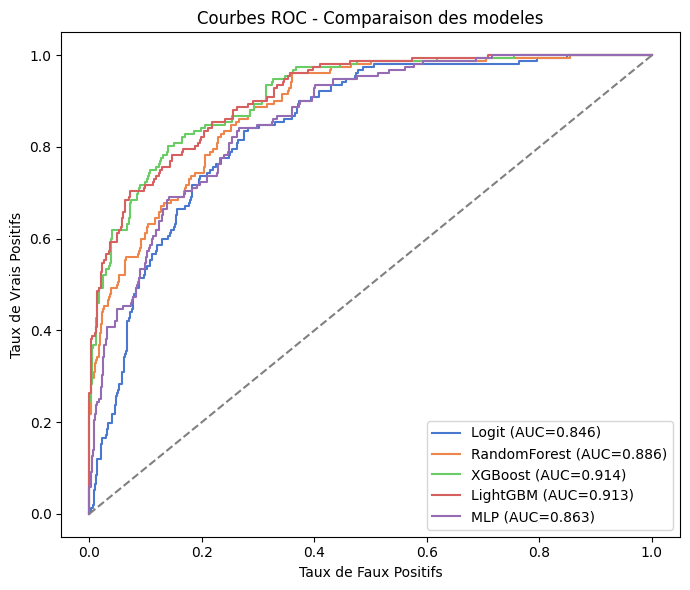

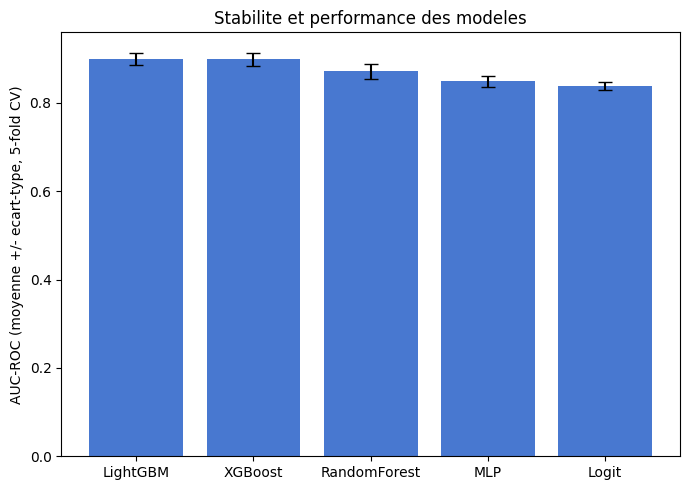


 Meilleur modele au sens AUC moyen (5-fold CV) : LightGBM


In [ ]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (
    roc_auc_score, log_loss, average_precision_score,
    brier_score_loss, roc_curve,
    precision_score, recall_score, accuracy_score, f1_score
)
import xgboost as xgb
import lightgbm as lgb

RANDOM_STATE = 42
N_SPLITS = 5


def build_preprocessor(num_cols, cat_cols, drop_first):
    """
    drop_first=True  -> pour les modeles lineaires (Logit, MLP) : evite la colinearite
    drop_first=False -> pour les modeles a arbres (RF, XGB, LGBM) : pas necessaire
    """
    return ColumnTransformer([
        ("num", StandardScaler(), num_cols),
        ("cat", OneHotEncoder(
            drop="first" if drop_first else None,
            sparse_output=False,
            min_frequency=0.01,
            handle_unknown="infrequent_if_exist" if drop_first else "ignore"
        ), cat_cols),
    ])


def clean_names(names):
    # XGBoost/LightGBM n'acceptent pas certains caracteres dans les noms de colonnes
    return [re.sub(r"[\[\]<>\s]", "_", n) for n in names]


MODELS = {
    "Logit": {
        "estimator": lambda **kw: LogisticRegression(
            max_iter=1000, class_weight="balanced", random_state=RANDOM_STATE
        ),
        "drop_first": True,
        "needs_named_df": False,
        "needs_spw": False,
    },
    "RandomForest": {
        "estimator": lambda **kw: RandomForestClassifier(
            n_estimators=500, max_depth=6, min_samples_leaf=20,
            class_weight="balanced",
            random_state=RANDOM_STATE, n_jobs=-1
        ),
        "drop_first": False,
        "needs_named_df": False,
        "needs_spw": False,
    },
    "XGBoost": {
        # scale_pos_weight recalcule a chaque fold -> passe en kwarg, valeur par defaut = neutre
        "estimator": lambda scale_pos_weight=1.0, **kw: xgb.XGBClassifier(
            n_estimators=400, max_depth=4, learning_rate=0.05,
            subsample=0.8, colsample_bytree=0.8,
            scale_pos_weight=scale_pos_weight,
            eval_metric="logloss", random_state=RANDOM_STATE
        ),
        "drop_first": False,
        "needs_named_df": True,
        "needs_spw": True,
    },
    "LightGBM": {
        "estimator": lambda **kw: lgb.LGBMClassifier(
            n_estimators=400, max_depth=4, learning_rate=0.05,
            subsample=0.8, colsample_bytree=0.8,
            is_unbalance=True,
            random_state=RANDOM_STATE, verbose=-1
        ),
        "drop_first": False,
        "needs_named_df": True,
        "needs_spw": False,
    },
    "MLP": {
        "estimator": lambda **kw: MLPClassifier(
            hidden_layer_sizes=(32, 16), activation="relu",
            alpha=1e-3, max_iter=500, random_state=RANDOM_STATE
        ),
        "drop_first": True,
        "needs_named_df": False,
        "needs_spw": False,
    },
}


def evaluate_models_cv(df, num_cols, cat_cols, target_col="Y",
                        models=MODELS, n_splits=N_SPLITS,
                        random_state=RANDOM_STATE, seuil=0.5):
    # seuil : seuil de decision applique aux probabilites pour calculer
    # precision / rappel / accuracy / F1 (0.5 par defaut ; a ajuster si Y
    # est desequilibre — cf. optimiser_seuil_capacite plus haut).

    X_raw = df[num_cols + cat_cols].copy()
    Y = df[target_col].copy()

    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=random_state)

    results = []
    roc_curves = {}

    for name, cfg in models.items():
        fold_rows = []

        for fold_i, (tr_idx, te_idx) in enumerate(skf.split(X_raw, Y)):
            X_train, X_test = X_raw.iloc[tr_idx], X_raw.iloc[te_idx]
            Y_train, Y_test = Y.iloc[tr_idx], Y.iloc[te_idx]

            preprocessor = build_preprocessor(num_cols, cat_cols, cfg["drop_first"])
            X_train_enc = preprocessor.fit_transform(X_train)
            X_test_enc = preprocessor.transform(X_test)

            if cfg["needs_named_df"]:
                feat_names = clean_names(
                    num_cols + list(
                        preprocessor.named_transformers_["cat"].get_feature_names_out(cat_cols)
                    )
                )
                X_train_enc = pd.DataFrame(X_train_enc, columns=feat_names)
                X_test_enc = pd.DataFrame(X_test_enc, columns=feat_names)

            # Pondération classe minoritaire, recalculée par fold (le ratio bouge un peu selon le split)
            if cfg.get("needs_spw"):
                spw = (Y_train == 0).sum() / (Y_train == 1).sum()
                model = cfg["estimator"](scale_pos_weight=spw)
            else:
                model = cfg["estimator"]()

            model.fit(X_train_enc, Y_train)
            pred = model.predict_proba(X_test_enc)[:, 1]
            pred_label = (pred >= seuil).astype(int)

            fold_rows.append({
                "AUC": roc_auc_score(Y_test, pred),
                "AP": average_precision_score(Y_test, pred),
                "LogLoss": log_loss(Y_test, pred),
                "Brier": brier_score_loss(Y_test, pred),
                "Accuracy": accuracy_score(Y_test, pred_label),
                "Precision": precision_score(Y_test, pred_label, zero_division=0),
                "Rappel": recall_score(Y_test, pred_label, zero_division=0),
                "F1": f1_score(Y_test, pred_label, zero_division=0),
            })

            if fold_i == 0:
                fpr, tpr, _ = roc_curve(Y_test, pred)
                roc_curves[name] = (fpr, tpr, roc_auc_score(Y_test, pred))

        fm = pd.DataFrame(fold_rows)
        results.append({
            "Modele": name,
            "AUC_moy": fm["AUC"].mean(),   "AUC_std": fm["AUC"].std(),
            "AP_moy": fm["AP"].mean(),     "AP_std": fm["AP"].std(),
            "LogLoss_moy": fm["LogLoss"].mean(),
            "Brier_moy": fm["Brier"].mean(),
            "Accuracy_moy": fm["Accuracy"].mean(),
            "Precision_moy": fm["Precision"].mean(),
            "Rappel_moy": fm["Rappel"].mean(),
            "F1_moy": fm["F1"].mean(),
        })

    results_df = pd.DataFrame(results).sort_values("AUC_moy", ascending=False).reset_index(drop=True)
    return results_df, roc_curves


results_df, roc_curves = evaluate_models_cv(all_drivers1, NUM_COLS, CAT_COLS)

print("=== Comparaison des modeles (moyenne sur 5 folds) ===")
print(results_df.to_string(index=False))

plt.figure(figsize=(7, 6))
for name, (fpr, tpr, auc) in roc_curves.items():
    plt.plot(fpr, tpr, label=f"{name} (AUC={auc:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray")
plt.xlabel("Taux de Faux Positifs")
plt.ylabel("Taux de Vrais Positifs")
plt.title("Courbes ROC - Comparaison des modeles")
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(7, 5))
plt.bar(results_df["Modele"], results_df["AUC_moy"], yerr=results_df["AUC_std"], capsize=5)
plt.ylabel("AUC-ROC (moyenne +/- ecart-type, 5-fold CV)")
plt.title("Stabilite et performance des modeles")
plt.tight_layout()
plt.show()

best_model_name = results_df.iloc[0]["Modele"]
print(f"\n Meilleur modele au sens AUC moyen (5-fold CV) : {best_model_name}")

In [ ]:
!jupyter nbconvert Traitement_complet_EN.ipynb --to html --no-input

[NbConvertApp] Converting notebook Traitement_complet_EN.ipynb to html
[NbConvertApp] WARNING | Alternative text is missing on 20 image(s).
[NbConvertApp] Writing 2149799 bytes to Traitement_complet_EN.html
